# 実験結果の可視化

`outputs/` ディレクトリ内に保存された実験結果（`log.json`）を再帰的に走査し，同一条件（実験・手法・
ハイパーパラメータ）における全Seedの結果から平均と標準偏差を計算してプロットする．

比較対象とする実験・手法・ハイパーパラメータは，「可視化する条件の指定」のセルの変数で指定する．
生成したグラフは `outputs/{experiment}/` 以下に保存する．

`OUTPUTS_ROOT` を `outputs_old` に変更すると，`.orders/order_020.md` 以前の事前実験
（`programs_old/`）の結果も同じ手順で可視化できる．

In [1]:
import json
import os
from pathlib import Path

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import re
import numpy as np

# 日本語ラベルを正しく描画するため，IPAexゴシックフォントが存在すれば明示的に登録する
_JP_FONT_PATH = "/usr/share/fonts/opentype/ipaexfont-gothic/ipaexg.ttf"
if os.path.exists(_JP_FONT_PATH):
    fm.fontManager.addfont(_JP_FONT_PATH)
    plt.rcParams["font.family"] = fm.FontProperties(fname=_JP_FONT_PATH).get_name()
plt.rcParams["axes.unicode_minus"] = False

# 可視化対象の出力ディレクトリ．事前実験を見る場合は "outputs_old" に変更する．
OUTPUTS_ROOT = Path("outputs")

## 結果の読み込み

`outputs/{experiment}/{method}/{hyperparams}/{seed}/log.json` を再帰的に走査し，
`(experiment, method, hyperparams)` ごとに全Seedのログと設定を集約する．

In [2]:
def load_all_results(outputs_root: Path) -> dict:
    """
    概要: `outputs/` 以下の全 `log.json` を再帰的に読み込み，(experiment, method, hyperparams)
        をキーとして，Seedごとのログのリストにまとめる．
    引数: outputs_root (Path)．走査対象のルートディレクトリ．
    戻り値: results (dict)．
        key: (experiment, method, hyperparams) のタプル（いずれも str）．
        value: {"seed_logs": [dict, ...], "configs": [dict, ...], "seeds": [int, ...]}
    """
    results = {}
    for log_path in sorted(outputs_root.glob("*/*/*/*/log.json")):
        seed_dir = log_path.parent
        hp_dir = seed_dir.parent
        method_dir = hp_dir.parent
        experiment_dir = method_dir.parent

        key = (experiment_dir.name, method_dir.name, hp_dir.name)
        with open(log_path) as f:
            log = json.load(f)

        config_path = seed_dir / "config.json"
        config = {}
        if config_path.exists():
            with open(config_path) as f:
                config = json.load(f)

        entry = results.setdefault(key, {"seed_logs": [], "configs": [], "seeds": []})
        entry["seed_logs"].append(log)
        entry["configs"].append(config)
        entry["seeds"].append(seed_dir.name)
    return results


all_results = load_all_results(OUTPUTS_ROOT)
for (experiment, method, hyperparams), entry in all_results.items():
    print(f"{experiment} / {method} / {hyperparams}: {len(entry['seed_logs'])} seeds")

ex000_a9a_least_squares / ASAI_SVRG / eta1.545485e-01_K29304_epochs100: 5 seeds
ex000_a9a_least_squares / ASAI_SVRG / eta2.318228e-02_K29304_epochs100: 5 seeds
ex000_a9a_least_squares / ASAI_SVRG / eta7.910960e-07_K29304_epochs100: 5 seeds
ex000_a9a_least_squares / NFG_SVRG / eta1.545485e-01_K29304_epochs100: 5 seeds
ex000_a9a_least_squares / NFG_SVRG / eta2.318228e-02_K29304_epochs100: 5 seeds
ex000_a9a_least_squares / NFG_SVRG / eta7.910960e-07_K29304_epochs100: 5 seeds
ex000_a9a_least_squares / SGD / eta1.545485e-01_K29304_epochs100: 5 seeds
ex000_a9a_least_squares / SGD / eta2.318228e-02_K29304_epochs100: 5 seeds
ex000_a9a_least_squares / SGD / eta7.910960e-07_K29304_epochs100: 5 seeds
ex000_a9a_least_squares / SVRG / eta1.545485e-01_K29304_epochs100: 5 seeds
ex000_a9a_least_squares / SVRG / eta2.318228e-02_K29304_epochs100: 5 seeds
ex000_a9a_least_squares / SVRG / eta7.910960e-07_K29304_epochs100: 5 seeds
ex001_mushroom_logistic / ASAI_SVRG / eta1.049767e-02_lambda9.155984e-01_K73

## 平均・標準偏差の計算

同一条件の全Seedのログについて，指定した横軸・縦軸それぞれの平均値と標準偏差を計算する．
横軸（`full_grad_computations`，`epoch`，`elapsed_time`）はSeedによって僅かに異なる場合がある
ため（実行時間など），横軸についても全Seedの平均値を用いる．

In [3]:
def aggregate_seeds(seed_logs: list, x_key: str, y_key: str):
    """
    概要: 複数Seedのログから，指定した横軸・縦軸について平均値と標準偏差を計算する．
    引数:
        seed_logs (list of dict)．各Seedの `ResultLogger.history` に対応する辞書のリスト．
        x_key (str)．横軸として用いる指標名（例: "full_grad_computations", "epoch",
            "elapsed_time"）．
        y_key (str)．縦軸として用いる指標名（例: "objective_value", "grad_norm_sq",
            "accuracy", "approx_error"）．
    戻り値:
        x (numpy.ndarray)，形状 (T,)．横軸の値（全Seedの平均）．
        mean (numpy.ndarray)，形状 (T,)．縦軸の平均値．
        std (numpy.ndarray)，形状 (T,)．縦軸の標準偏差．
    """
    length = min(len(log[x_key]) for log in seed_logs)
    x_values = np.array([log[x_key][:length] for log in seed_logs], dtype=np.float64)
    y_values = np.array([log[y_key][:length] for log in seed_logs], dtype=np.float64)

    return x_values.mean(axis=0), np.nanmean(y_values, axis=0), np.nanstd(y_values, axis=0)


def get_config_value(all_results: dict, experiment: str, key: str, default=None):
    """
    概要: 指定した実験の `config.json` から，最初に見つかった値を取得する．
    引数:
        all_results (dict)．`load_all_results` の戻り値．
        experiment (str)．対象実験名．
        key (str)．取得する設定項目名（例: "eta_rule", "N_train"）．
        default．値が見つからない場合に返す既定値．
    戻り値: value．設定項目の値．
    """
    for (exp, _, _), entry in all_results.items():
        if exp != experiment:
            continue
        for config in entry["configs"]:
            if key in config:
                return config[key]
    return default


def get_hyperparams_to_label(all_results: dict, experiment: str) -> dict:
    """
    概要: 実験内の各ハイパーパラメータ条件（ディレクトリ名）に対し，`config.json` に記録された
        学習率の決定規則（`eta_rule`）を凡例用のラベルとして対応付ける．
    引数:
        all_results (dict)．`load_all_results` の戻り値．
        experiment (str)．対象実験名．
    戻り値: hyperparams_to_label (dict)．{ハイパーパラメータ条件名: ラベル文字列}．
    """
    hyperparams_to_label = {}
    for (exp, _, hyperparams), entry in all_results.items():
        if exp != experiment or hyperparams in hyperparams_to_label:
            continue
        config = entry["configs"][0] if entry["configs"] else {}
        eta_rule = config.get("eta_rule")
        eta = config.get("eta")
        if eta_rule is not None and eta is not None:
            hyperparams_to_label[hyperparams] = f"$\\eta$ = {eta_rule} = {eta:.3g}"
        else:
            hyperparams_to_label[hyperparams] = hyperparams
    return hyperparams_to_label


def plot_curves(ax, all_results, experiment, hyperparams, methods, method_colors,
                x_key, y_key, log_y=True, x_limit=None):
    """
    概要: 指定した条件の曲線（全Seedの平均と標準偏差）を1つの座標軸に描画する．
    引数:
        ax (matplotlib.axes.Axes)．描画先の座標軸．
        all_results (dict)．`load_all_results` の戻り値．
        experiment (str)．対象実験名．
        hyperparams (str)．ハイパーパラメータ条件名．
        methods (list of str)．描画する手法名のリスト．
        method_colors (dict)．{手法名: 色}．
        x_key (str)．横軸の指標名．
        y_key (str)．縦軸の指標名．
        log_y (bool) = True．縦軸を対数軸にするか．
        x_limit (float) = None．横軸の上限．指定した場合はその範囲のみ描画する．
    戻り値: なし
    """
    for method in methods:
        entry = all_results.get((experiment, method, hyperparams))
        if entry is None:
            continue
        x, mean, std = aggregate_seeds(entry["seed_logs"], x_key, y_key)
        if np.all(np.isnan(mean)):
            continue
        if x_limit is not None:
            mask = x <= x_limit
            x, mean, std = x[mask], mean[mask], std[mask]

        color = method_colors.get(method, None)
        ax.plot(x, mean, label=method, color=color, linewidth=1.5)
        ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.2, linewidth=0)

    if log_y:
        ax.set_yscale("log")
    ax.grid(alpha=0.3)

## 可視化する条件の指定

比較したい実験・手法・ハイパーパラメータを，下記の変数で指定する．
`EXPERIMENT` は対象実験名，`METHODS` は比較する手法，`HYPERPARAMS_LIST` は比較する
ハイパーパラメータ条件（`None` の場合は当該実験に存在する全条件を学習率の降順で用いる），
`METHOD_COLORS` は手法ごとの色である．

In [4]:
EXPERIMENT = "ex001_mushroom_logistic"
METHODS = ["SGD", "SVRG", "NFG_SVRG", "ASAI_SVRG"]
METHOD_COLORS = {
    "SGD": "#2ca02c",
    "SVRG": "#1f77b4",
    "NFG_SVRG": "#ff7f0e",
    "ASAI_SVRG": "#d62728",
}

# 目的関数を表す指標名．非凸で最適値が未知の実験0は目的関数の値そのもの（objective_value），
# 強凸で最適値 f(w*) が既知の実験1以降は差分 f(z_s)-f(w*)（objective_gap）を用いる．
OBJECTIVE_KEY_BY_EXPERIMENT = {
    "ex000_a9a_least_squares": ("objective_value", r"目的関数の値 $f(z_s)$"),
    "ex001_mushroom_logistic": ("objective_gap", r"目的関数の差分 $f(z_s)-f(w^*)$"),
}
OBJECTIVE_KEY, OBJECTIVE_LABEL = OBJECTIVE_KEY_BY_EXPERIMENT.get(
    EXPERIMENT, ("objective_value", r"目的関数の値 $f(z_s)$")
)

HYPERPARAMS_TO_LABEL = get_hyperparams_to_label(all_results, EXPERIMENT)
# 学習率の大きい順（ディレクトリ名の eta の値の降順）に並べる
def _extract_eta(hp_name: str) -> float:
    """概要: ハイパーパラメータ条件名（ディレクトリ名）から学習率 eta の値を抽出する．
        "eta{value}_..."（実験0・1）／"lr{value}_bs..."（実験2）のいずれの命名規則にも
        対応するため，固定オフセットではなく正規表現で最初の数値を抽出する．
    引数: hp_name (str)．ハイパーパラメータ条件名．
    戻り値: eta (float)．
    """
    match = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", hp_name)
    return float(match.group()) if match else 0.0


HYPERPARAMS_LIST = sorted(HYPERPARAMS_TO_LABEL, key=_extract_eta, reverse=True)

FIGURE_DIR = OUTPUTS_ROOT / EXPERIMENT
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

N_TRAIN = get_config_value(all_results, EXPERIMENT, "N_train")
print(f"N_train = {N_TRAIN}")
for hyperparams in HYPERPARAMS_LIST:
    print(f"  {hyperparams}  ->  {HYPERPARAMS_TO_LABEL[hyperparams]}")


N_train = 7311
  eta1.049767e-02_lambda9.155984e-01_K7311_epochs100  ->  $\eta$ = eta_a_near_upper_bound = 0.0105
  eta1.590556e-03_lambda9.155984e-01_K7311_epochs100  ->  $\eta$ = eta_c=1/(20L) = 0.00159
  eta1.105364e-03_lambda9.155984e-01_K7311_epochs100  ->  $\eta$ = eta_b_rho=0.5 = 0.00111


## NFG SVRG原論文 Figure 3 の再現

NFG SVRG原論文（`references/No_Full_Grad_SVRG.pdf`）のFigure 3は，横軸を「フル勾配の計算回数
（# full gradient computations）」，縦軸を真のフル勾配のノルムの2乗 $ \|\nabla f(x^k)\|^2 $
（対数軸）として，SVRGとNFG SVRGの収束を比較したものである．同図の横軸の範囲は0〜100である
ため，本図でも同じ範囲を描画する．

横軸の「フル勾配の計算回数」は，オラクル呼び出し（単一サンプルの勾配計算）の総回数を学習用
データ数 $ N_{\text{train}} $ で割った値であり，1エポックあたりSGDは1回，NFG SVRGは2回，
SVRGは3回（内部ループの2回とスナップショットにおけるフル勾配の1回）に相当する．

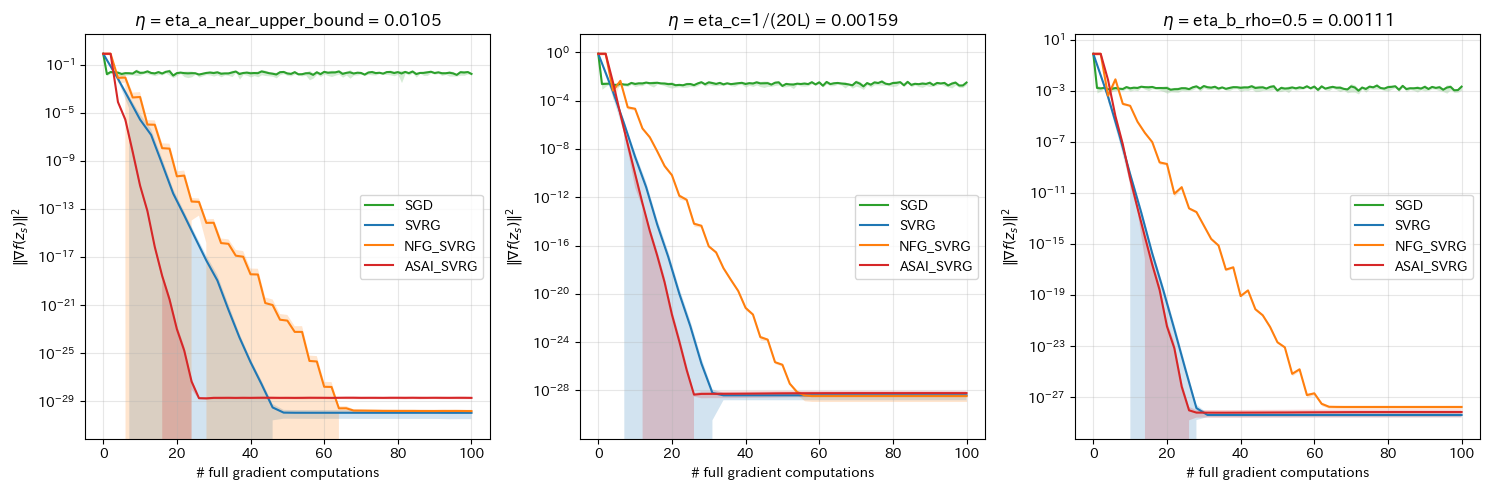

In [5]:
fig, axes = plt.subplots(1, len(HYPERPARAMS_LIST), figsize=(5 * len(HYPERPARAMS_LIST), 5))
axes = np.atleast_1d(axes)

for ax, hyperparams in zip(axes, HYPERPARAMS_LIST):
    plot_curves(ax, all_results, EXPERIMENT, hyperparams, METHODS, METHOD_COLORS,
                x_key="full_grad_computations", y_key="grad_norm_sq", x_limit=100)
    ax.set_xlabel("# full gradient computations")
    ax.set_ylabel(r"$\|\nabla f(z_s)\|^2$")
    ax.set_title(HYPERPARAMS_TO_LABEL[hyperparams])
    ax.legend()

fig.tight_layout()
fig.savefig(FIGURE_DIR / "grad_norm_sq_vs_full_grad_computations.png", dpi=150, bbox_inches="tight")
plt.show()

## 3つの横軸 × 3つの評価指標の比較

`.orders/order_020.md` の「共通の評価指標」に従い，横軸を勾配計算回数・エポック数・実行時間の
3通り，縦軸を目的関数の値・フル勾配のノルムの2乗・フル勾配の近似誤差の3通りとした比較を行う．
実行時間には，評価指標の算出のためだけに計算するフル勾配のコストは含まれていない．

/tmp/ipykernel_2214256/1372621914.py:19: RuntimeWarning: Mean of empty slice
  return x_values.mean(axis=0), np.nanmean(y_values, axis=0), np.nanstd(y_values, axis=0)
/home/user/workspace/ASAI_SVRG_programs/.venv_pytorch_gpu/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


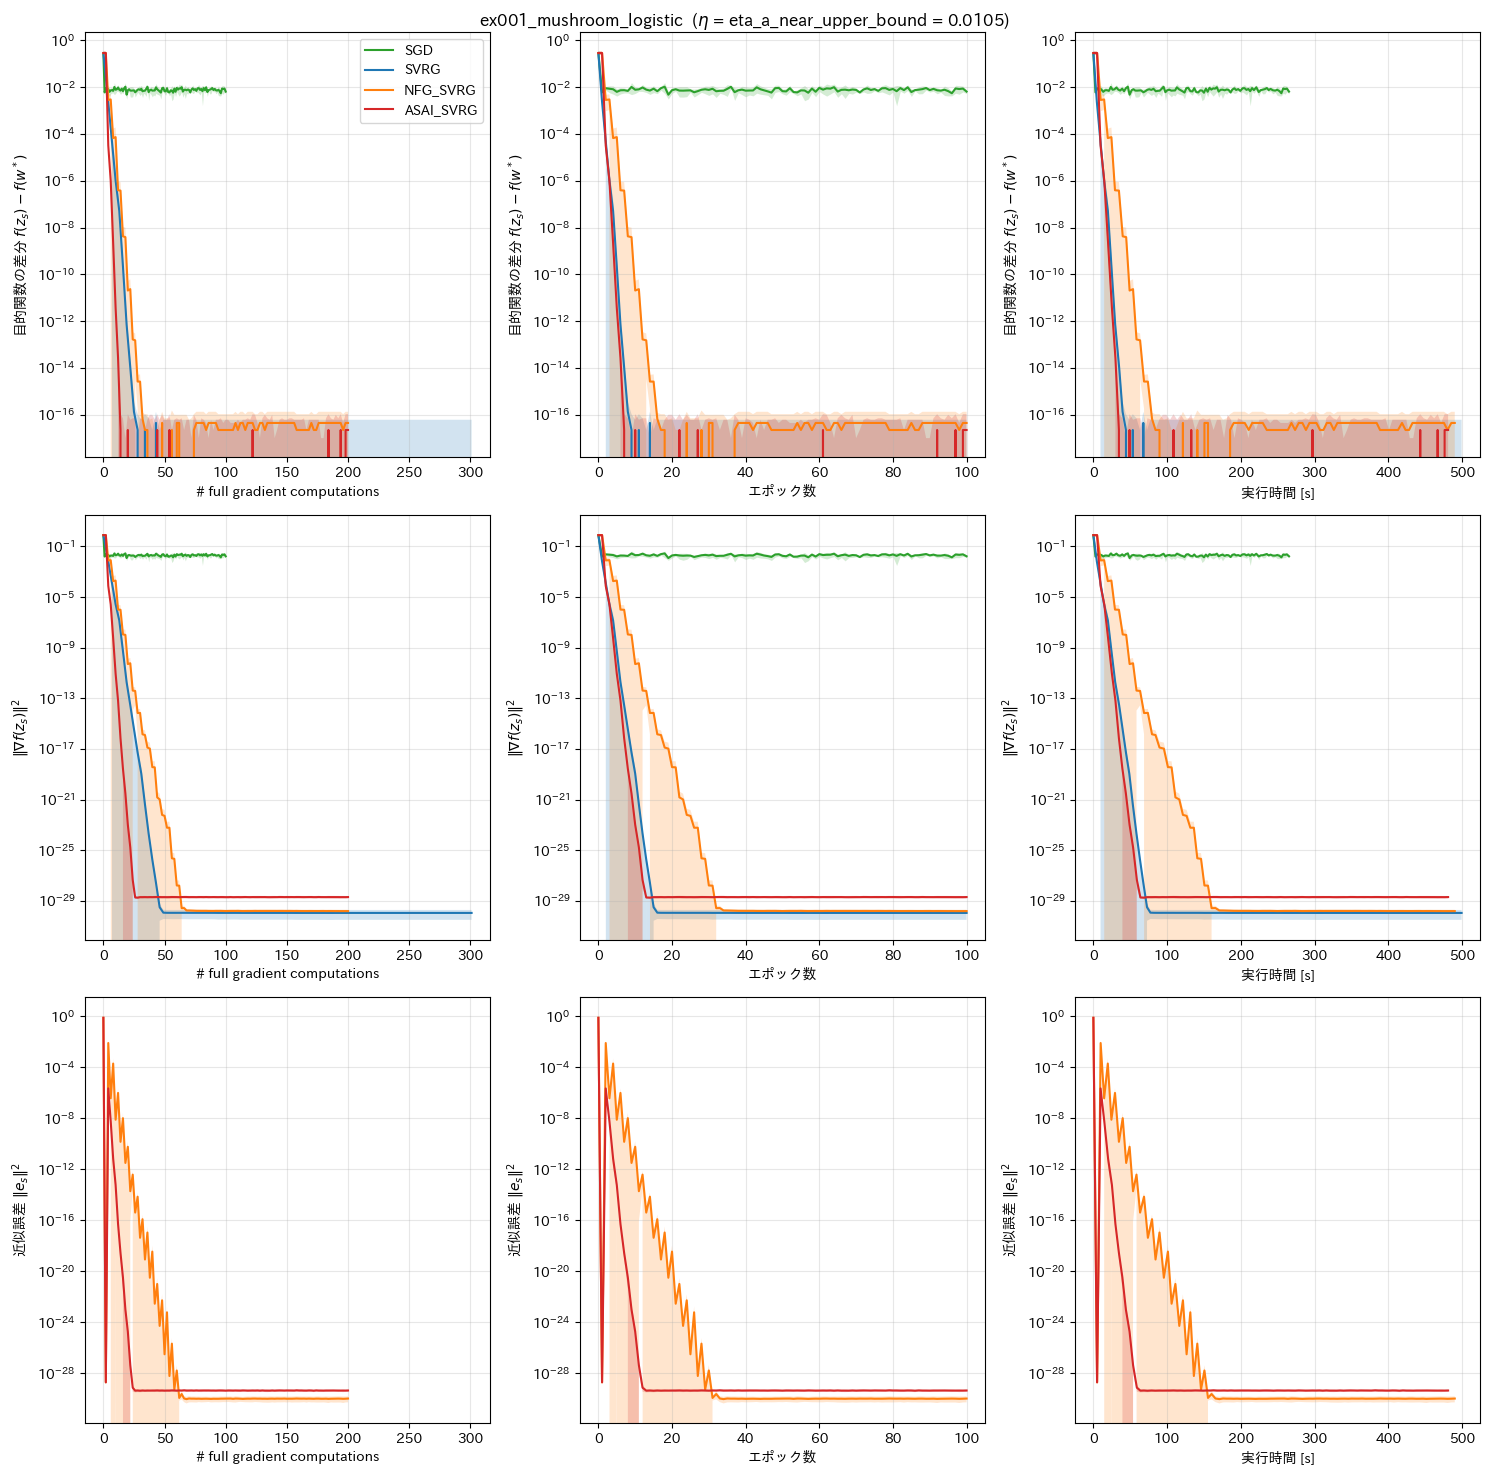

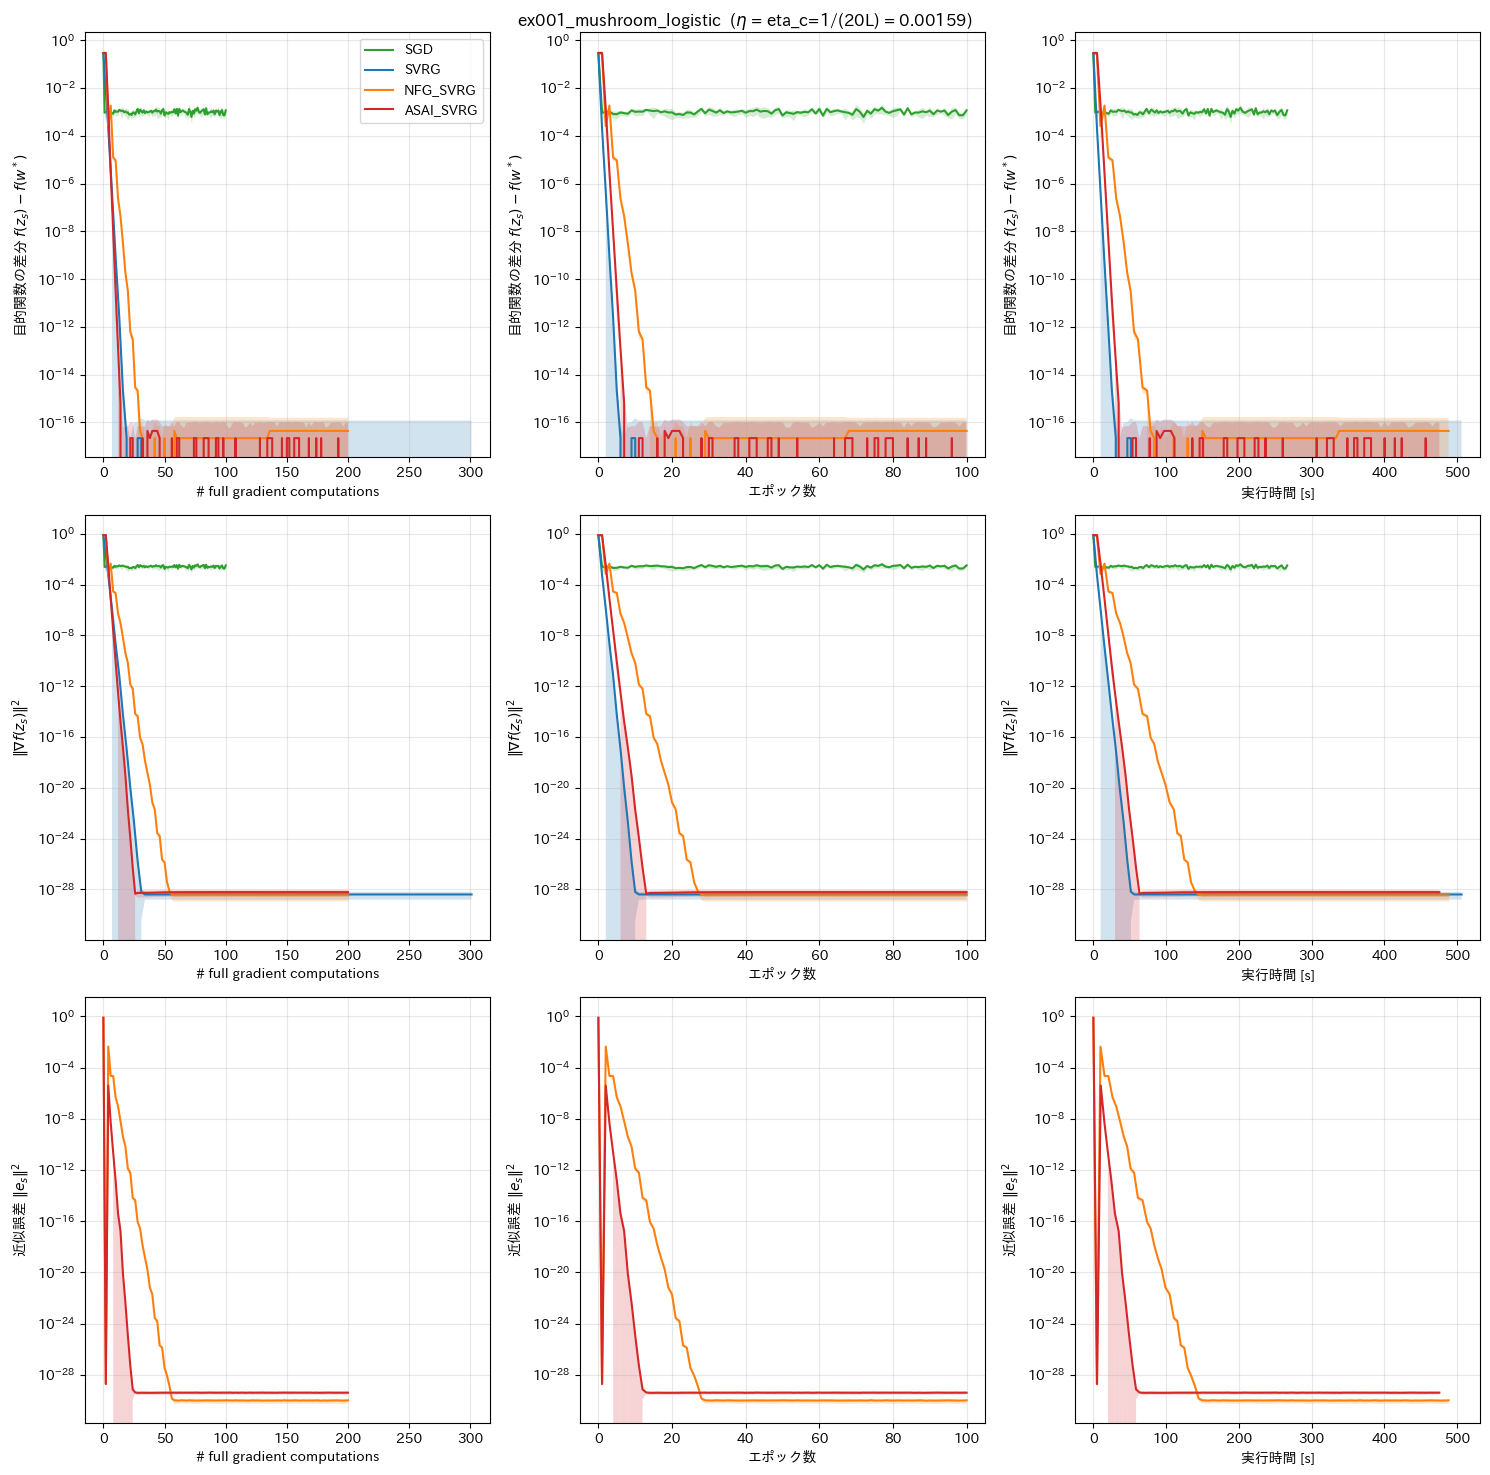

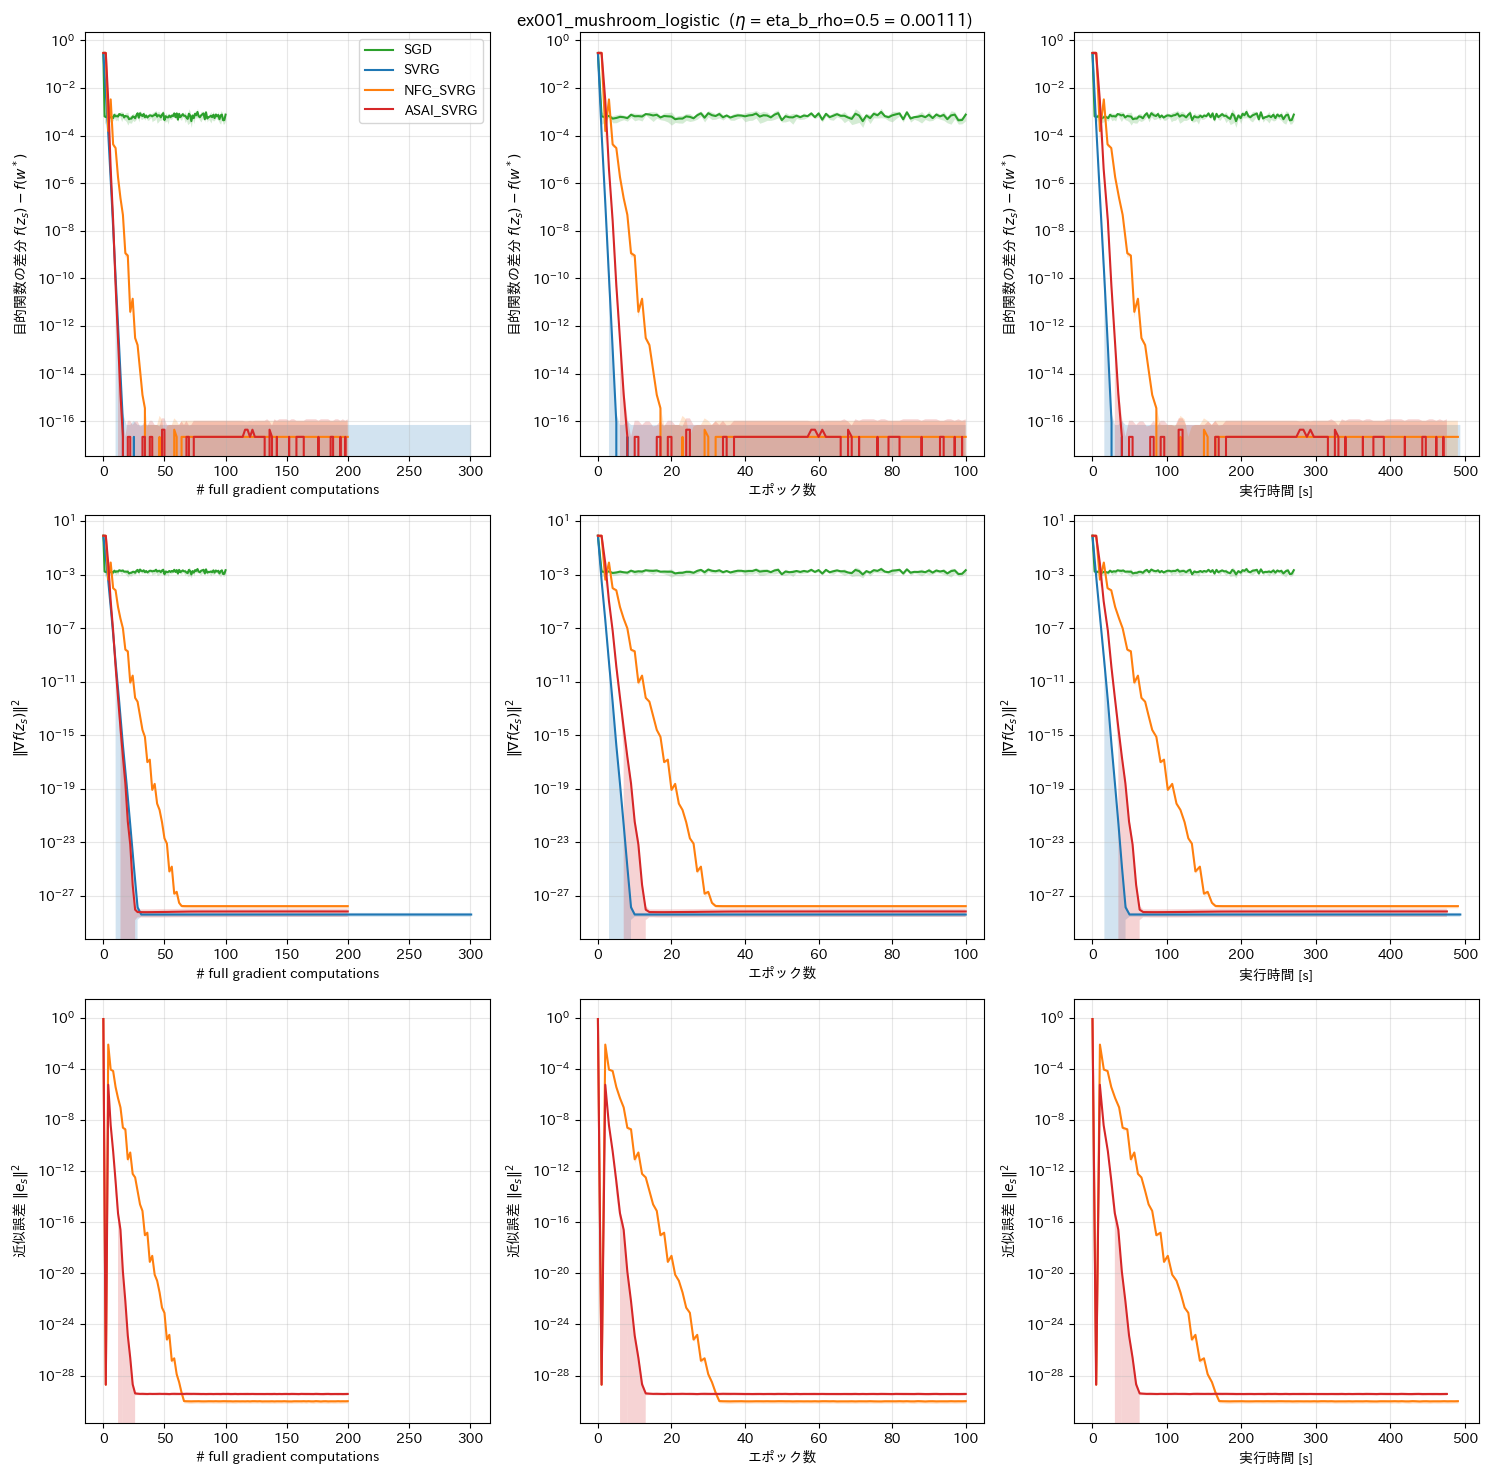

In [6]:
X_AXES = [
    ("full_grad_computations", "# full gradient computations"),
    ("epoch", "エポック数"),
    ("elapsed_time", "実行時間 [s]"),
]
Y_AXES = [
    (OBJECTIVE_KEY, OBJECTIVE_LABEL),
    ("grad_norm_sq", r"$\|\nabla f(z_s)\|^2$"),
    ("approx_error", r"近似誤差 $\|e_s\|^2$"),
]

for hyperparams in HYPERPARAMS_LIST:
    fig, axes = plt.subplots(len(Y_AXES), len(X_AXES), figsize=(15, 15))
    for row, (y_key, y_label) in enumerate(Y_AXES):
        for col, (x_key, x_label) in enumerate(X_AXES):
            ax = axes[row][col]
            plot_curves(ax, all_results, EXPERIMENT, hyperparams, METHODS, METHOD_COLORS,
                        x_key=x_key, y_key=y_key)
            ax.set_xlabel(x_label)
            ax.set_ylabel(y_label)
            if row == 0 and col == 0:
                ax.legend()

    fig.suptitle(f"{EXPERIMENT}  ({HYPERPARAMS_TO_LABEL[hyperparams]})")
    fig.tight_layout()
    eta_tag = hyperparams.split("_")[0]
    fig.savefig(FIGURE_DIR / f"comparison_all_axes_{eta_tag}.png", dpi=150, bbox_inches="tight")
    plt.show()


## 分類精度の推移

原論文の式(8)は分類精度を評価指標としないが，`.orders/order_020.md` の共通の評価指標に従い，
検証用データに対する分類精度を補助指標として記録している．

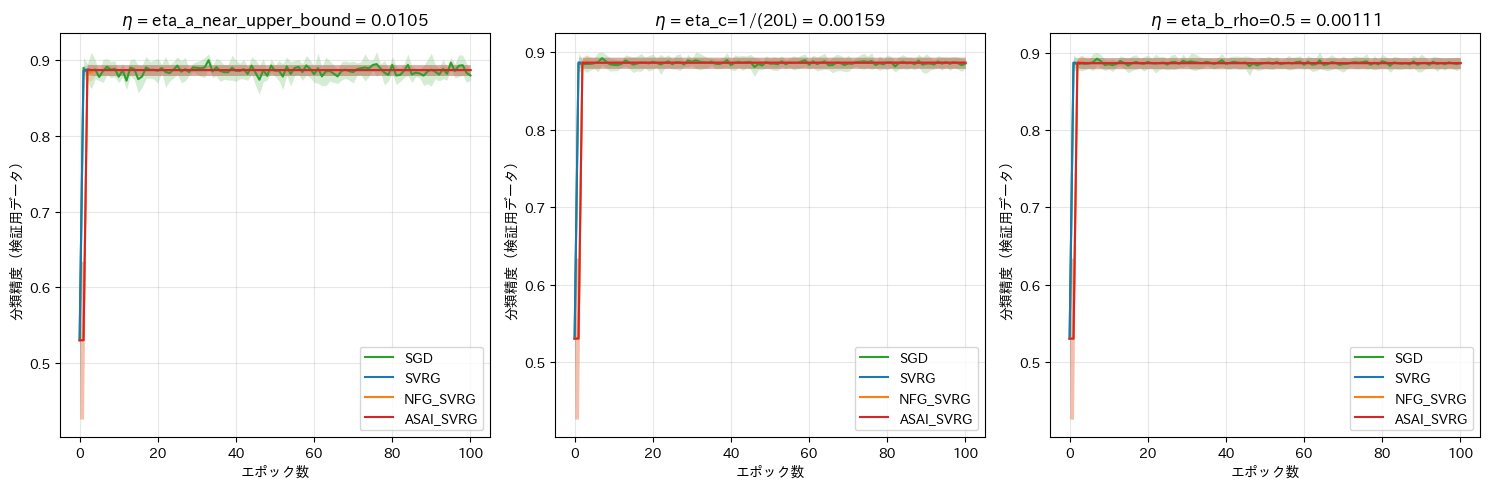

In [7]:
fig, axes = plt.subplots(1, len(HYPERPARAMS_LIST), figsize=(5 * len(HYPERPARAMS_LIST), 5))
axes = np.atleast_1d(axes)

for ax, hyperparams in zip(axes, HYPERPARAMS_LIST):
    plot_curves(ax, all_results, EXPERIMENT, hyperparams, METHODS, METHOD_COLORS,
                x_key="epoch", y_key="accuracy", log_y=False)
    ax.set_xlabel("エポック数")
    ax.set_ylabel("分類精度（検証用データ）")
    ax.set_title(HYPERPARAMS_TO_LABEL[hyperparams])
    ax.legend()

fig.tight_layout()
fig.savefig(FIGURE_DIR / "accuracy_vs_epoch.png", dpi=150, bbox_inches="tight")
plt.show()

## 最終エポックにおける評価指標の一覧

各条件の最終エポックにおける評価指標について，全Seedの平均と標準偏差を表形式で出力する．

In [8]:
def summarize_final_epoch(all_results, experiment, hyperparams_list, methods,
                          hyperparams_to_label, objective_key="objective_value") -> str:
    """
    概要: 各条件の最終エポックにおける評価指標（全Seedの平均 ± 標準偏差）をMarkdownの表として
        文字列にまとめる．
    引数:
        all_results (dict)．`load_all_results` の戻り値．
        experiment (str)．対象実験名．
        hyperparams_list (list of str)．対象とするハイパーパラメータ条件名のリスト．
        methods (list of str)．対象とする手法名のリスト．
        hyperparams_to_label (dict)．{ハイパーパラメータ条件名: ラベル文字列}．
        objective_key (str) = "objective_value"．目的関数を表す指標名．非凸実験では
            "objective_value"，強凸実験では差分 "objective_gap" を用いる．
    戻り値: table (str)．Markdown形式の表．
    """
    objective_header = "f(z_s)-f(w*)" if objective_key == "objective_gap" else "f(z_s)"
    lines = [
        f"| 学習率 | 手法 | {objective_header} | 精度 | ||\u2207f(z_s)||^2 | ||e_s||^2 | #grad/N | 実行時間[s] |",
        "| :--- | :--- | ---: | ---: | ---: | ---: | ---: | ---: |",
    ]
    for hyperparams in hyperparams_list:
        for method in methods:
            entry = all_results.get((experiment, method, hyperparams))
            if entry is None:
                continue
            cells = []
            for key in [objective_key, "accuracy", "grad_norm_sq", "approx_error",
                        "full_grad_computations", "elapsed_time"]:
                _, mean, std = aggregate_seeds(entry["seed_logs"], "epoch", key)
                if np.isnan(mean[-1]):
                    cells.append("なし")
                elif key == "accuracy":
                    cells.append(f"{mean[-1]:.4f} \u00b1 {std[-1]:.4f}")
                elif key in ("full_grad_computations", "elapsed_time"):
                    cells.append(f"{mean[-1]:.1f}")
                else:
                    cells.append(f"{mean[-1]:.4e} \u00b1 {std[-1]:.2e}")
            label = hyperparams_to_label[hyperparams]
            lines.append(f"| {label} | {method} | " + " | ".join(cells) + " |")
    return "\n".join(lines)


summary_table = summarize_final_epoch(
    all_results, EXPERIMENT, HYPERPARAMS_LIST, METHODS, HYPERPARAMS_TO_LABEL,
    objective_key=OBJECTIVE_KEY,
)
print(summary_table)
with open(FIGURE_DIR / "final_epoch_summary.md", "w") as f:
    f.write(summary_table + "\n")


| 学習率 | 手法 | f(z_s)-f(w*) | 精度 | ||∇f(z_s)||^2 | ||e_s||^2 | #grad/N | 実行時間[s] |
| :--- | :--- | ---: | ---: | ---: | ---: | ---: | ---: |
| $\eta$ = eta_a_near_upper_bound = 0.0105 | SGD | 6.5333e-03 ± 1.14e-03 | 0.8795 ± 0.0060 | 1.6562e-02 ± 2.89e-03 | なし | 100.0 | 265.4 |
| $\eta$ = eta_a_near_upper_bound = 0.0105 | SVRG | -2.2204e-17 ± 8.31e-17 | 0.8866 ± 0.0072 | 1.1241e-30 ± 8.05e-31 | 0.0000e+00 ± 0.00e+00 | 301.0 | 499.5 |
| $\eta$ = eta_a_near_upper_bound = 0.0105 | NFG_SVRG | 4.4409e-17 ± 8.88e-17 | 0.8866 ± 0.0072 | 1.5694e-30 ± 4.21e-31 | 1.0286e-30 ± 5.11e-31 | 200.0 | 490.2 |
| $\eta$ = eta_a_near_upper_bound = 0.0105 | ASAI_SVRG | 2.2204e-17 ± 8.31e-17 | 0.8866 ± 0.0072 | 2.0095e-29 ± 4.40e-30 | 4.3951e-30 ± 9.49e-31 | 200.0 | 481.2 |
| $\eta$ = eta_c=1/(20L) = 0.00159 | SGD | 1.1664e-03 ± 3.61e-04 | 0.8856 ± 0.0059 | 3.2330e-03 ± 1.04e-03 | なし | 100.0 | 266.5 |
| $\eta$ = eta_c=1/(20L) = 0.00159 | SVRG | 0.0000e+00 ± 1.22e-16 | 0.8866 ± 0.0072 | 3.9435e-29 ± 2.41e-29 |

/tmp/ipykernel_2214256/1372621914.py:19: RuntimeWarning: Mean of empty slice
  return x_values.mean(axis=0), np.nanmean(y_values, axis=0), np.nanstd(y_values, axis=0)


## 実験2（CIFAR-10・AlexNet）専用の可視化：バッチサイズ×学習率のグリッド

実験2はバッチサイズ（8, 32, 128）と学習率（0.01, 0.001, 0.0001）の2軸グリッドであり，上記の
単一軸（学習率のみ）を前提としたセルでは適切に可視化できない．そのため，以下のセルで専用の
グリッド表示（縦：バッチサイズ，横：学習率）を行う．また，一部の条件ではNFG SVRG・
ASAI SVRGが学習の途中で発散（NaN）するため，発散したSeedはその時点以降 `nanmean` から
自動的に除外される（全Seedが発散した時点で曲線が途切れる）．

In [9]:
EX002_EXPERIMENT = "ex002_cifar10_alexnet"
EX002_METHODS = ["SGD", "SVRG", "NFG_SVRG", "ASAI_SVRG"]
EX002_BATCH_SIZES = [8, 32, 128]
EX002_LRS = [0.01, 0.001, 0.0001]
EX002_REG_LAMBDA = 0.0005
EX002_EPOCHS = 12

EX002_FIGURE_DIR = OUTPUTS_ROOT / EX002_EXPERIMENT
EX002_FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def ex002_hp_name(lr: float, bs: int) -> str:
    """概要: 実験2のハイパーパラメータ条件名（ディレクトリ名）を構築する．"""
    return f"lr{lr}_bs{bs}_lambda{EX002_REG_LAMBDA}_epochs{EX002_EPOCHS}"


def ex002_load_all(method: str, bs: int, lr: float, key: str):
    """
    概要: 実験2の指定条件について，全Seedの指標を読み込み平均・標準偏差を計算する．
        発散（NaN）したSeedはそのエポック以降 `nanmean`／`nanstd` から自動的に除外される．
    引数:
        method (str)．手法名．
        bs (int)．バッチサイズ．
        lr (float)．学習率．
        key (str)．指標名（例: "test_accuracy", "approx_error"）．
    戻り値:
        mean (numpy.ndarray)．エポックごとの平均値．
        std (numpy.ndarray)．エポックごとの標準偏差．
        n (int)．読み込んだSeed数．
    """
    entry = all_results.get((EX002_EXPERIMENT, method, ex002_hp_name(lr, bs)))
    if entry is None:
        return np.array([]), np.array([]), 0
    values = np.array([log[key] for log in entry["seed_logs"]], dtype=np.float64)
    return np.nanmean(values, axis=0), np.nanstd(values, axis=0), values.shape[0]

### 分類精度のグリッド（縦：バッチサイズ，横：学習率）

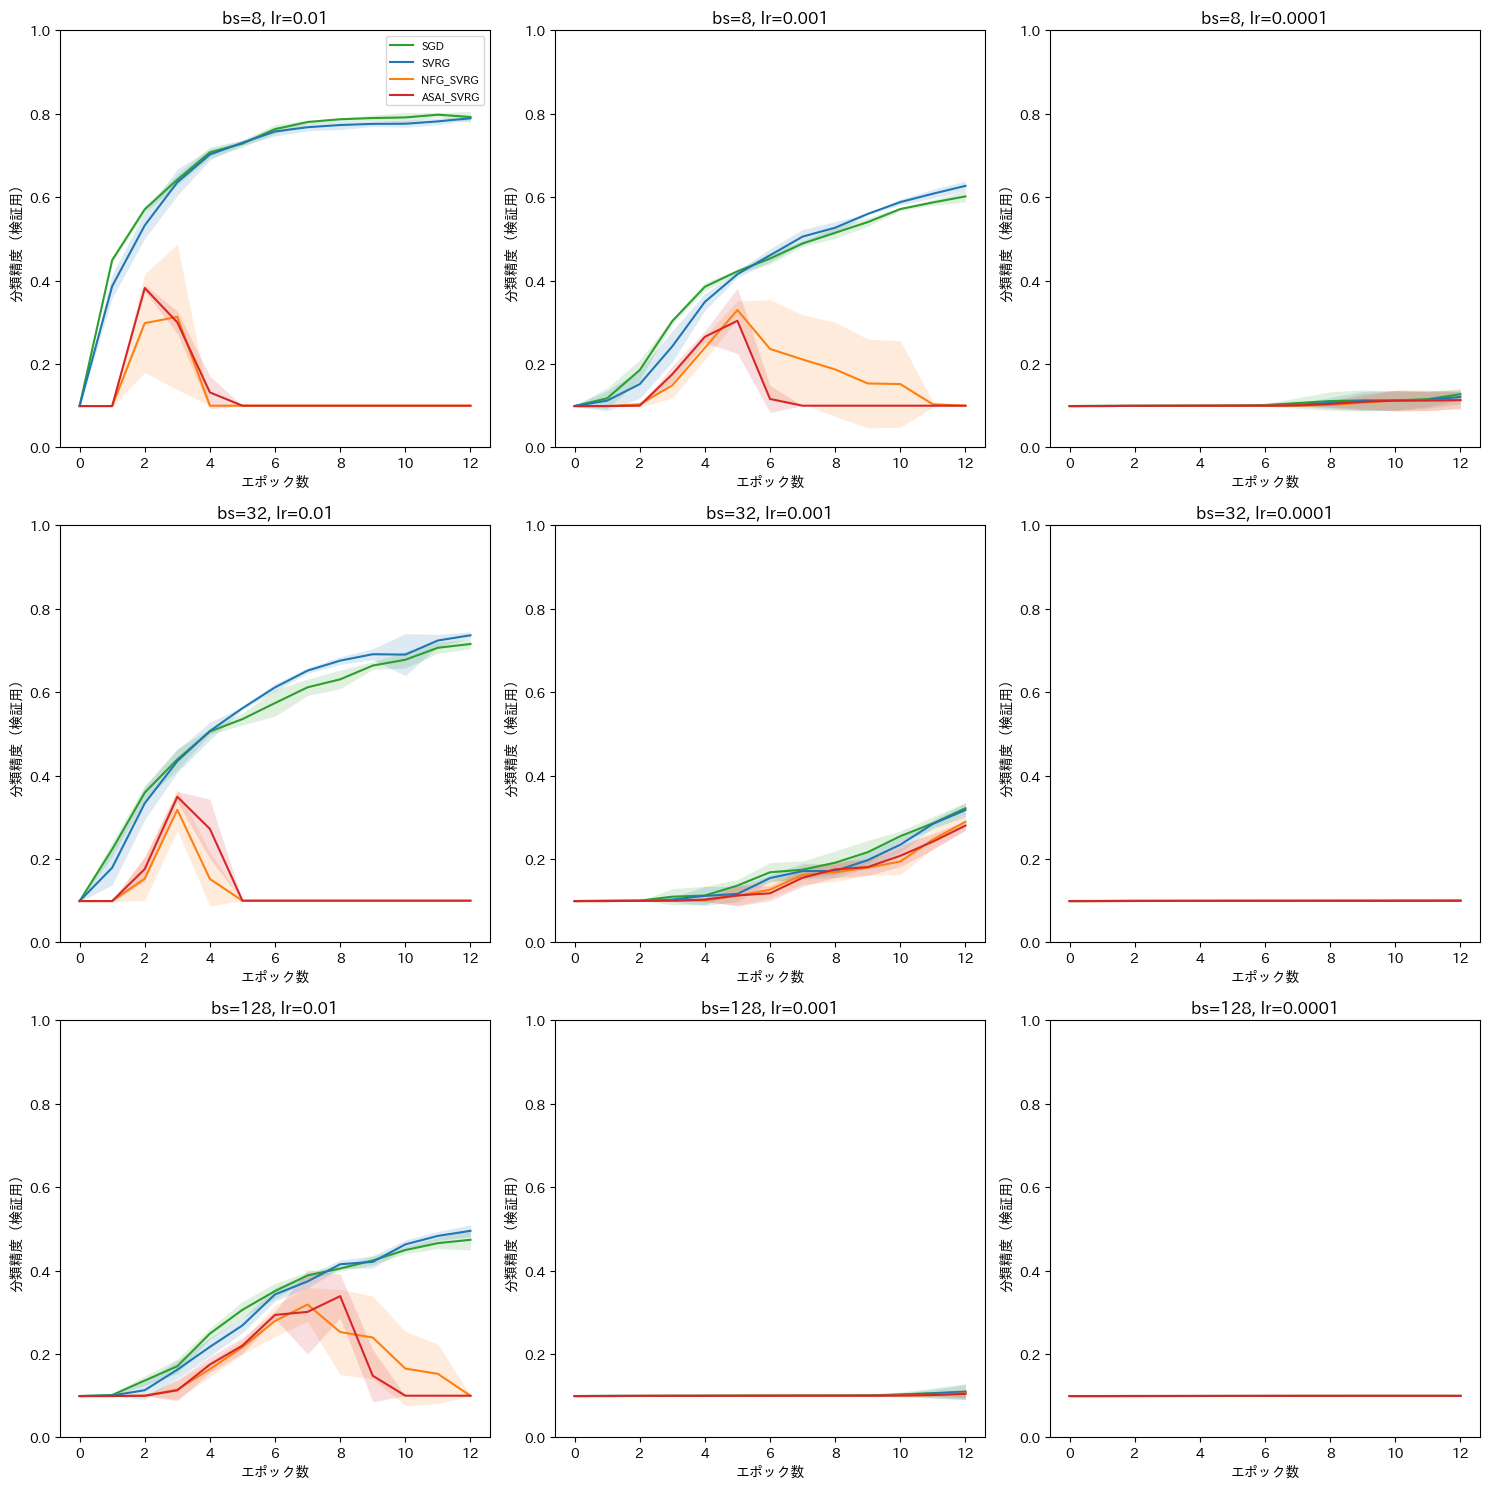

In [10]:
fig, axes = plt.subplots(len(EX002_BATCH_SIZES), len(EX002_LRS), figsize=(15, 15))
for i, bs in enumerate(EX002_BATCH_SIZES):
    for j, lr in enumerate(EX002_LRS):
        ax = axes[i][j]
        for method in EX002_METHODS:
            mean, std, n = ex002_load_all(method, bs, lr, "test_accuracy")
            if n == 0:
                continue
            x = np.arange(len(mean))
            ax.plot(x, mean, label=method, color=METHOD_COLORS.get(method), linewidth=1.5)
            ax.fill_between(x, mean - std, mean + std, color=METHOD_COLORS.get(method), alpha=0.15, linewidth=0)
        ax.set_title(f"bs={bs}, lr={lr}")
        ax.set_xlabel("エポック数")
        ax.set_ylabel("分類精度（検証用）")
        ax.set_ylim(0, 1)
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(EX002_FIGURE_DIR / "accuracy_grid.png", dpi=130, bbox_inches="tight")
plt.show()

### フル勾配の近似誤差のグリッド（NFG SVRG・ASAI SVRGのみ）

/tmp/ipykernel_2214256/3491330363.py:35: RuntimeWarning: Mean of empty slice
  return np.nanmean(values, axis=0), np.nanstd(values, axis=0), values.shape[0]


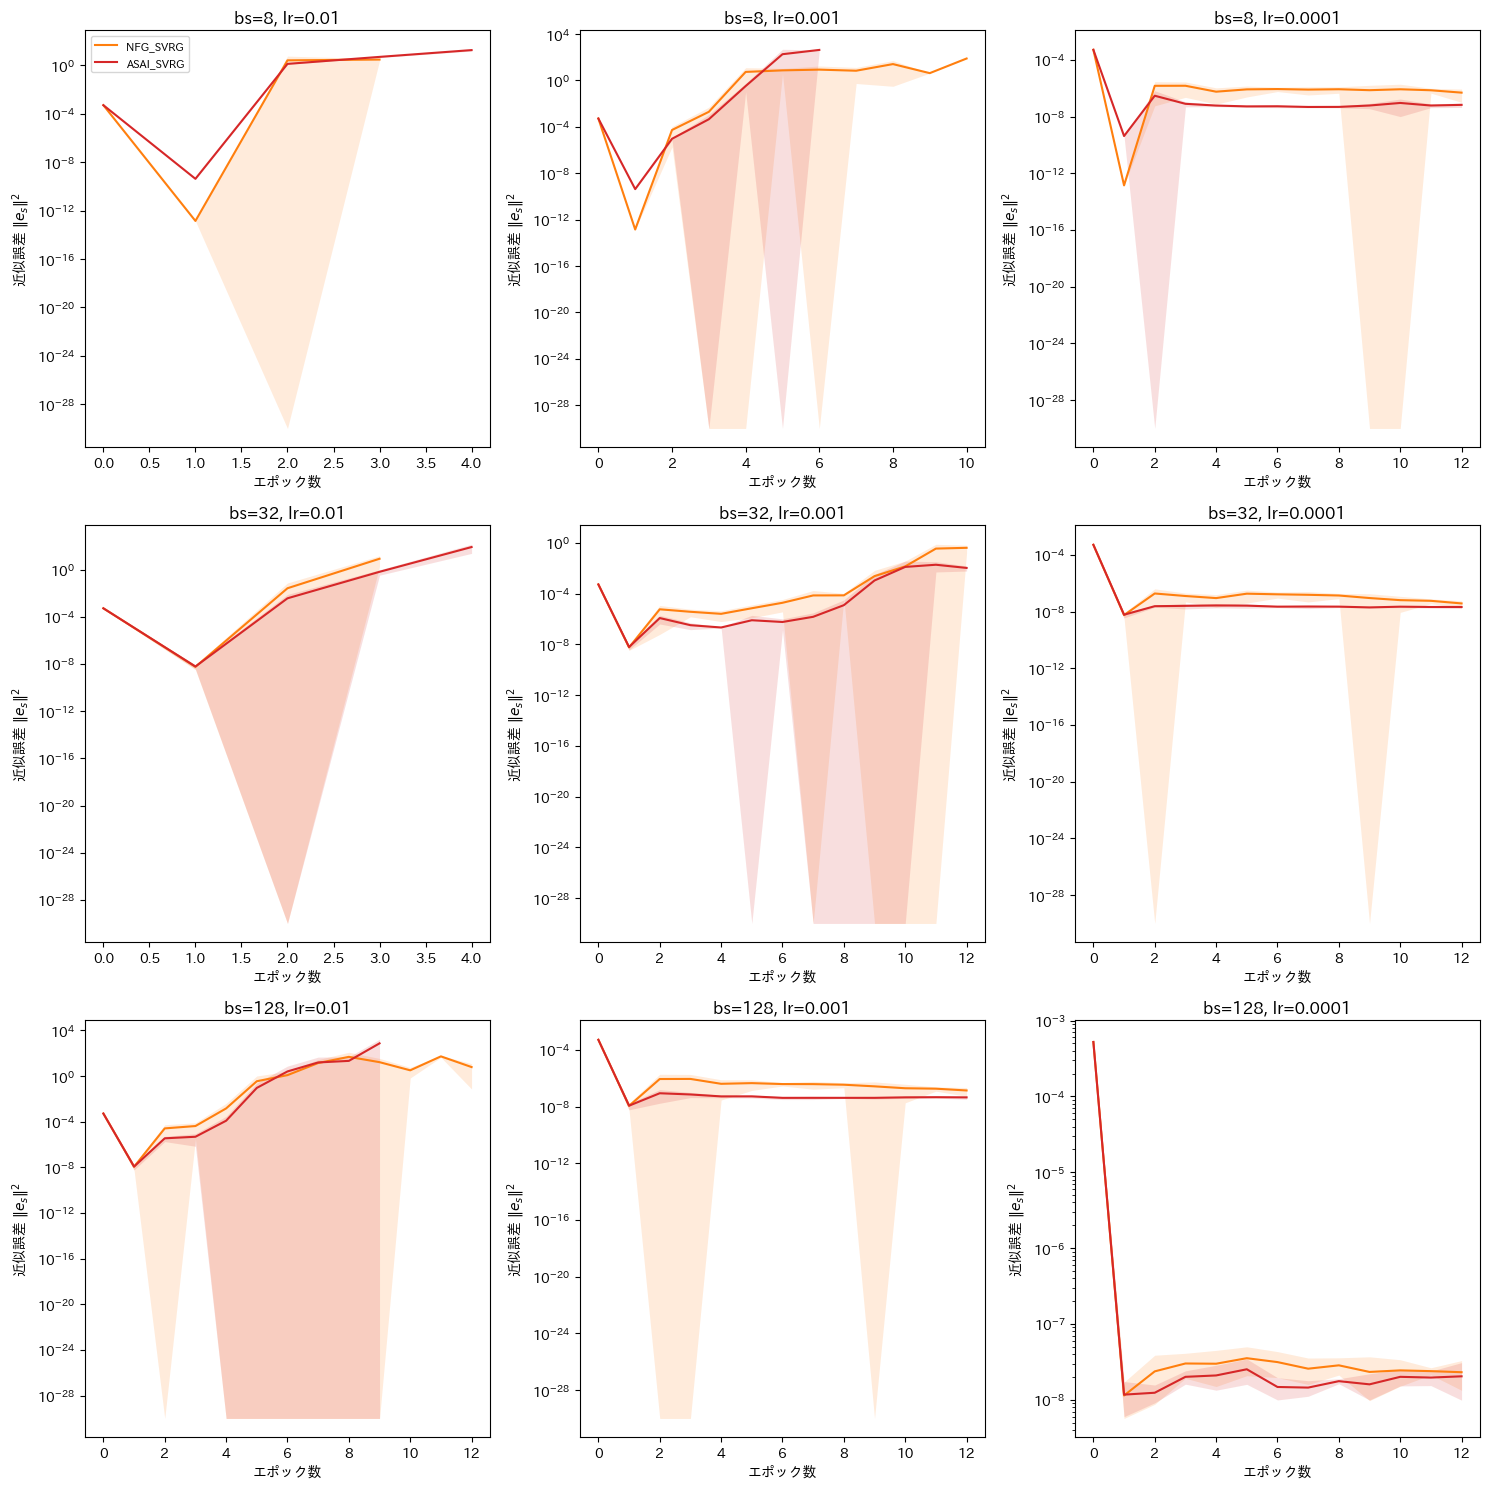

In [11]:
fig, axes = plt.subplots(len(EX002_BATCH_SIZES), len(EX002_LRS), figsize=(15, 15))
for i, bs in enumerate(EX002_BATCH_SIZES):
    for j, lr in enumerate(EX002_LRS):
        ax = axes[i][j]
        for method in ["NFG_SVRG", "ASAI_SVRG"]:
            mean, std, n = ex002_load_all(method, bs, lr, "approx_error")
            if n == 0:
                continue
            x = np.arange(len(mean))
            ax.plot(x, mean, label=method, color=METHOD_COLORS.get(method), linewidth=1.5)
            ax.fill_between(x, np.clip(mean - std, 1e-30, None), mean + std,
                             color=METHOD_COLORS.get(method), alpha=0.15, linewidth=0)
        ax.set_yscale("log")
        ax.set_title(f"bs={bs}, lr={lr}")
        ax.set_xlabel("エポック数")
        ax.set_ylabel(r"近似誤差 $\|e_s\|^2$")
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(EX002_FIGURE_DIR / "approx_error_grid.png", dpi=130, bbox_inches="tight")
plt.show()

### グリッド全体の要約表（最終・最高精度，発散Seed数）

In [12]:
def ex002_summarize_grid() -> str:
    """
    概要: 実験2の全条件（4手法 x 3バッチサイズ x 3学習率）について，最終・最高分類精度と
        発散（NaN）したSeed数をまとめたMarkdown表を作成する．
    引数: なし
    戻り値: table (str)．Markdown形式の表．
    """
    k_map = {bs: int(np.ceil(50000 / bs)) for bs in EX002_BATCH_SIZES}
    lines = [
        "| バッチサイズ | 学習率 | 手法 | 最終精度 | 最高精度 | 発散(NaN)Seed数 | K |",
        "| ---: | ---: | :--- | ---: | ---: | ---: | ---: |",
    ]
    for bs in EX002_BATCH_SIZES:
        for lr in EX002_LRS:
            for method in EX002_METHODS:
                entry = all_results.get((EX002_EXPERIMENT, method, ex002_hp_name(lr, bs)))
                if entry is None:
                    continue
                final_accs, max_accs, n_nan = [], [], 0
                for log in entry["seed_logs"]:
                    final_accs.append(log["test_accuracy"][-1])
                    max_accs.append(max(log["test_accuracy"]))
                    if any(not np.isfinite(v) for v in log["train_loss"]):
                        n_nan += 1
                n = len(entry["seed_logs"])
                lines.append(
                    f"| {bs} | {lr} | {method} | {np.mean(final_accs):.4f} | "
                    f"{np.mean(max_accs):.4f} | {n_nan}/{n} | {k_map[bs]} |"
                )
    return "\n".join(lines)


ex002_table = ex002_summarize_grid()
print(ex002_table)
with open(EX002_FIGURE_DIR / "grid_summary.md", "w") as f:
    f.write(ex002_table + "\n")

| バッチサイズ | 学習率 | 手法 | 最終精度 | 最高精度 | 発散(NaN)Seed数 | K |
| ---: | ---: | :--- | ---: | ---: | ---: | ---: |
| 8 | 0.01 | SGD | 0.7922 | 0.8046 | 0/5 | 6250 |
| 8 | 0.01 | SVRG | 0.7892 | 0.7916 | 0/5 | 6250 |
| 8 | 0.01 | NFG_SVRG | 0.1000 | 0.4330 | 5/5 | 6250 |
| 8 | 0.01 | ASAI_SVRG | 0.1000 | 0.3822 | 5/5 | 6250 |
| 8 | 0.001 | SGD | 0.6018 | 0.6021 | 0/5 | 6250 |
| 8 | 0.001 | SVRG | 0.6271 | 0.6288 | 0/5 | 6250 |
| 8 | 0.001 | NFG_SVRG | 0.1000 | 0.3448 | 5/5 | 6250 |
| 8 | 0.001 | ASAI_SVRG | 0.1000 | 0.3244 | 5/5 | 6250 |
| 8 | 0.0001 | SGD | 0.1276 | 0.1299 | 0/5 | 6250 |
| 8 | 0.0001 | SVRG | 0.1210 | 0.1226 | 0/5 | 6250 |
| 8 | 0.0001 | NFG_SVRG | 0.1136 | 0.1156 | 0/5 | 6250 |
| 8 | 0.0001 | ASAI_SVRG | 0.1133 | 0.1147 | 0/5 | 6250 |
| 32 | 0.01 | SGD | 0.7155 | 0.7189 | 0/5 | 1563 |
| 32 | 0.01 | SVRG | 0.7364 | 0.7384 | 0/5 | 1563 |
| 32 | 0.01 | NFG_SVRG | 0.1000 | 0.3182 | 5/5 | 1563 |
| 32 | 0.01 | ASAI_SVRG | 0.1000 | 0.3573 | 5/5 | 1563 |
| 32 | 0.001 | SGD | 0.3218 | 

## 実験ex0021（CIFAR-10・正規化層の構造的変更）専用の可視化：バッチサイズ×正規化層のグリッド

実験ex0021はバッチサイズ（128, 256, 512）と正規化層（なし，LayerNorm，GroupNorm，
SpectralNorm）の2軸グリッドであり，比較手法はNFG SVRG・ASAI SVRGの2手法のみである．また，
バッチサイズごとにエポック数が異なる（総イテレーション数を揃えるため）．SpectralNormは
`.orders/order_024.md` による追加検証（`.reports/report_024.md`）で正規化層の第4パターン
として追加したものである．

In [13]:
EX0021_EXPERIMENT = "ex0021_cifar10_alexnet_norm"
EX0021_METHODS = ["NFG_SVRG", "ASAI_SVRG"]
EX0021_BATCH_SIZES = [128, 256, 512]
EX0021_NORMS = ["none", "layernorm", "groupnorm", "spectralnorm"]
EX0021_EPOCHS_BY_BS = {128: 12, 256: 24, 512: 48}
EX0021_REG_LAMBDA = 0.0005

EX0021_FIGURE_DIR = OUTPUTS_ROOT / EX0021_EXPERIMENT
EX0021_FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def ex0021_hp_name(bs: int, norm: str) -> str:
    """概要: 実験ex0021のハイパーパラメータ条件名（ディレクトリ名）を構築する．"""
    return f"lr0.001_bs{bs}_norm{norm}_lambda{EX0021_REG_LAMBDA}_epochs{EX0021_EPOCHS_BY_BS[bs]}"


def ex0021_load_all(method: str, bs: int, norm: str, key: str):
    """概要: 実験ex0021の指定条件について，全Seedの指標を読み込み平均・標準偏差を計算する．"""
    entry = all_results.get((EX0021_EXPERIMENT, method, ex0021_hp_name(bs, norm)))
    if entry is None:
        return np.array([]), np.array([]), 0
    values = np.array([log[key] for log in entry["seed_logs"]], dtype=np.float64)
    return np.nanmean(values, axis=0), np.nanstd(values, axis=0), values.shape[0]

### 分類精度のグリッド（縦：バッチサイズ，横：正規化層）

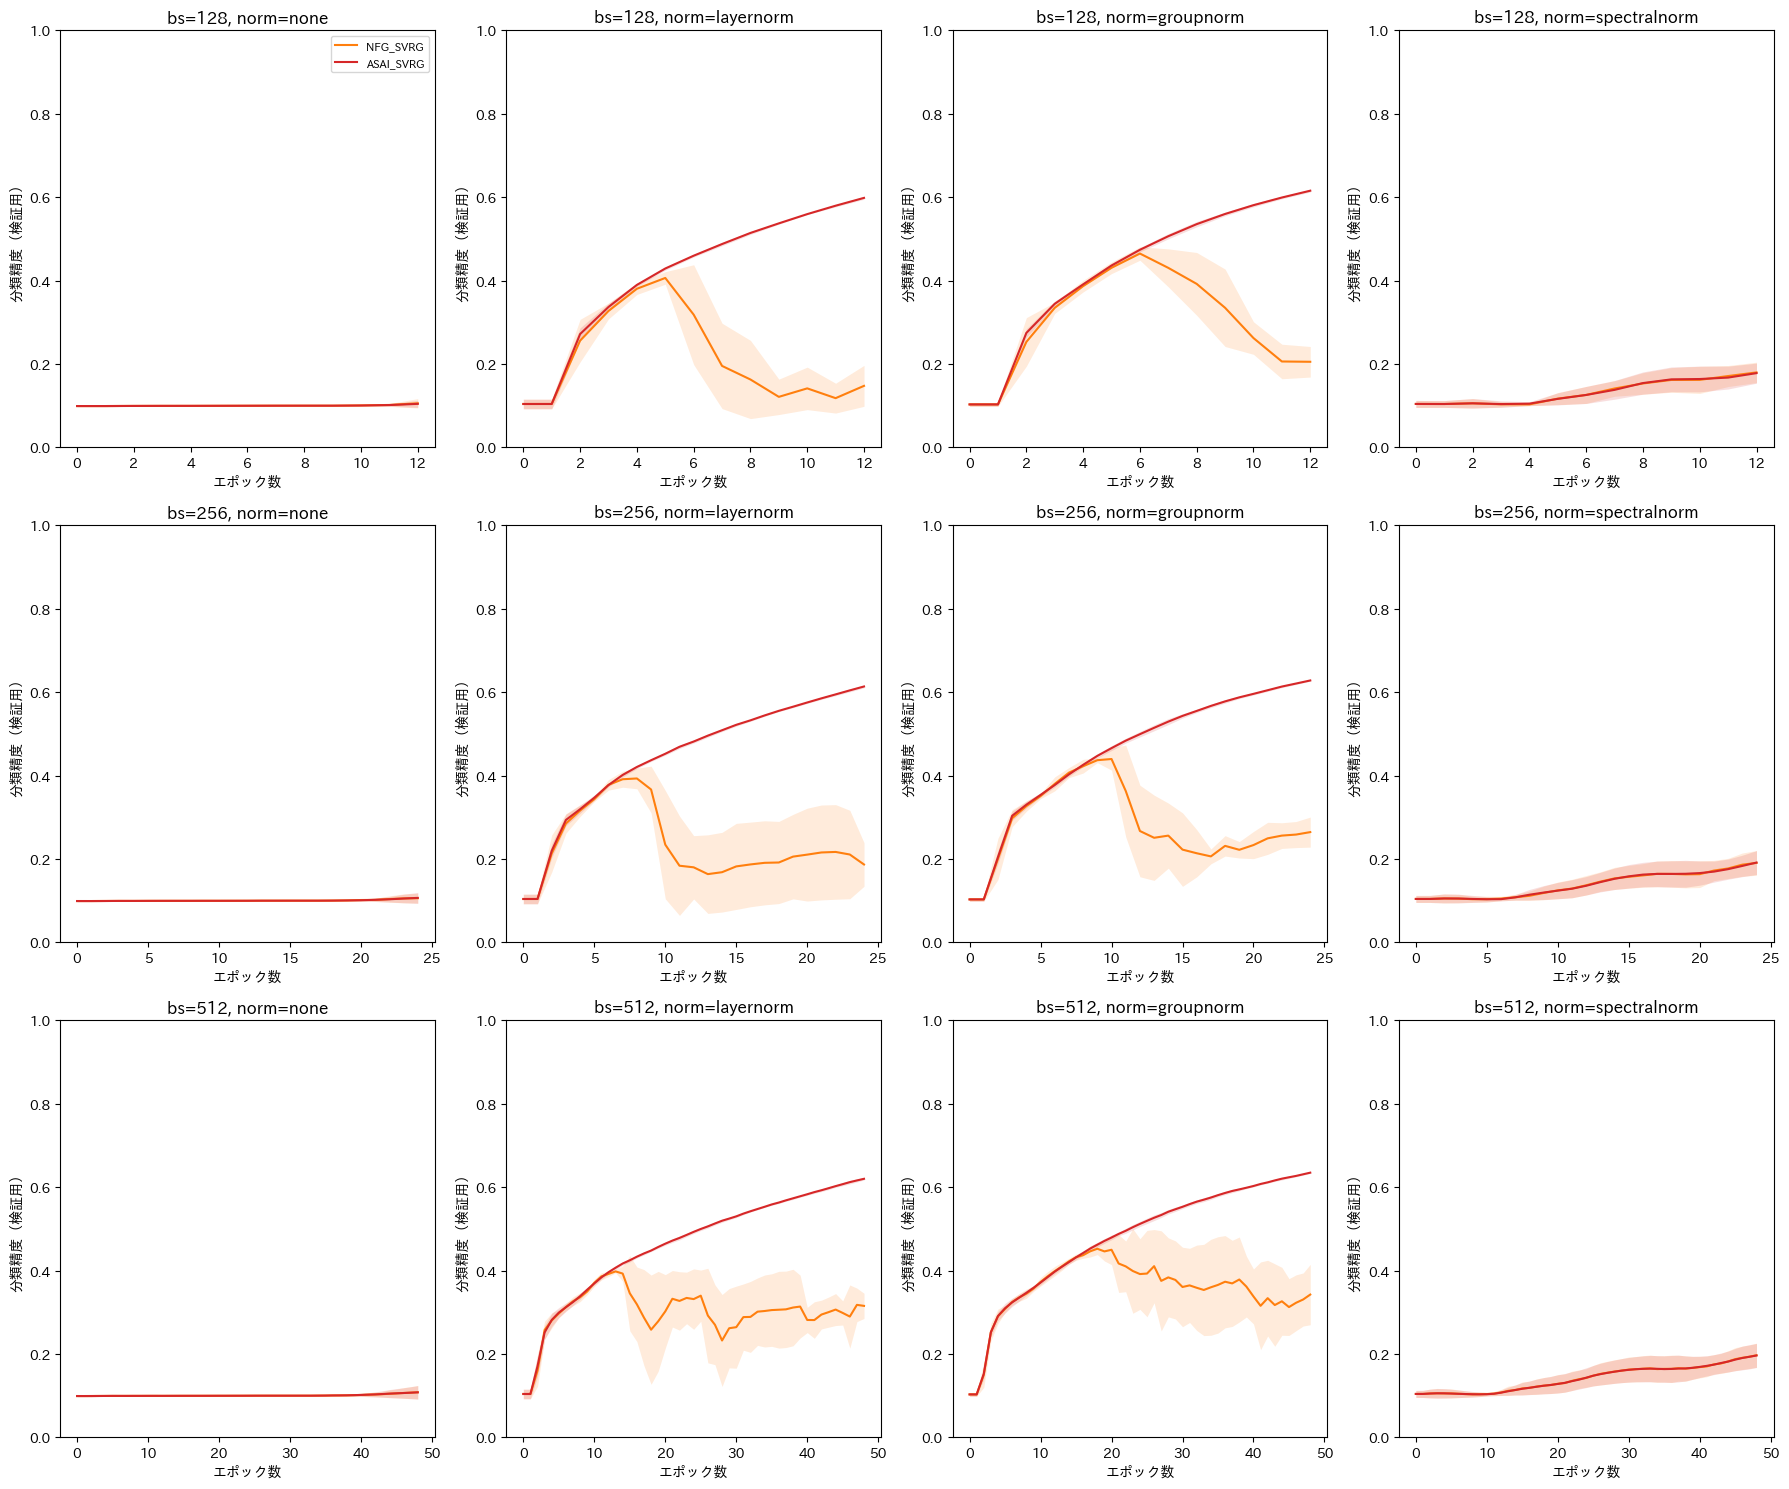

In [14]:
fig, axes = plt.subplots(len(EX0021_BATCH_SIZES), len(EX0021_NORMS), figsize=(18, 15))
for i, bs in enumerate(EX0021_BATCH_SIZES):
    for j, norm in enumerate(EX0021_NORMS):
        ax = axes[i][j]
        for method in EX0021_METHODS:
            mean, std, n = ex0021_load_all(method, bs, norm, "test_accuracy")
            if n == 0:
                continue
            x = np.arange(len(mean))
            ax.plot(x, mean, label=method, color=METHOD_COLORS.get(method), linewidth=1.5)
            ax.fill_between(x, mean - std, mean + std, color=METHOD_COLORS.get(method), alpha=0.15, linewidth=0)
        ax.set_title(f"bs={bs}, norm={norm}")
        ax.set_xlabel("エポック数")
        ax.set_ylabel("分類精度（検証用）")
        ax.set_ylim(0, 1)
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(EX0021_FIGURE_DIR / "accuracy_grid.png", dpi=130, bbox_inches="tight")
plt.show()

### フル勾配の近似誤差のグリッド

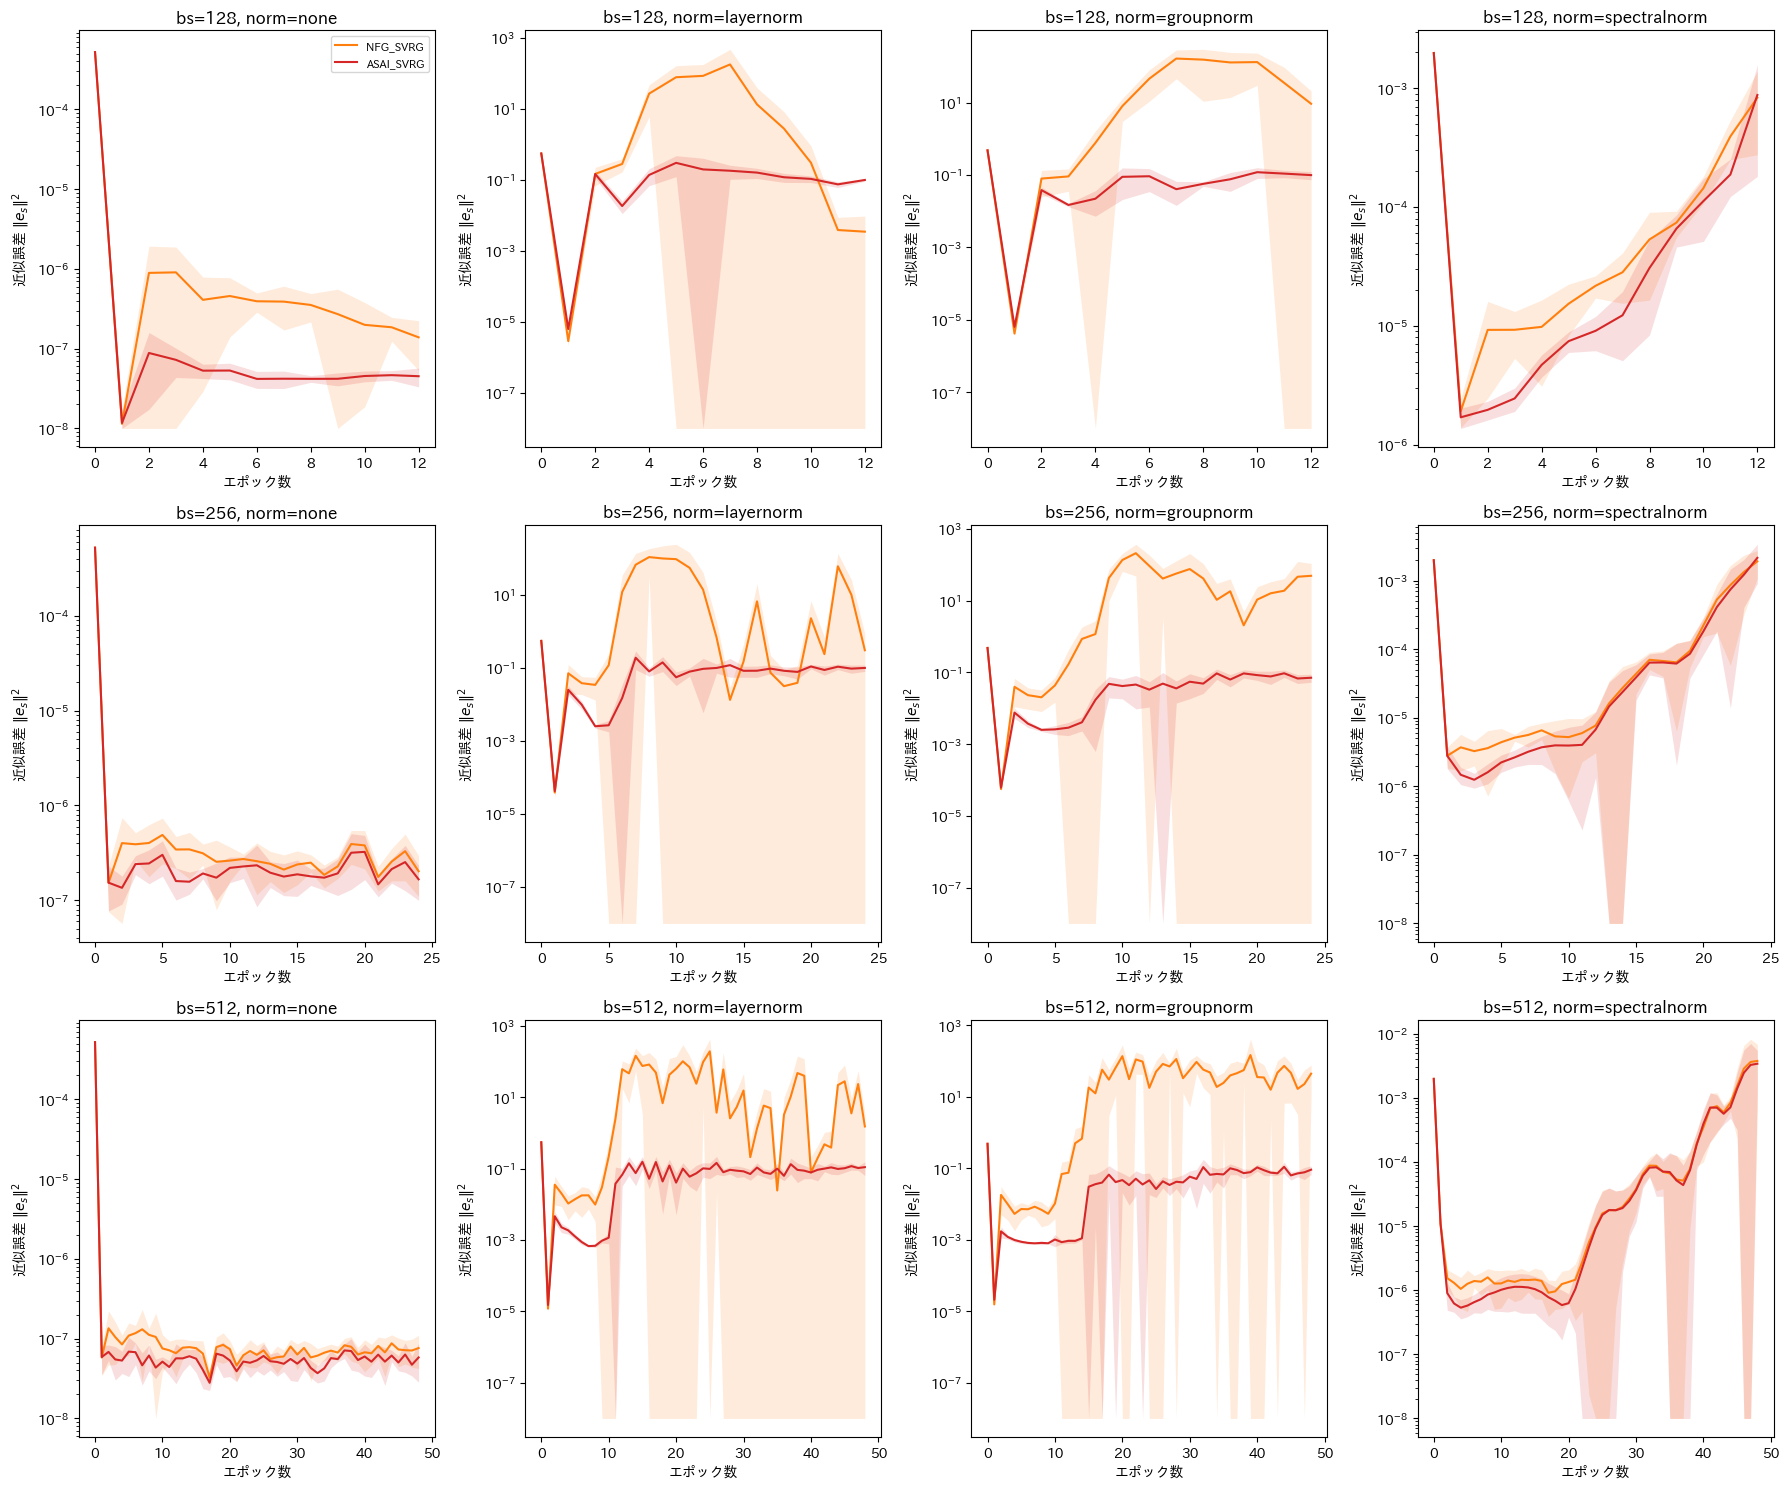

In [15]:
fig, axes = plt.subplots(len(EX0021_BATCH_SIZES), len(EX0021_NORMS), figsize=(18, 15))
for i, bs in enumerate(EX0021_BATCH_SIZES):
    for j, norm in enumerate(EX0021_NORMS):
        ax = axes[i][j]
        for method in EX0021_METHODS:
            mean, std, n = ex0021_load_all(method, bs, norm, "approx_error")
            if n == 0:
                continue
            x = np.arange(len(mean))
            ax.plot(x, mean, label=method, color=METHOD_COLORS.get(method), linewidth=1.5)
            ax.fill_between(x, np.clip(mean - std, 1e-8, None), mean + std,
                             color=METHOD_COLORS.get(method), alpha=0.15, linewidth=0)
        ax.set_yscale("log")
        ax.set_title(f"bs={bs}, norm={norm}")
        ax.set_xlabel("エポック数")
        ax.set_ylabel(r"近似誤差 $\|e_s\|^2$")
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(EX0021_FIGURE_DIR / "approx_error_grid.png", dpi=130, bbox_inches="tight")
plt.show()

### GroupNormにおける分類精度と近似誤差の対応（バッチサイズ別）

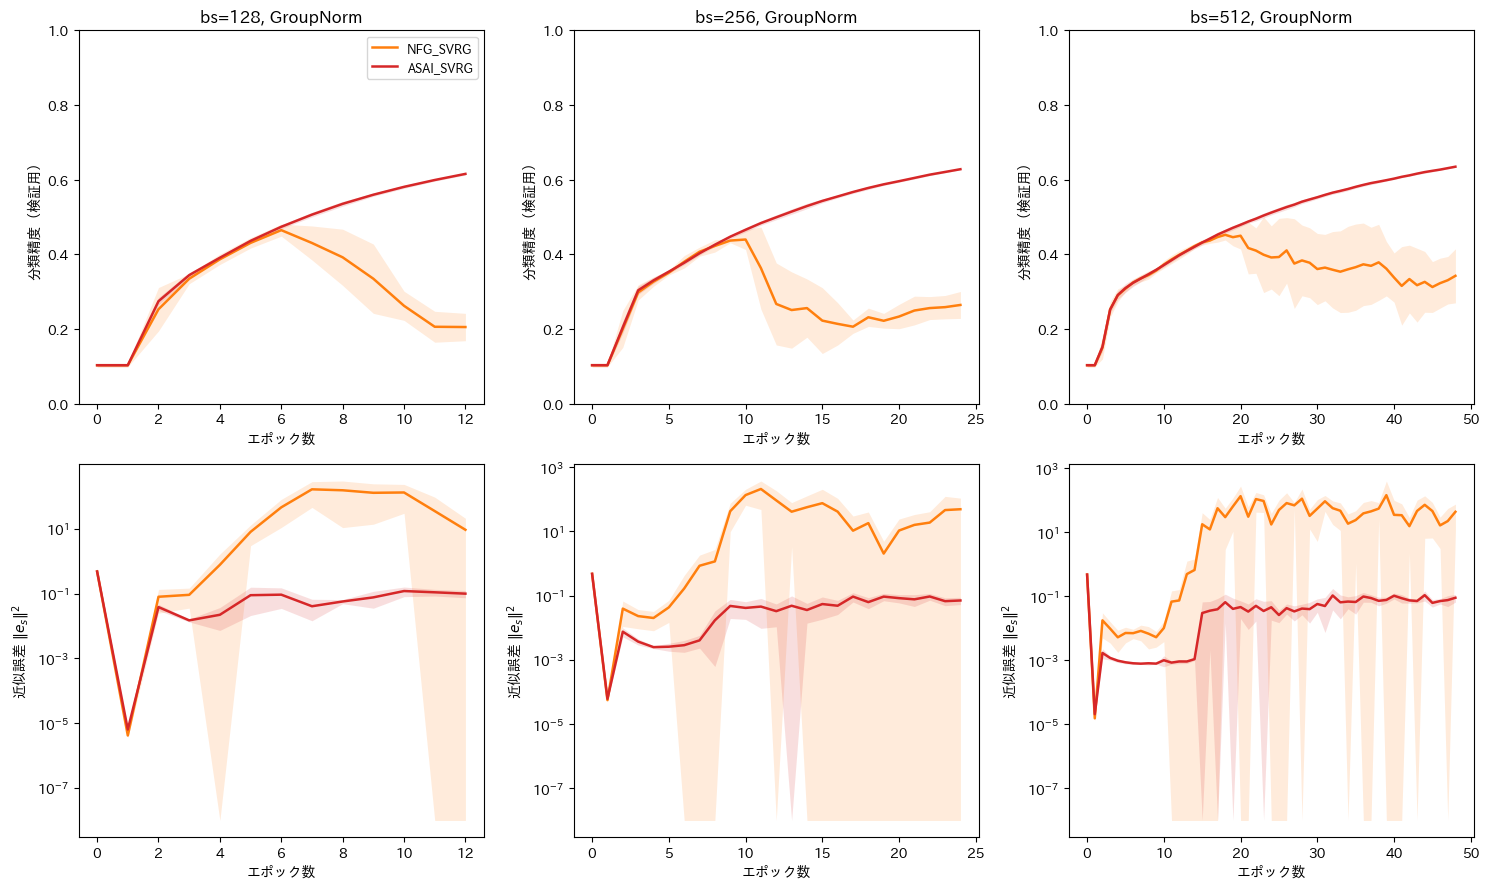

In [16]:
fig, axes = plt.subplots(2, len(EX0021_BATCH_SIZES), figsize=(15, 9))
for j, bs in enumerate(EX0021_BATCH_SIZES):
    ax_acc, ax_err = axes[0][j], axes[1][j]
    for method in EX0021_METHODS:
        acc_mean, acc_std, _ = ex0021_load_all(method, bs, "groupnorm", "test_accuracy")
        err_mean, err_std, _ = ex0021_load_all(method, bs, "groupnorm", "approx_error")
        x = np.arange(len(acc_mean))
        ax_acc.plot(x, acc_mean, label=method, color=METHOD_COLORS.get(method), linewidth=1.8)
        ax_acc.fill_between(x, acc_mean - acc_std, acc_mean + acc_std, color=METHOD_COLORS.get(method), alpha=0.15, linewidth=0)
        ax_err.plot(x, err_mean, label=method, color=METHOD_COLORS.get(method), linewidth=1.8)
        ax_err.fill_between(x, np.clip(err_mean - err_std, 1e-8, None), err_mean + err_std,
                             color=METHOD_COLORS.get(method), alpha=0.15, linewidth=0)
    ax_acc.set_title(f"bs={bs}, GroupNorm")
    ax_acc.set_xlabel("エポック数"); ax_acc.set_ylabel("分類精度（検証用）"); ax_acc.set_ylim(0, 1)
    ax_err.set_yscale("log")
    ax_err.set_xlabel("エポック数"); ax_err.set_ylabel(r"近似誤差 $\|e_s\|^2$")
    if j == 0:
        ax_acc.legend(fontsize=9)
fig.tight_layout()
fig.savefig(EX0021_FIGURE_DIR / "groupnorm_accuracy_vs_approx_error.png", dpi=150, bbox_inches="tight")
plt.show()

### SpectralNormにおける分類精度と近似誤差の対応（バッチサイズ別）

`.orders/order_024.md` による追加検証（`.reports/report_024.md`）．GroupNormと同じ形式で
SpectralNorm条件を示す．GroupNormでは学習後半にNFG SVRGの近似誤差が$10^0\sim10^2$の
オーダーまで爆発し分類精度が崩壊するのに対し，SpectralNormでは同様の（相対的な）誤差増大は
生じるものの絶対スケールは$10^{-3}$程度にとどまり，精度崩壊を伴わない．一方で分類精度自体は
GroupNormよりも大幅に低く頭打ちになり，NFG SVRGとASAI SVRGの差もほぼ消失する．

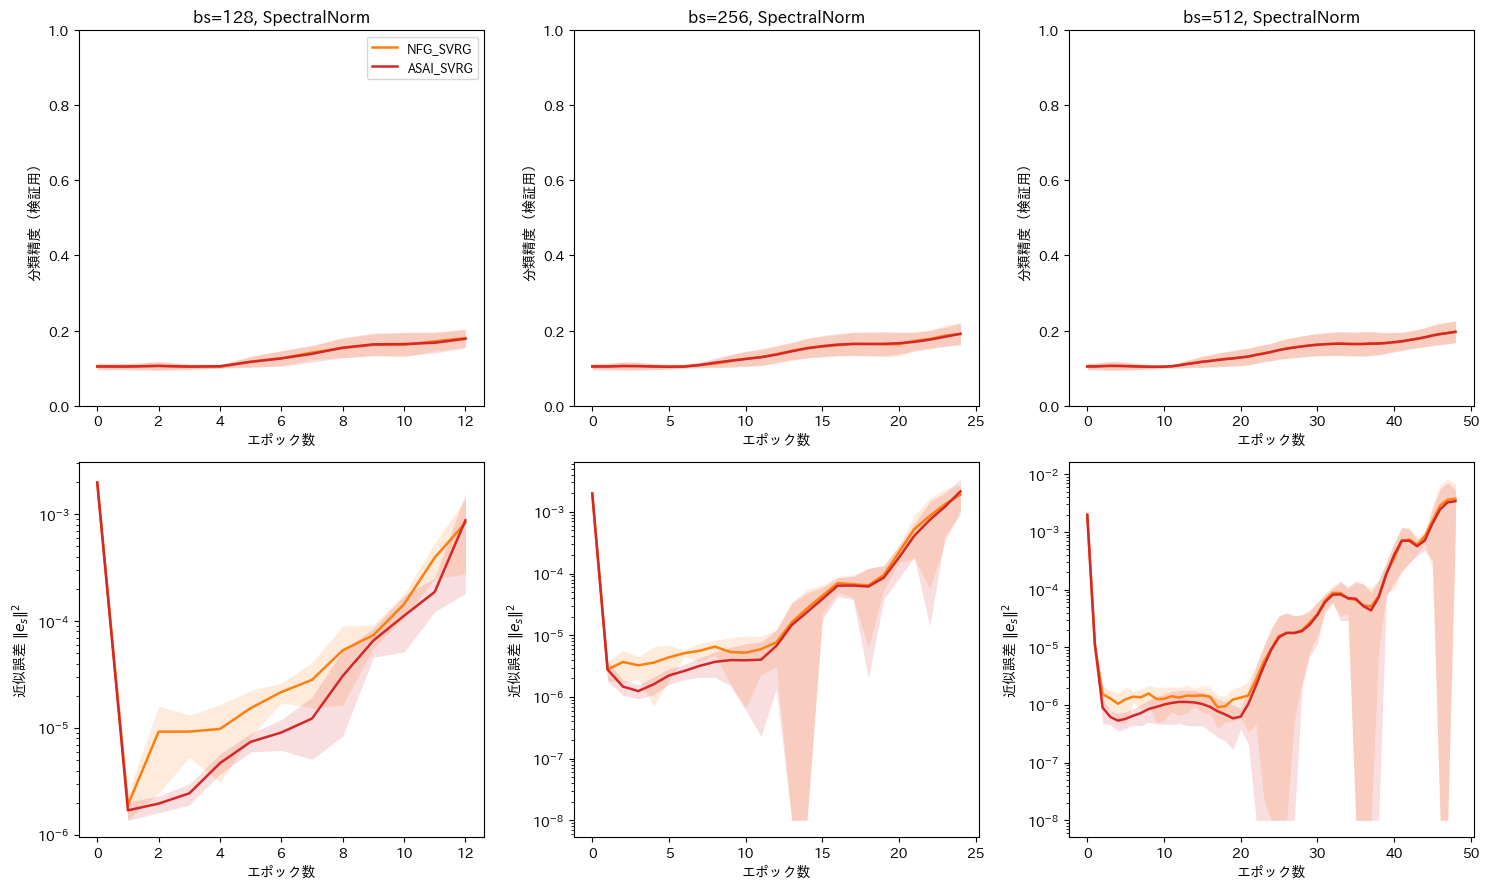

In [17]:
fig, axes = plt.subplots(2, len(EX0021_BATCH_SIZES), figsize=(15, 9))
for j, bs in enumerate(EX0021_BATCH_SIZES):
    ax_acc, ax_err = axes[0][j], axes[1][j]
    for method in EX0021_METHODS:
        acc_mean, acc_std, _ = ex0021_load_all(method, bs, "spectralnorm", "test_accuracy")
        err_mean, err_std, _ = ex0021_load_all(method, bs, "spectralnorm", "approx_error")
        x = np.arange(len(acc_mean))
        ax_acc.plot(x, acc_mean, label=method, color=METHOD_COLORS.get(method), linewidth=1.8)
        ax_acc.fill_between(x, acc_mean - acc_std, acc_mean + acc_std, color=METHOD_COLORS.get(method), alpha=0.15, linewidth=0)
        ax_err.plot(x, err_mean, label=method, color=METHOD_COLORS.get(method), linewidth=1.8)
        ax_err.fill_between(x, np.clip(err_mean - err_std, 1e-8, None), err_mean + err_std,
                             color=METHOD_COLORS.get(method), alpha=0.15, linewidth=0)
    ax_acc.set_title(f"bs={bs}, SpectralNorm")
    ax_acc.set_xlabel("エポック数"); ax_acc.set_ylabel("分類精度（検証用）"); ax_acc.set_ylim(0, 1)
    ax_err.set_yscale("log")
    ax_err.set_xlabel("エポック数"); ax_err.set_ylabel(r"近似誤差 $\|e_s\|^2$")
    if j == 0:
        ax_acc.legend(fontsize=9)
fig.tight_layout()
fig.savefig(EX0021_FIGURE_DIR / "spectralnorm_accuracy_vs_approx_error.png", dpi=150, bbox_inches="tight")
plt.show()

### グリッド全体の要約表

In [18]:
def ex0021_summarize_grid() -> str:
    """概要: 実験ex0021の全条件について，最終・最高分類精度と発散Seed数をまとめる．"""
    lines = [
        "| バッチサイズ | 正規化層 | 手法 | 最終精度 | 最高精度 | 発散(NaN)Seed数 |",
        "| ---: | :--- | :--- | ---: | ---: | ---: |",
    ]
    for bs in EX0021_BATCH_SIZES:
        for norm in EX0021_NORMS:
            for method in EX0021_METHODS:
                entry = all_results.get((EX0021_EXPERIMENT, method, ex0021_hp_name(bs, norm)))
                if entry is None:
                    continue
                final_accs, max_accs, n_nan = [], [], 0
                for log in entry["seed_logs"]:
                    final_accs.append(log["test_accuracy"][-1])
                    max_accs.append(max(log["test_accuracy"]))
                    if any(not np.isfinite(v) for v in log["train_loss"]):
                        n_nan += 1
                n = len(entry["seed_logs"])
                lines.append(
                    f"| {bs} | {norm} | {method} | {np.mean(final_accs):.4f} | "
                    f"{np.mean(max_accs):.4f} | {n_nan}/{n} |"
                )
    return "\n".join(lines)


ex0021_table = ex0021_summarize_grid()
print(ex0021_table)
with open(EX0021_FIGURE_DIR / "grid_summary.md", "w") as f:
    f.write(ex0021_table + "\n")

| バッチサイズ | 正規化層 | 手法 | 最終精度 | 最高精度 | 発散(NaN)Seed数 |
| ---: | :--- | :--- | ---: | ---: | ---: |
| 128 | none | NFG_SVRG | 0.1058 | 0.1058 | 0/5 |
| 128 | none | ASAI_SVRG | 0.1044 | 0.1044 | 0/5 |
| 128 | layernorm | NFG_SVRG | 0.1476 | 0.4126 | 0/5 |
| 128 | layernorm | ASAI_SVRG | 0.5983 | 0.5983 | 0/5 |
| 128 | groupnorm | NFG_SVRG | 0.2053 | 0.4712 | 0/5 |
| 128 | groupnorm | ASAI_SVRG | 0.6155 | 0.6155 | 0/5 |
| 128 | spectralnorm | NFG_SVRG | 0.1798 | 0.1903 | 0/5 |
| 128 | spectralnorm | ASAI_SVRG | 0.1781 | 0.1900 | 0/5 |
| 256 | none | NFG_SVRG | 0.1059 | 0.1059 | 0/5 |
| 256 | none | ASAI_SVRG | 0.1067 | 0.1067 | 0/5 |
| 256 | layernorm | NFG_SVRG | 0.1868 | 0.4132 | 0/5 |
| 256 | layernorm | ASAI_SVRG | 0.6136 | 0.6136 | 0/5 |
| 256 | groupnorm | NFG_SVRG | 0.2645 | 0.4504 | 0/5 |
| 256 | groupnorm | ASAI_SVRG | 0.6280 | 0.6280 | 0/5 |
| 256 | spectralnorm | NFG_SVRG | 0.1906 | 0.2030 | 0/5 |
| 256 | spectralnorm | ASAI_SVRG | 0.1915 | 0.2036 | 0/5 |
| 512 | none | NFG_SVRG 

## 実験ex0022（GroupNorm下での4手法比較，分散削減の効率性検証）専用の可視化

`.orders/order_025.md` に対応する．GroupNorm固定のもと，SGD・SVRG・NFG SVRG・ASAI SVRGの
4手法をバッチサイズ（512, 128, 32）・学習率（0.01, 0.001）のグリッドで比較する．主たる
評価軸はオラクル呼び出し回数（`oracle_calls`）であり，同一のオラクル呼び出し回数のもとで
ASAI SVRGが他手法より効率的に学習を進められるかを検証する．

In [19]:
EX0022_EXPERIMENT = "ex0022_cifar10_alexnet_groupnorm"
EX0022_METHODS = ["SGD", "SVRG", "NFG_SVRG", "ASAI_SVRG"]
EX0022_BATCH_SIZES = [512, 128, 32]
EX0022_LRS = [0.01, 0.001]
EX0022_EPOCHS_BY_BS = {512: 48, 128: 12, 32: 3}
EX0022_REG_LAMBDA = 0.0005

EX0022_FIGURE_DIR = OUTPUTS_ROOT / EX0022_EXPERIMENT
EX0022_FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def ex0022_hp_name(lr: float, bs: int) -> str:
    """概要: 実験ex0022のハイパーパラメータ条件名（ディレクトリ名）を構築する．"""
    return f"lr{lr}_bs{bs}_normgroupnorm_lambda{EX0022_REG_LAMBDA}_epochs{EX0022_EPOCHS_BY_BS[bs]}"


def ex0022_load_all(method: str, bs: int, lr: float, key: str):
    """概要: 実験ex0022の指定条件について，全Seedの指標を読み込み平均・標準偏差を計算する．"""
    entry = all_results.get((EX0022_EXPERIMENT, method, ex0022_hp_name(lr, bs)))
    if entry is None:
        return np.array([]), np.array([]), 0
    values = np.array([log[key] for log in entry["seed_logs"]], dtype=np.float64)
    return np.nanmean(values, axis=0), np.nanstd(values, axis=0), values.shape[0]


### 分類精度のグリッド（縦：バッチサイズ，横：学習率，エポック数を横軸）

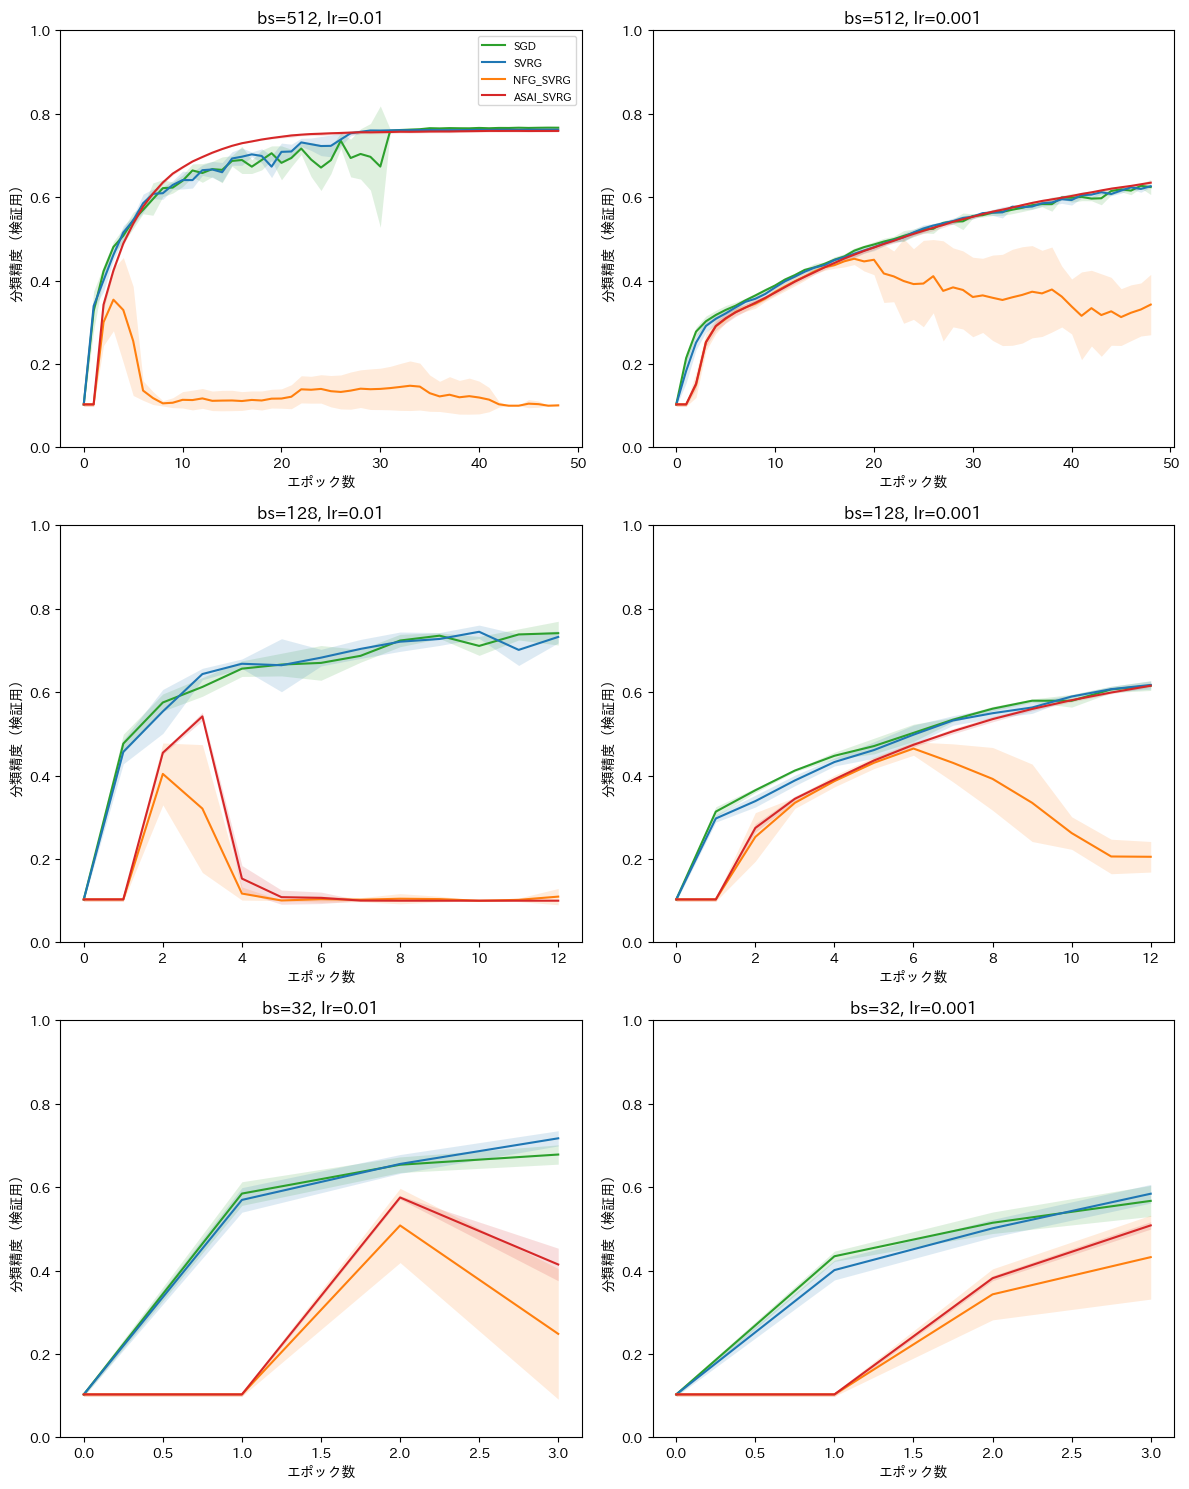

In [20]:
fig, axes = plt.subplots(len(EX0022_BATCH_SIZES), len(EX0022_LRS), figsize=(12, 15))
for i, bs in enumerate(EX0022_BATCH_SIZES):
    for j, lr in enumerate(EX0022_LRS):
        ax = axes[i][j]
        for method in EX0022_METHODS:
            mean, std, n = ex0022_load_all(method, bs, lr, "test_accuracy")
            if n == 0:
                continue
            x = np.arange(len(mean))
            ax.plot(x, mean, label=method, color=METHOD_COLORS.get(method), linewidth=1.5)
            ax.fill_between(x, mean - std, mean + std, color=METHOD_COLORS.get(method), alpha=0.15, linewidth=0)
        ax.set_title(f"bs={bs}, lr={lr}")
        ax.set_xlabel("エポック数")
        ax.set_ylabel("分類精度（検証用）")
        ax.set_ylim(0, 1)
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(EX0022_FIGURE_DIR / "accuracy_grid_by_epoch.png", dpi=130, bbox_inches="tight")
plt.show()


### オラクル呼び出し回数を横軸とした分類精度の比較（縦：バッチサイズ，横：学習率）

`.orders/order_025.md` 7節1項が要求する分散削減の効率性検証の中心的な図である．オラクル
呼び出し回数（`oracle_calls`，勾配計算1回分をサンプル数で正規化した回数）を横軸とすることで，
SVRG・NFG SVRG・ASAI SVRGがそれぞれ異なる計算コスト（1エポックあたりSGDはN，NFG SVRG・
ASAI SVRGは2N，SVRGは3N）を要することを揃えた，公平な効率性比較となる。

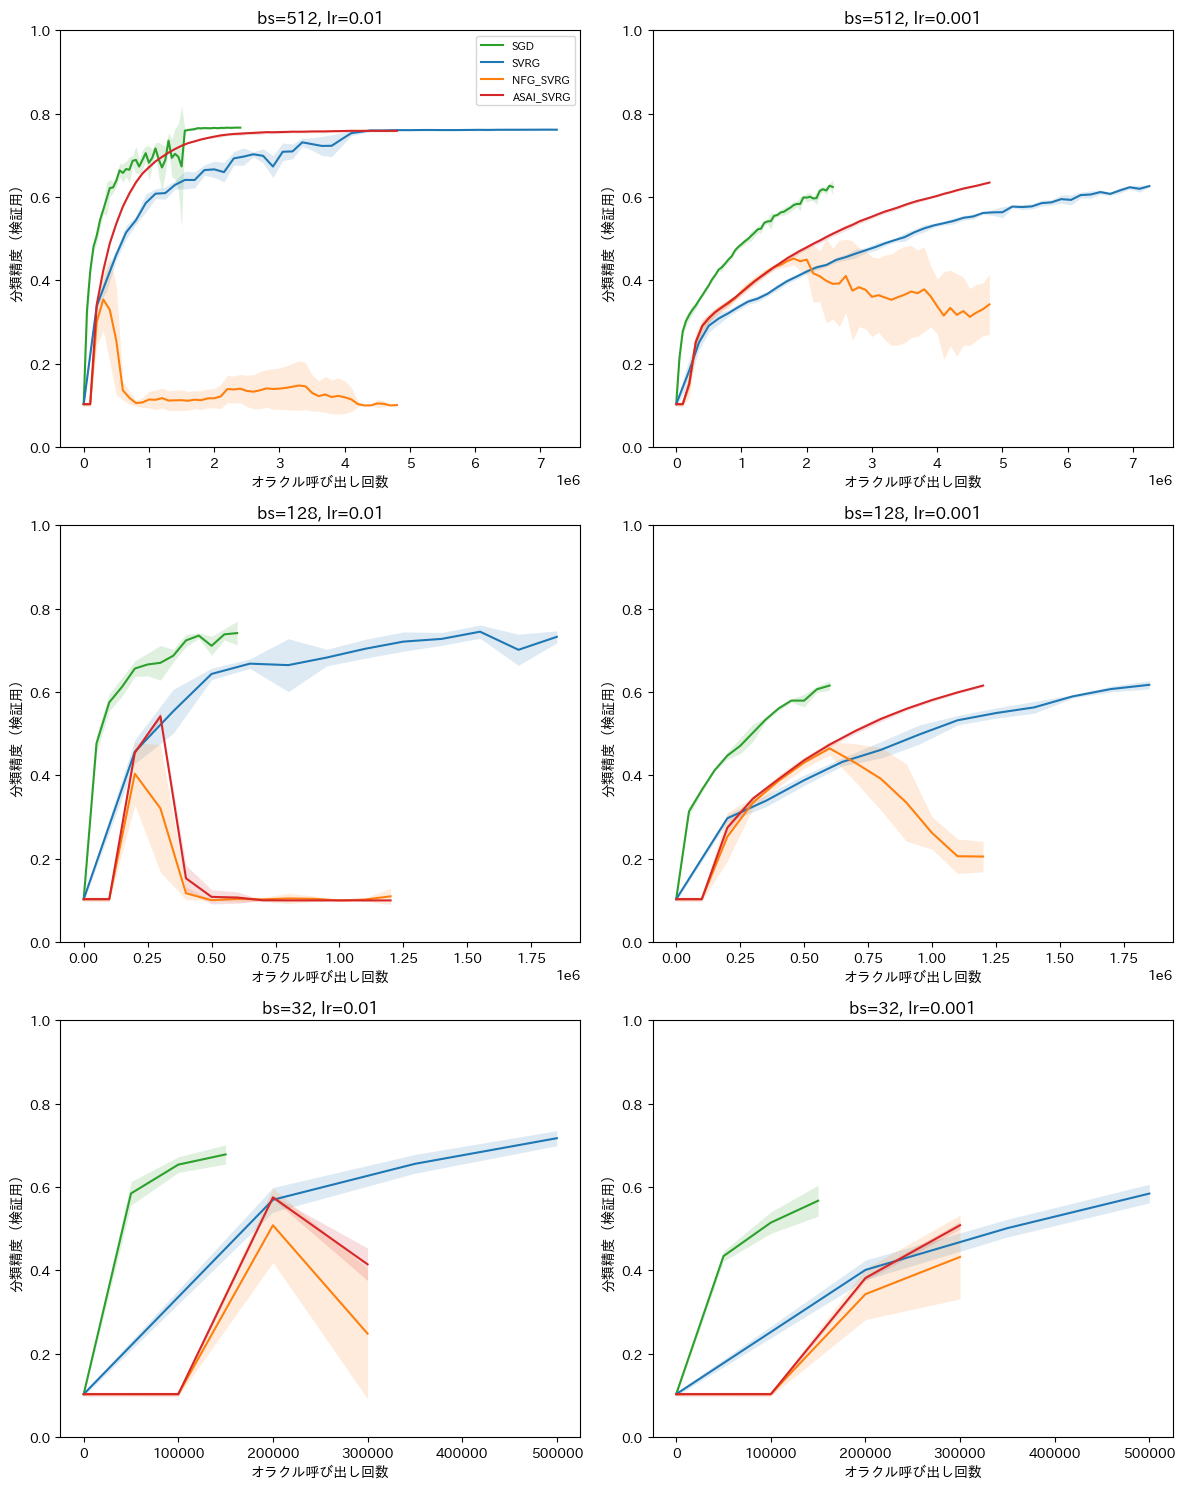

In [21]:
fig, axes = plt.subplots(len(EX0022_BATCH_SIZES), len(EX0022_LRS), figsize=(12, 15))
for i, bs in enumerate(EX0022_BATCH_SIZES):
    for j, lr in enumerate(EX0022_LRS):
        ax = axes[i][j]
        for method in EX0022_METHODS:
            acc_mean, acc_std, n = ex0022_load_all(method, bs, lr, "test_accuracy")
            oracle_mean, _, _ = ex0022_load_all(method, bs, lr, "oracle_calls")
            if n == 0:
                continue
            ax.plot(oracle_mean, acc_mean, label=method, color=METHOD_COLORS.get(method), linewidth=1.5)
            ax.fill_between(oracle_mean, acc_mean - acc_std, acc_mean + acc_std,
                             color=METHOD_COLORS.get(method), alpha=0.15, linewidth=0)
        ax.set_title(f"bs={bs}, lr={lr}")
        ax.set_xlabel("オラクル呼び出し回数")
        ax.set_ylabel("分類精度（検証用）")
        ax.set_ylim(0, 1)
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(EX0022_FIGURE_DIR / "accuracy_grid_by_oracle_calls.png", dpi=130, bbox_inches="tight")
plt.show()


### フル勾配の近似誤差のグリッド（SVRG・NFG SVRG・ASAI SVRGのみ）

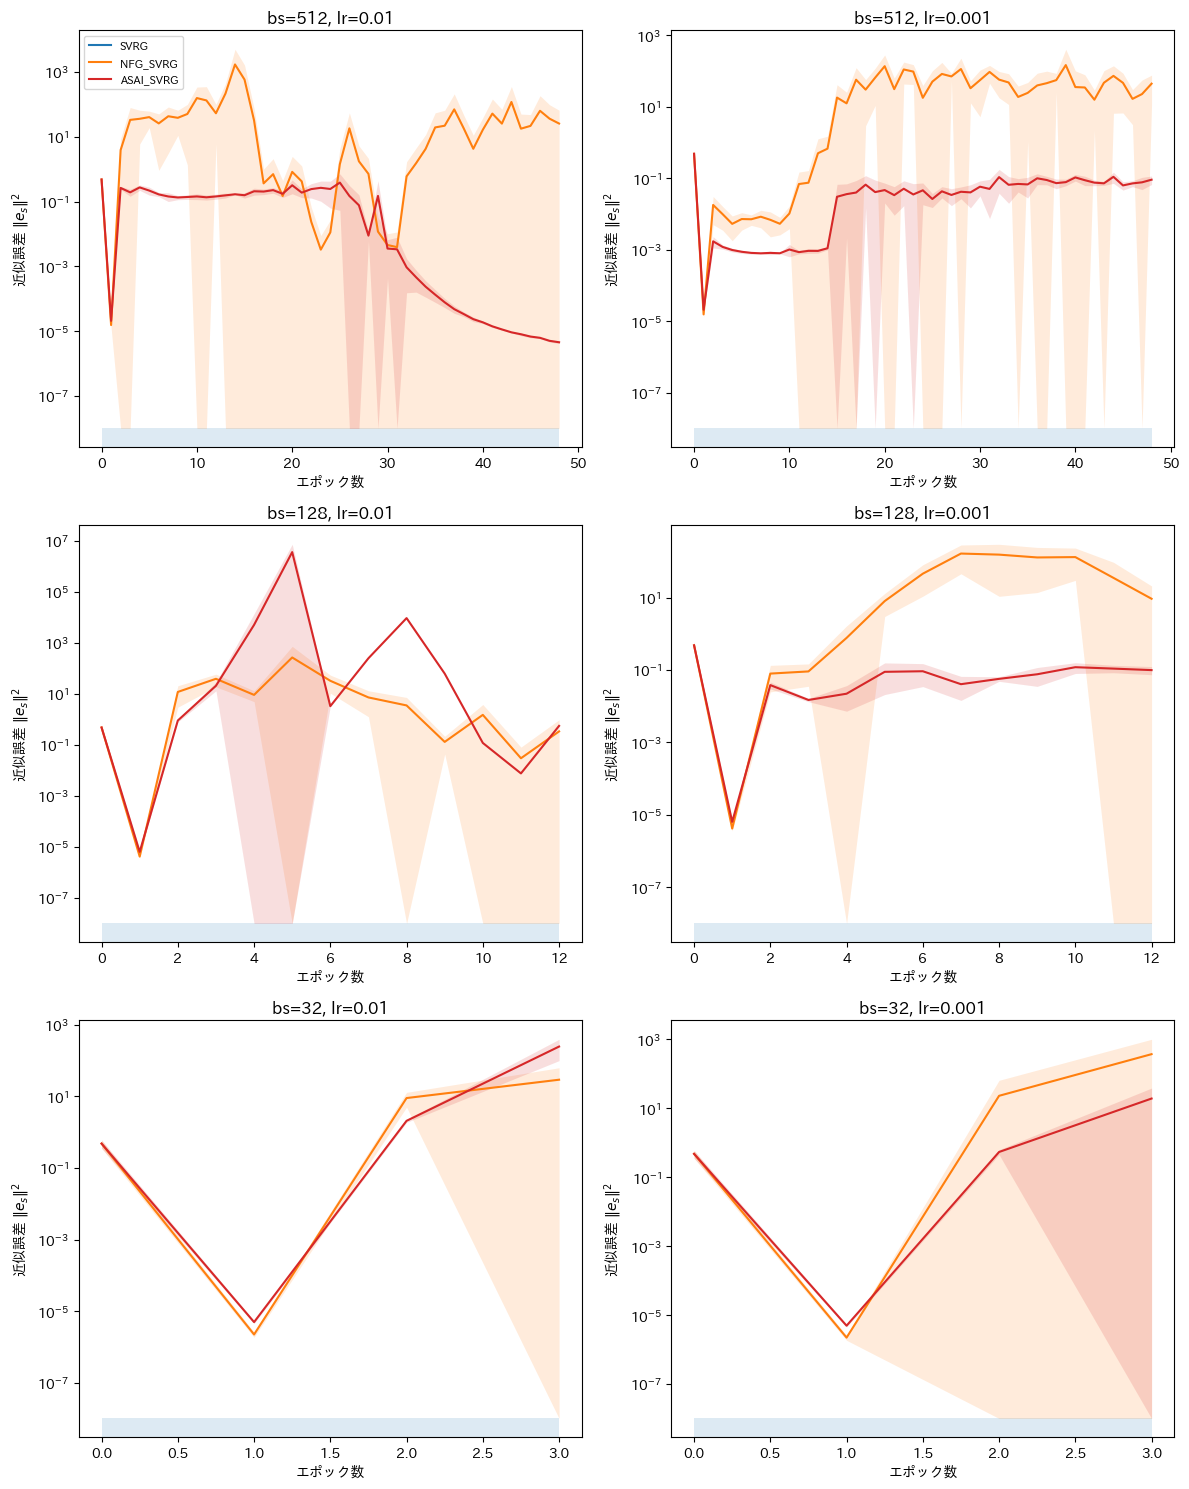

In [22]:
fig, axes = plt.subplots(len(EX0022_BATCH_SIZES), len(EX0022_LRS), figsize=(12, 15))
for i, bs in enumerate(EX0022_BATCH_SIZES):
    for j, lr in enumerate(EX0022_LRS):
        ax = axes[i][j]
        for method in ["SVRG", "NFG_SVRG", "ASAI_SVRG"]:
            mean, std, n = ex0022_load_all(method, bs, lr, "approx_error")
            if n == 0:
                continue
            x = np.arange(len(mean))
            ax.plot(x, mean, label=method, color=METHOD_COLORS.get(method), linewidth=1.5)
            ax.fill_between(x, np.clip(mean - std, 1e-8, None), mean + std,
                             color=METHOD_COLORS.get(method), alpha=0.15, linewidth=0)
        ax.set_yscale("log")
        ax.set_title(f"bs={bs}, lr={lr}")
        ax.set_xlabel("エポック数")
        ax.set_ylabel(r"近似誤差 $\|e_s\|^2$")
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(EX0022_FIGURE_DIR / "approx_error_grid.png", dpi=130, bbox_inches="tight")
plt.show()


### 訓練誤差（train_loss）のグリッド（縦：バッチサイズ，横：学習率，横軸：エポック数）

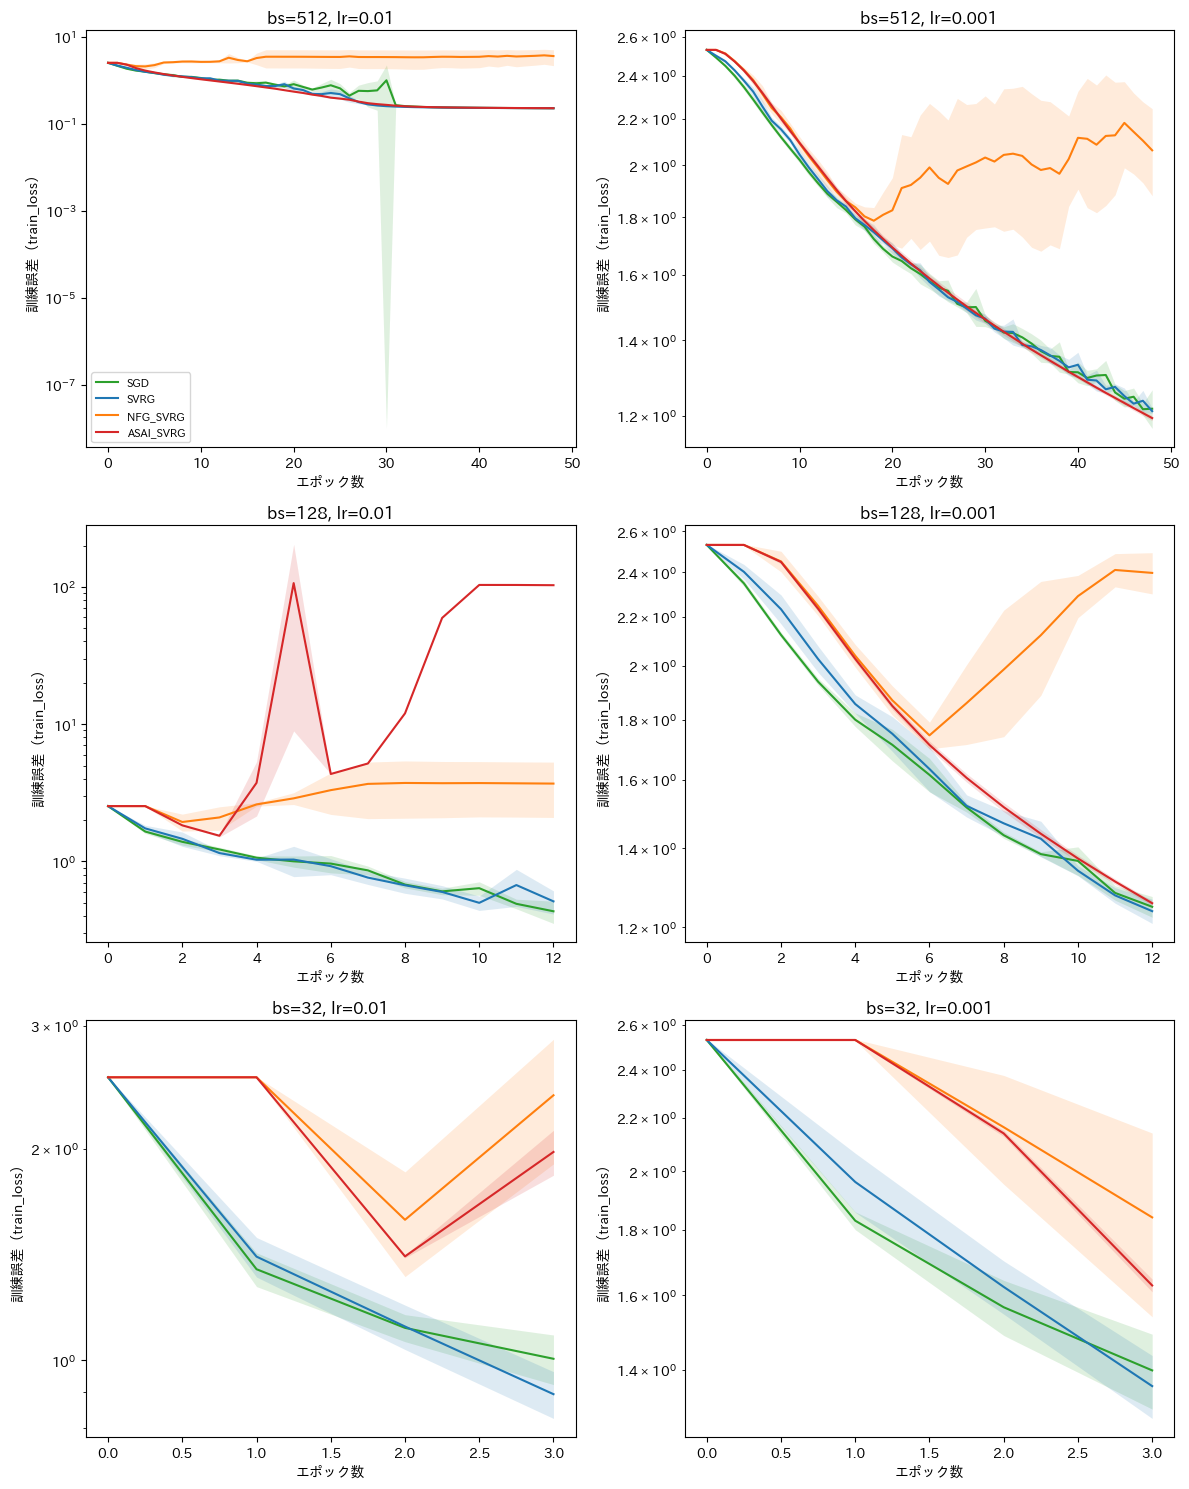

In [23]:
fig, axes = plt.subplots(len(EX0022_BATCH_SIZES), len(EX0022_LRS), figsize=(12, 15))
for i, bs in enumerate(EX0022_BATCH_SIZES):
    for j, lr in enumerate(EX0022_LRS):
        ax = axes[i][j]
        for method in EX0022_METHODS:
            mean, std, n = ex0022_load_all(method, bs, lr, "train_loss")
            if n == 0:
                continue
            x = np.arange(len(mean))
            ax.plot(x, mean, label=method, color=METHOD_COLORS.get(method), linewidth=1.5)
            ax.fill_between(x, np.clip(mean - std, 1e-8, None), mean + std,
                             color=METHOD_COLORS.get(method), alpha=0.15, linewidth=0)
        ax.set_yscale("log")
        ax.set_title(f"bs={bs}, lr={lr}")
        ax.set_xlabel("エポック数")
        ax.set_ylabel("訓練誤差（train_loss）")
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(EX0022_FIGURE_DIR / "loss_grid_by_epoch.png", dpi=130, bbox_inches="tight")
plt.show()


### 訓練誤差（train_loss）のグリッド（縦：バッチサイズ，横：学習率，横軸：オラクル呼び出し回数）

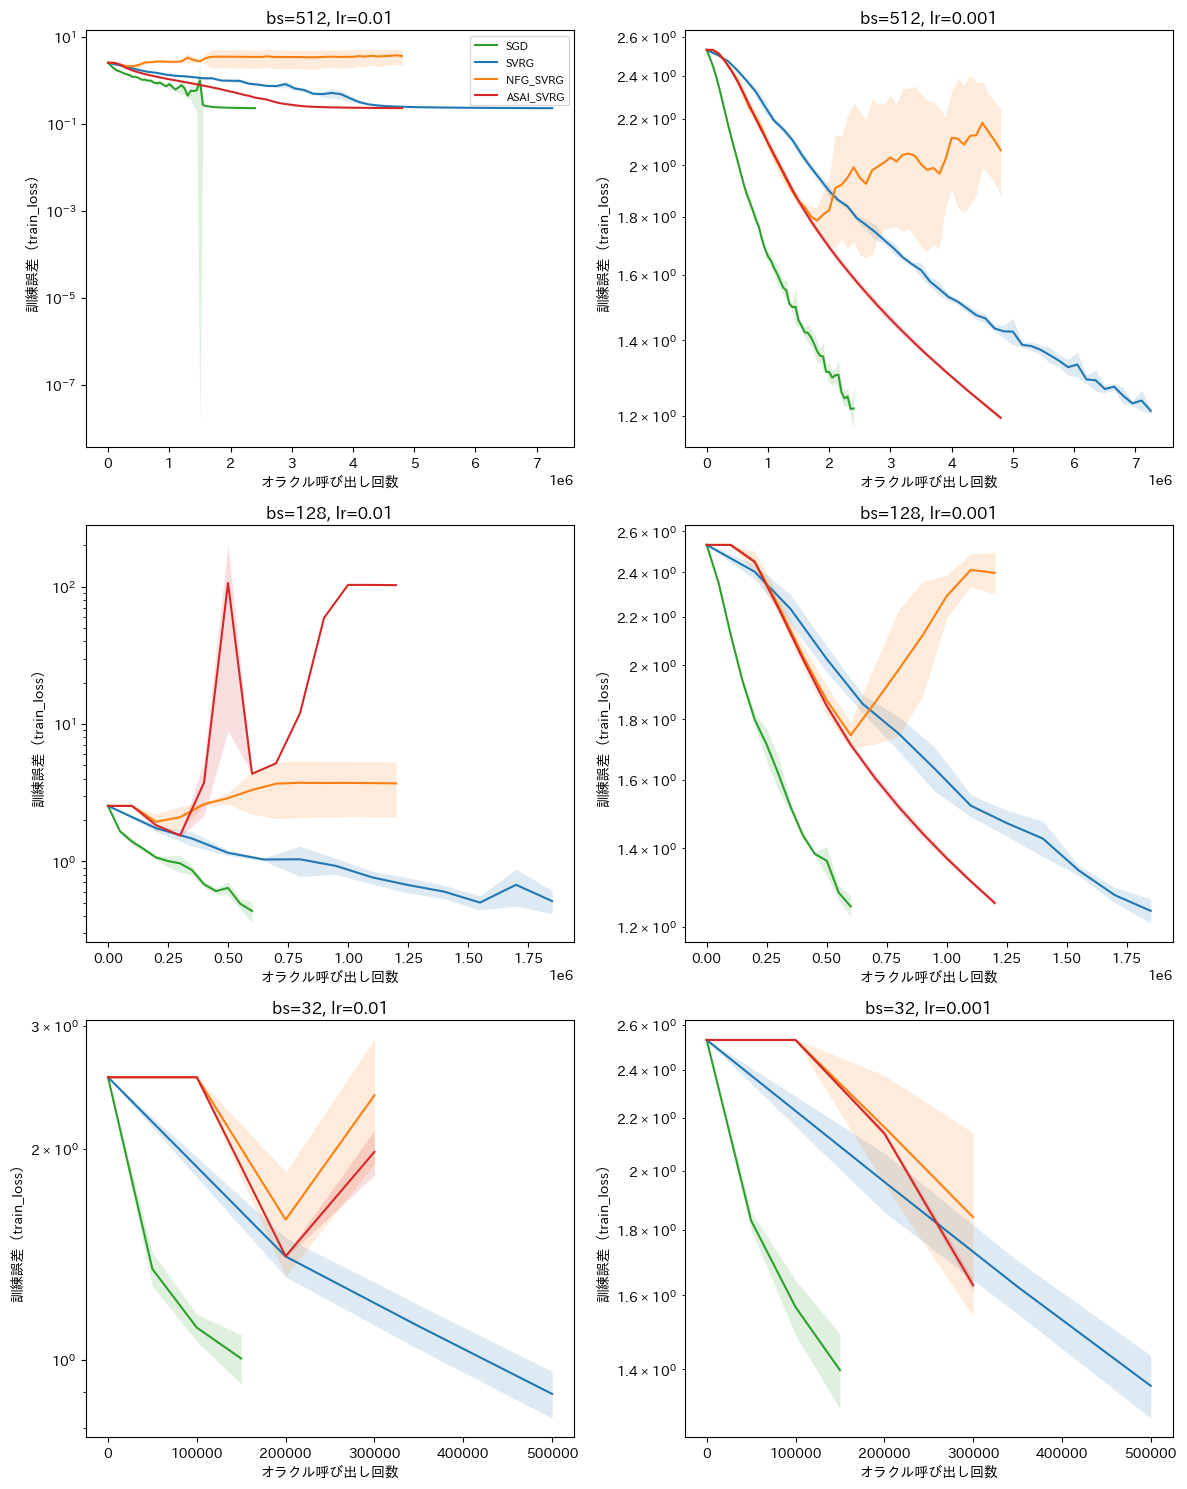

In [24]:
fig, axes = plt.subplots(len(EX0022_BATCH_SIZES), len(EX0022_LRS), figsize=(12, 15))
for i, bs in enumerate(EX0022_BATCH_SIZES):
    for j, lr in enumerate(EX0022_LRS):
        ax = axes[i][j]
        for method in EX0022_METHODS:
            loss_mean, loss_std, n = ex0022_load_all(method, bs, lr, "train_loss")
            oracle_mean, _, _ = ex0022_load_all(method, bs, lr, "oracle_calls")
            if n == 0:
                continue
            ax.plot(oracle_mean, loss_mean, label=method, color=METHOD_COLORS.get(method), linewidth=1.5)
            ax.fill_between(oracle_mean, np.clip(loss_mean - loss_std, 1e-8, None), loss_mean + loss_std,
                             color=METHOD_COLORS.get(method), alpha=0.15, linewidth=0)
        ax.set_yscale("log")
        ax.set_title(f"bs={bs}, lr={lr}")
        ax.set_xlabel("オラクル呼び出し回数")
        ax.set_ylabel("訓練誤差（train_loss）")
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(EX0022_FIGURE_DIR / "loss_grid_by_oracle_calls.png", dpi=130, bbox_inches="tight")
plt.show()


### 分類精度の推移（縦：バッチサイズ，横：学習率，横軸：実行時間 elapsed_time）

`elapsed_time` は，NFG SVRG・ASAI SVRGについては近似誤差算出のためだけの診断専用フル勾配
計算の時間を含まない（`programs/ex0022_cifar10_alexnet_groupnorm/train.py` モジュール
docstring参照）．コピーにより再利用した20条件（学習率0.001・バッチサイズ512, 128の
NFG SVRG・ASAI SVRG）の`elapsed_time`は，ex0021の値をそのまま流用しているためこの修正が
反映されていない点に注意する。

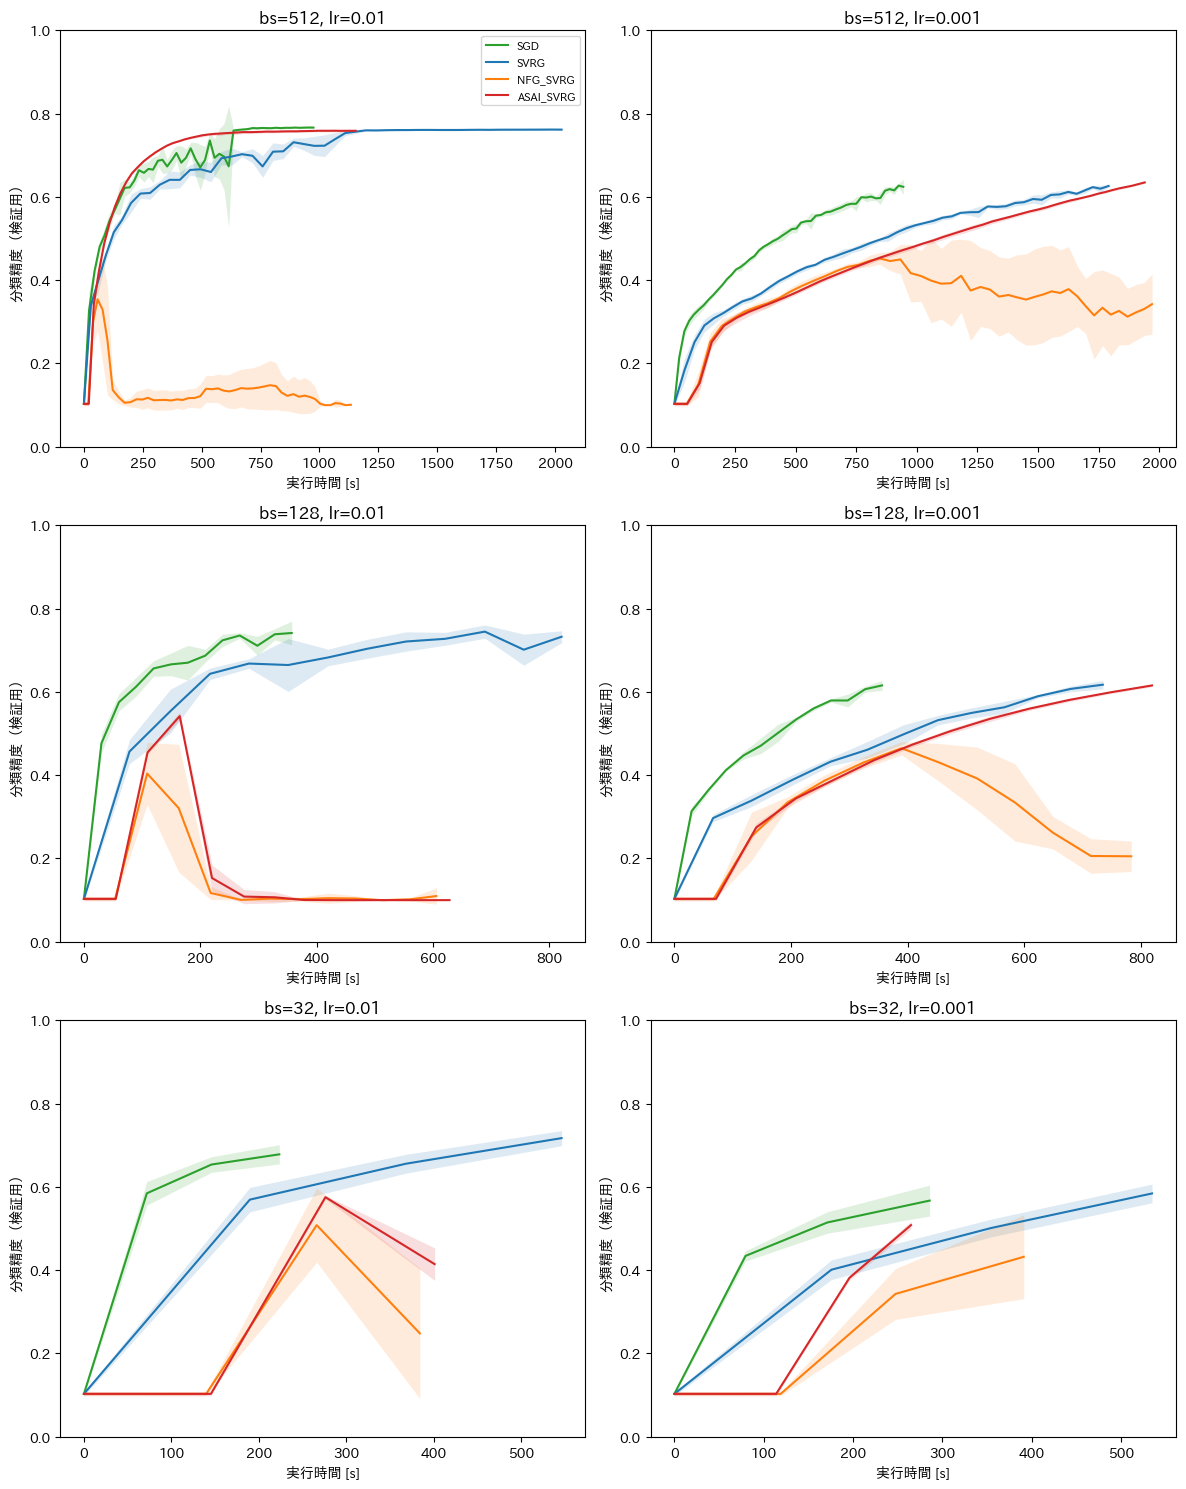

In [25]:
fig, axes = plt.subplots(len(EX0022_BATCH_SIZES), len(EX0022_LRS), figsize=(12, 15))
for i, bs in enumerate(EX0022_BATCH_SIZES):
    for j, lr in enumerate(EX0022_LRS):
        ax = axes[i][j]
        for method in EX0022_METHODS:
            acc_mean, acc_std, n = ex0022_load_all(method, bs, lr, "test_accuracy")
            time_mean, _, _ = ex0022_load_all(method, bs, lr, "elapsed_time")
            if n == 0:
                continue
            ax.plot(time_mean, acc_mean, label=method, color=METHOD_COLORS.get(method), linewidth=1.5)
            ax.fill_between(time_mean, acc_mean - acc_std, acc_mean + acc_std,
                             color=METHOD_COLORS.get(method), alpha=0.15, linewidth=0)
        ax.set_title(f"bs={bs}, lr={lr}")
        ax.set_xlabel("実行時間 [s]")
        ax.set_ylabel("分類精度（検証用）")
        ax.set_ylim(0, 1)
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(EX0022_FIGURE_DIR / "accuracy_grid_by_elapsed_time.png", dpi=130, bbox_inches="tight")
plt.show()


### フル勾配の近似誤差の推移（縦：バッチサイズ，横：学習率，横軸：実行時間 elapsed_time，SVRG・NFG SVRG・ASAI SVRGのみ）

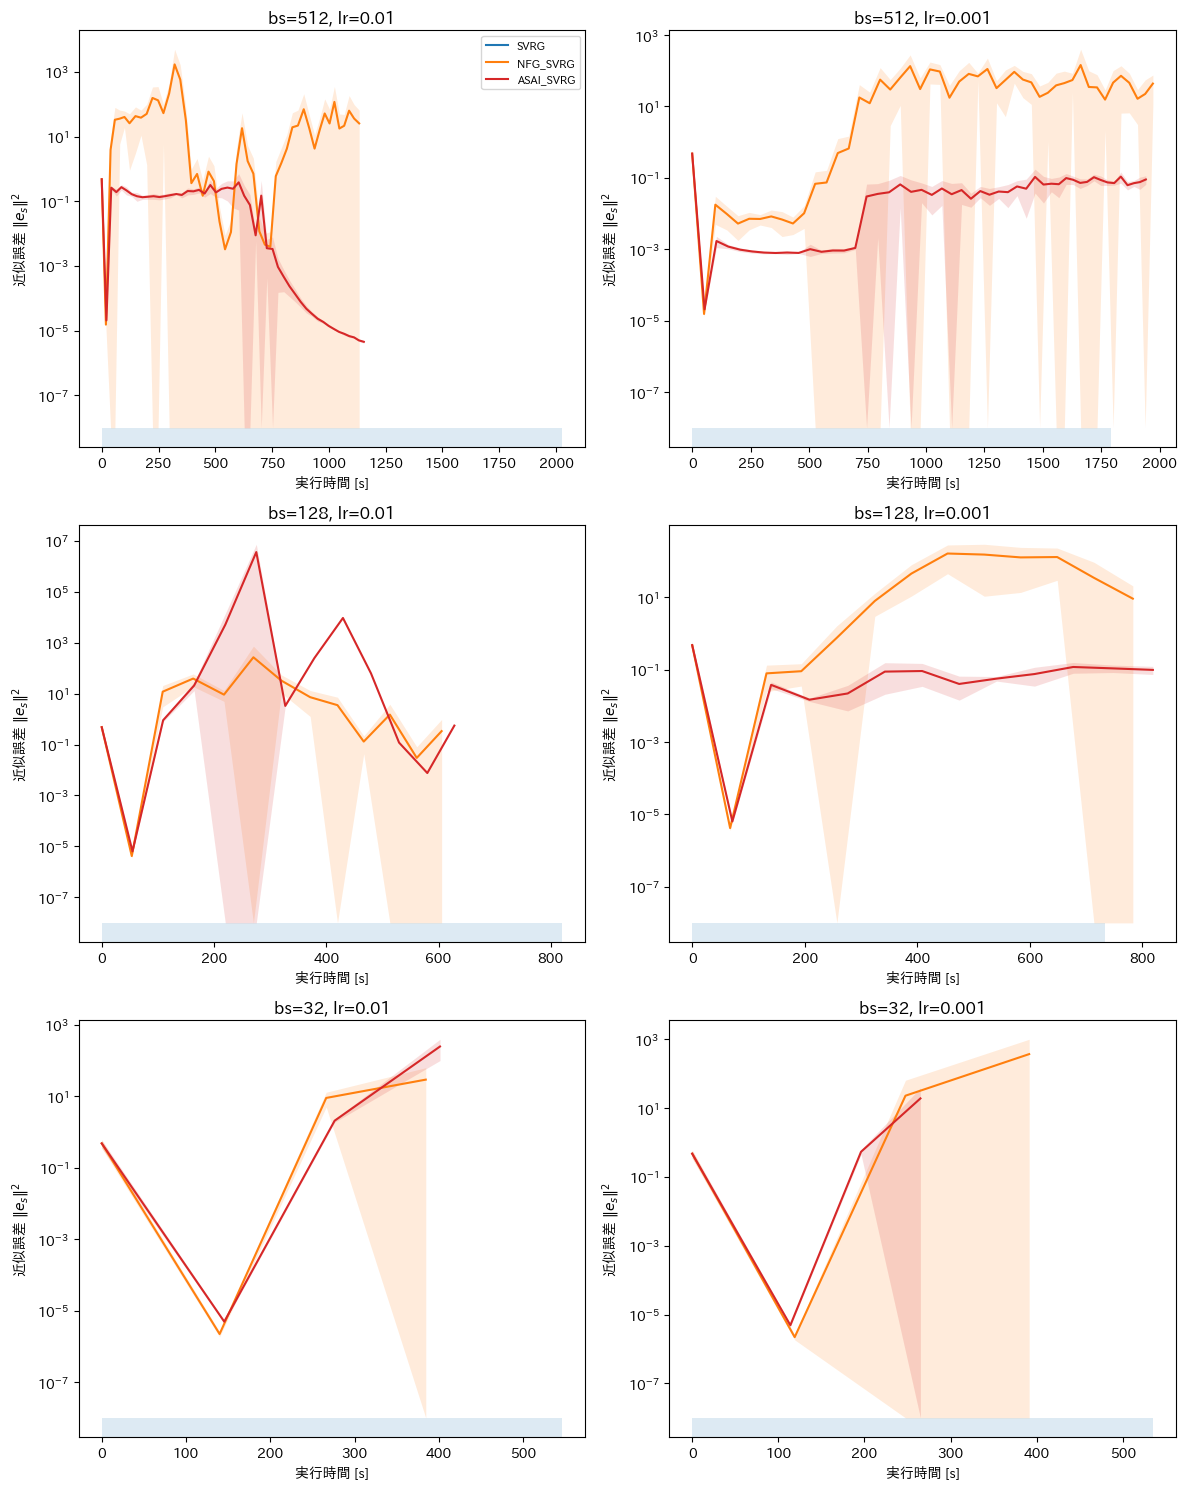

In [26]:
fig, axes = plt.subplots(len(EX0022_BATCH_SIZES), len(EX0022_LRS), figsize=(12, 15))
for i, bs in enumerate(EX0022_BATCH_SIZES):
    for j, lr in enumerate(EX0022_LRS):
        ax = axes[i][j]
        for method in ["SVRG", "NFG_SVRG", "ASAI_SVRG"]:
            err_mean, err_std, n = ex0022_load_all(method, bs, lr, "approx_error")
            time_mean, _, _ = ex0022_load_all(method, bs, lr, "elapsed_time")
            if n == 0:
                continue
            ax.plot(time_mean, err_mean, label=method, color=METHOD_COLORS.get(method), linewidth=1.5)
            ax.fill_between(time_mean, np.clip(err_mean - err_std, 1e-8, None), err_mean + err_std,
                             color=METHOD_COLORS.get(method), alpha=0.15, linewidth=0)
        ax.set_yscale("log")
        ax.set_title(f"bs={bs}, lr={lr}")
        ax.set_xlabel("実行時間 [s]")
        ax.set_ylabel(r"近似誤差 $\|e_s\|^2$")
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(EX0022_FIGURE_DIR / "approx_error_grid_by_elapsed_time.png", dpi=130, bbox_inches="tight")
plt.show()


### グリッド全体の要約表（最終・最高精度，発散Seed数）

In [27]:
def ex0022_summarize_grid() -> str:
    """概要: 実験ex0022の全条件（4手法 x 3バッチサイズ x 2学習率）について，最終・最高分類
        精度と発散（NaN）したSeed数をまとめたMarkdown表を作成する．"""
    lines = [
        "| バッチサイズ | 学習率 | 手法 | 最終精度 | 最高精度 | 発散(NaN)Seed数 |",
        "| ---: | ---: | :--- | ---: | ---: | ---: |",
    ]
    for bs in EX0022_BATCH_SIZES:
        for lr in EX0022_LRS:
            for method in EX0022_METHODS:
                entry = all_results.get((EX0022_EXPERIMENT, method, ex0022_hp_name(lr, bs)))
                if entry is None:
                    continue
                final_accs, max_accs, n_nan = [], [], 0
                for log in entry["seed_logs"]:
                    final_accs.append(log["test_accuracy"][-1])
                    max_accs.append(max(log["test_accuracy"]))
                    if any(not np.isfinite(v) for v in log["train_loss"]):
                        n_nan += 1
                n = len(entry["seed_logs"])
                lines.append(
                    f"| {bs} | {lr} | {method} | {np.mean(final_accs):.4f} | "
                    f"{np.mean(max_accs):.4f} | {n_nan}/{n} |"
                )
    return "\n".join(lines)


ex0022_table = ex0022_summarize_grid()
print(ex0022_table)
with open(EX0022_FIGURE_DIR / "grid_summary.md", "w") as f:
    f.write(ex0022_table + "\n")


| バッチサイズ | 学習率 | 手法 | 最終精度 | 最高精度 | 発散(NaN)Seed数 |
| ---: | ---: | :--- | ---: | ---: | ---: |
| 512 | 0.01 | SGD | 0.7665 | 0.7673 | 0/5 |
| 512 | 0.01 | SVRG | 0.7616 | 0.7619 | 0/5 |
| 512 | 0.01 | NFG_SVRG | 0.1008 | 0.4143 | 0/5 |
| 512 | 0.01 | ASAI_SVRG | 0.7588 | 0.7591 | 0/5 |
| 512 | 0.001 | SGD | 0.6242 | 0.6319 | 0/5 |
| 512 | 0.001 | SVRG | 0.6263 | 0.6286 | 0/5 |
| 512 | 0.001 | NFG_SVRG | 0.3425 | 0.4870 | 0/5 |
| 512 | 0.001 | ASAI_SVRG | 0.6348 | 0.6348 | 0/5 |
| 128 | 0.01 | SGD | 0.7414 | 0.7542 | 0/5 |
| 128 | 0.01 | SVRG | 0.7325 | 0.7486 | 0/5 |
| 128 | 0.01 | NFG_SVRG | 0.1098 | 0.4674 | 0/5 |
| 128 | 0.01 | ASAI_SVRG | 0.1000 | 0.5419 | 4/5 |
| 128 | 0.001 | SGD | 0.6156 | 0.6185 | 0/5 |
| 128 | 0.001 | SVRG | 0.6173 | 0.6173 | 0/5 |
| 128 | 0.001 | NFG_SVRG | 0.2053 | 0.4712 | 0/5 |
| 128 | 0.001 | ASAI_SVRG | 0.6155 | 0.6155 | 0/5 |
| 32 | 0.01 | SGD | 0.6782 | 0.6853 | 0/5 |
| 32 | 0.01 | SVRG | 0.7171 | 0.7171 | 0/5 |
| 32 | 0.01 | NFG_SVRG | 0.2482 | 0.5387

## 実験ex0023（GroupNorm・学習率0.001固定での長期エポック学習，誤差床の収束観察）専用の可視化

`.orders/order_026.md` に対応する．学習率0.001に固定し，バッチサイズ512, 128, 32についてex0022
（48, 12, 3エポック）の約4倍（192, 48, 12エポック）にエポック数を延長し，近似誤差・分類精度が
プラトーに達するかを観察する．

In [28]:
EX0023_EXPERIMENT = "ex0023_cifar10_alexnet_groupnorm_longrun"
EX0023_METHODS = ["SGD", "SVRG", "NFG_SVRG", "ASAI_SVRG"]
EX0023_BATCH_SIZES = [512, 128, 32]
EX0023_EPOCHS_BY_BS = {512: 192, 128: 48, 32: 12}
EX0023_REG_LAMBDA = 0.0005

EX0023_FIGURE_DIR = OUTPUTS_ROOT / EX0023_EXPERIMENT
EX0023_FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def ex0023_hp_name(bs: int) -> str:
    """概要: 実験ex0023のハイパーパラメータ条件名（ディレクトリ名）を構築する（学習率0.001固定）．"""
    return f"lr0.001_bs{bs}_normgroupnorm_lambda{EX0023_REG_LAMBDA}_epochs{EX0023_EPOCHS_BY_BS[bs]}"


def ex0023_load_all(method: str, bs: int, key: str):
    """概要: 実験ex0023の指定条件について，全Seedの指標を読み込み平均・標準偏差を計算する．"""
    entry = all_results.get((EX0023_EXPERIMENT, method, ex0023_hp_name(bs)))
    if entry is None:
        return np.array([]), np.array([]), 0
    values = np.array([log[key] for log in entry["seed_logs"]], dtype=np.float64)
    return np.nanmean(values, axis=0), np.nanstd(values, axis=0), values.shape[0]


### 分類精度の全学習過程（横：バッチサイズ，横軸：エポック数）

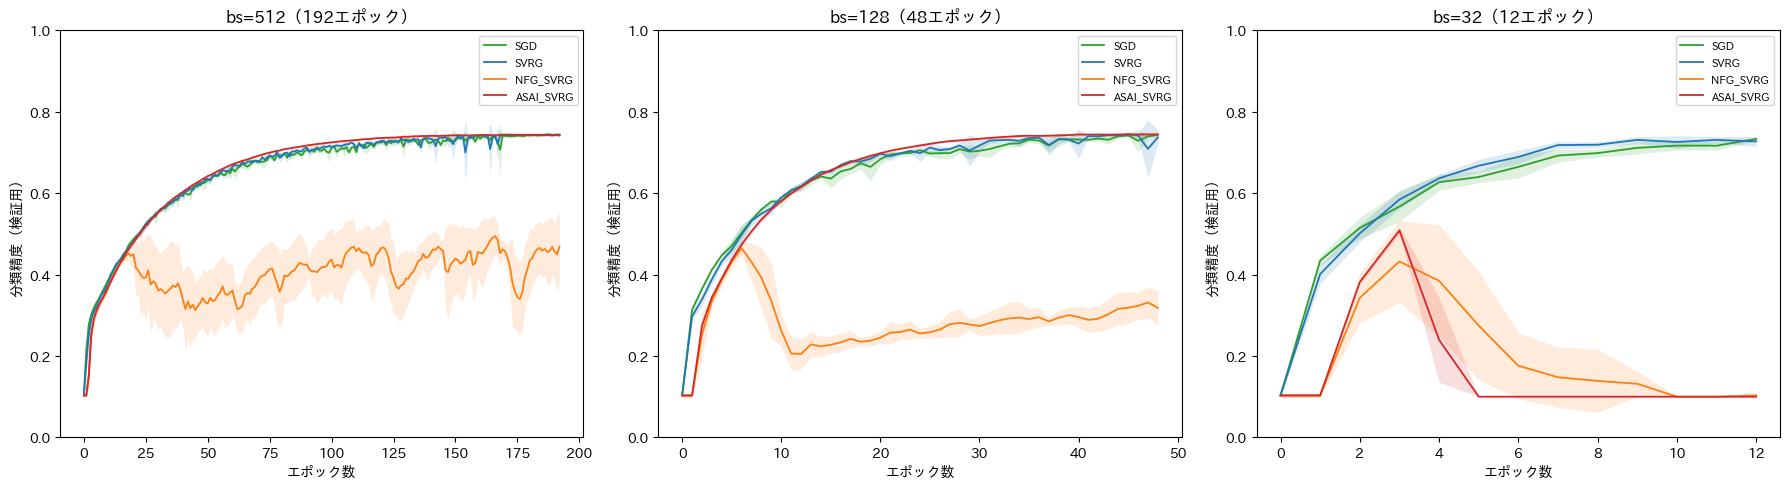

In [29]:
fig, axes = plt.subplots(1, len(EX0023_BATCH_SIZES), figsize=(18, 5))
for j, bs in enumerate(EX0023_BATCH_SIZES):
    ax = axes[j]
    for method in EX0023_METHODS:
        mean, std, n = ex0023_load_all(method, bs, "test_accuracy")
        if n == 0:
            continue
        x = np.arange(len(mean))
        ax.plot(x, mean, label=method, color=METHOD_COLORS.get(method), linewidth=1.3)
        ax.fill_between(x, mean - std, mean + std, color=METHOD_COLORS.get(method), alpha=0.15, linewidth=0)
    ax.set_title(f"bs={bs}（{EX0023_EPOCHS_BY_BS[bs]}エポック）")
    ax.set_xlabel("エポック数")
    ax.set_ylabel("分類精度（検証用）")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(EX0023_FIGURE_DIR / "accuracy_full_trajectory.png", dpi=130, bbox_inches="tight")
plt.show()


### フル勾配の近似誤差の全学習過程（横：バッチサイズ，横軸：エポック数，SVRG・NFG SVRG・ASAI SVRGのみ）

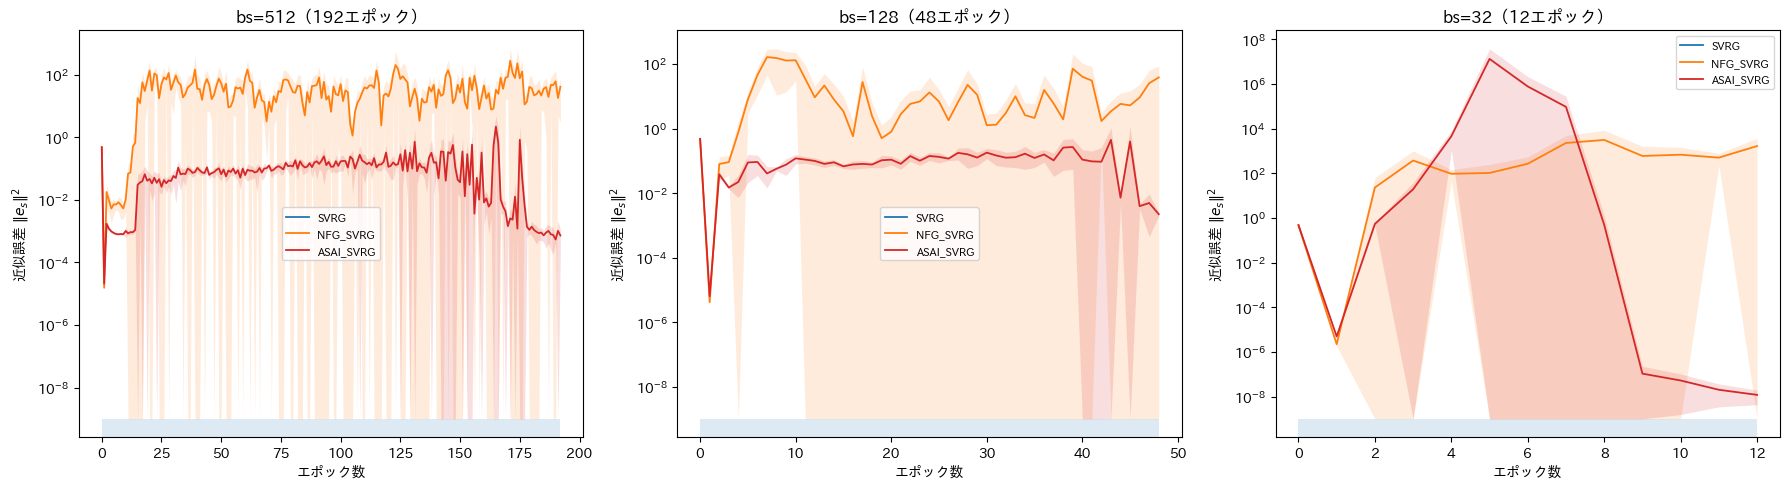

In [30]:
fig, axes = plt.subplots(1, len(EX0023_BATCH_SIZES), figsize=(18, 5))
for j, bs in enumerate(EX0023_BATCH_SIZES):
    ax = axes[j]
    for method in ["SVRG", "NFG_SVRG", "ASAI_SVRG"]:
        mean, std, n = ex0023_load_all(method, bs, "approx_error")
        if n == 0:
            continue
        x = np.arange(len(mean))
        ax.plot(x, mean, label=method, color=METHOD_COLORS.get(method), linewidth=1.3)
        ax.fill_between(x, np.clip(mean - std, 1e-9, None), mean + std,
                         color=METHOD_COLORS.get(method), alpha=0.15, linewidth=0)
    ax.set_yscale("log")
    ax.set_title(f"bs={bs}（{EX0023_EPOCHS_BY_BS[bs]}エポック）")
    ax.set_xlabel("エポック数")
    ax.set_ylabel(r"近似誤差 $\|e_s\|^2$")
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(EX0023_FIGURE_DIR / "approx_error_full_trajectory.png", dpi=130, bbox_inches="tight")
plt.show()


### 要約表（最終・最高精度，発散Seed数，末尾5エポックの相対変化最大値によるプラトー判定）

In [31]:
import sys as _sys
_sys.path.insert(0, str(Path("programs/ex0023_cifar10_alexnet_groupnorm_longrun")))
_sys.path.insert(0, str(Path("programs")))
import importlib
_ex0023_train_spec = importlib.util.spec_from_file_location(
    "ex0023_train_viz", "programs/ex0023_cifar10_alexnet_groupnorm_longrun/train.py"
)
_ex0023_train_viz = importlib.util.module_from_spec(_ex0023_train_spec)
_ex0023_train_spec.loader.exec_module(_ex0023_train_viz)


def ex0023_summarize_grid() -> str:
    """概要: 実験ex0023の全条件について，最終・最高分類精度，発散Seed数，プラトー判定
        （末尾5エポックの近似誤差相対変化の最大値）をまとめたMarkdown表を作成する．"""
    lines = [
        "| バッチサイズ | 手法 | 最終精度 | 最高精度 | 発散(NaN)Seed数 | 近似誤差の末尾相対変化 |",
        "| ---: | :--- | ---: | ---: | ---: | ---: |",
    ]
    for bs in EX0023_BATCH_SIZES:
        hp = ex0023_hp_name(bs)
        for method in EX0023_METHODS:
            entry = all_results.get((EX0023_EXPERIMENT, method, hp))
            if entry is None:
                continue
            final_accs, max_accs, n_nan = [], [], 0
            for log in entry["seed_logs"]:
                final_accs.append(log["test_accuracy"][-1])
                max_accs.append(max(log["test_accuracy"]))
                if any(not np.isfinite(v) for v in log["train_loss"]):
                    n_nan += 1
            n = len(entry["seed_logs"])
            err_mean, _, _ = ex0023_load_all(method, bs, "approx_error")
            if method in ("NFG_SVRG", "ASAI_SVRG") and len(err_mean) > 5:
                rel_change = _ex0023_train_viz.compute_trailing_relative_change(err_mean, window=5)
                rel_change_str = f"{rel_change:.2e}"
            else:
                rel_change_str = "-"
            lines.append(
                f"| {bs} | {method} | {np.mean(final_accs):.4f} | "
                f"{np.mean(max_accs):.4f} | {n_nan}/{n} | {rel_change_str} |"
            )
    return "\n".join(lines)


ex0023_table = ex0023_summarize_grid()
print(ex0023_table)
with open(EX0023_FIGURE_DIR / "grid_summary.md", "w") as f:
    f.write(ex0023_table + "\n")


| バッチサイズ | 手法 | 最終精度 | 最高精度 | 発散(NaN)Seed数 | 近似誤差の末尾相対変化 |
| ---: | :--- | ---: | ---: | ---: | ---: |
| 512 | SGD | 0.7417 | 0.7461 | 0/5 | - |
| 512 | SVRG | 0.7437 | 0.7444 | 0/5 | - |
| 512 | NFG_SVRG | 0.4688 | 0.5514 | 0/5 | 1.42e+00 |
| 512 | ASAI_SVRG | 0.7432 | 0.7445 | 0/5 | 8.89e-01 |
| 128 | SGD | 0.7436 | 0.7468 | 0/5 | - |
| 128 | SVRG | 0.7370 | 0.7458 | 0/5 | - |
| 128 | NFG_SVRG | 0.3182 | 0.4712 | 0/5 | 1.77e+00 |
| 128 | ASAI_SVRG | 0.7443 | 0.7452 | 0/5 | 5.42e+01 |
| 32 | SGD | 0.7330 | 0.7353 | 0/5 | - |
| 32 | SVRG | 0.7270 | 0.7355 | 0/5 | - |
| 32 | NFG_SVRG | 0.1032 | 0.4774 | 0/5 | 2.30e+00 |
| 32 | ASAI_SVRG | 0.1000 | 0.5084 | 0/5 | 1.00e+00 |


/tmp/ipykernel_2214256/3643324999.py:22: RuntimeWarning: Mean of empty slice
  return np.nanmean(values, axis=0), np.nanstd(values, axis=0), values.shape[0]
/home/user/workspace/ASAI_SVRG_programs/.venv_pytorch_gpu/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


## 実験3（Tiny Shakespeare・Transformer）Stage A（安定性探索）・Stage B（4手法比較）専用の可視化

`.orders/order_027.md`（Stage A）・`.orders/order_028.md`（Stage B）に対応する．Stage Bでは，Stage Aと同一のモデル・データセット・グリッドに，SGD・SVRGを比較対象として追加する．

In [32]:
EX003_EXPERIMENT = "ex003_tinyshakespeare_transformer"
EX003_METHODS = ["SGD", "SVRG", "NFG_SVRG", "ASAI_SVRG"]  # Stage B（order_028）
EX003_BATCH_SIZES = [512, 128, 32]
EX003_LRS = [0.01, 0.001]
EX003_REG_LAMBDA = 0.0005
EX003_EPOCHS = 12
EX003_VOCAB_SIZE = 65

EX003_FIGURE_DIR = OUTPUTS_ROOT / EX003_EXPERIMENT
EX003_FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def ex003_hp_name(lr: float, bs: int) -> str:
    """概要: 実験3 Stage Aのハイパーパラメータ条件名（ディレクトリ名）を構築する．"""
    return f"lr{lr}_bs{bs}_lambda{EX003_REG_LAMBDA}_epochs{EX003_EPOCHS}"


def ex003_load_all(method: str, bs: int, lr: float, key: str):
    """概要: 実験3の指定条件について，全Seedの指標を読み込み平均・標準偏差を計算する．"""
    entry = all_results.get((EX003_EXPERIMENT, method, ex003_hp_name(lr, bs)))
    if entry is None:
        return np.array([]), np.array([]), 0
    values = np.array([log[key] for log in entry["seed_logs"]], dtype=np.float64)
    return np.nanmean(values, axis=0), np.nanstd(values, axis=0), values.shape[0]


### 次文字予測精度のグリッド（縦：バッチサイズ，横：学習率，横軸：エポック数）

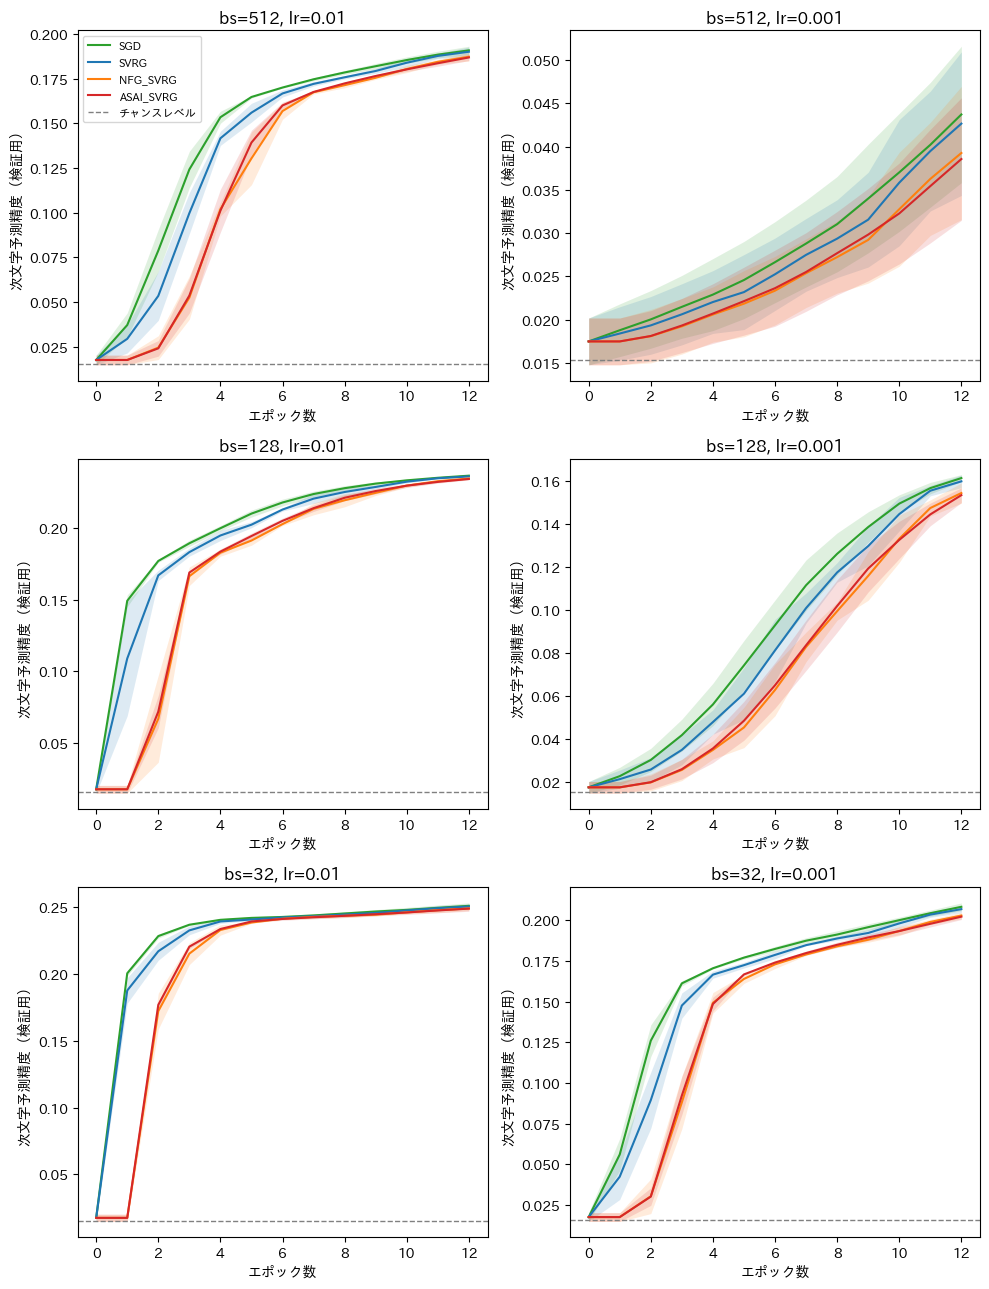

In [33]:
EX003_CHANCE = 1 / EX003_VOCAB_SIZE
fig, axes = plt.subplots(len(EX003_BATCH_SIZES), len(EX003_LRS), figsize=(10, 13))
for i, bs in enumerate(EX003_BATCH_SIZES):
    for j, lr in enumerate(EX003_LRS):
        ax = axes[i][j]
        for method in EX003_METHODS:
            mean, std, n = ex003_load_all(method, bs, lr, "test_accuracy")
            if n == 0:
                continue
            x = np.arange(len(mean))
            ax.plot(x, mean, label=method, color=METHOD_COLORS.get(method), linewidth=1.5)
            ax.fill_between(x, mean - std, mean + std, color=METHOD_COLORS.get(method), alpha=0.15, linewidth=0)
        ax.axhline(EX003_CHANCE, color="gray", linestyle="--", linewidth=1, label="チャンスレベル")
        ax.set_title(f"bs={bs}, lr={lr}")
        ax.set_xlabel("エポック数")
        ax.set_ylabel("次文字予測精度（検証用）")
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(EX003_FIGURE_DIR / "accuracy_grid.png", dpi=130, bbox_inches="tight")
plt.show()


### オラクル呼び出し回数を横軸とした次文字予測精度の比較（縦：バッチサイズ，横：学習率）

`.orders/order_028.md` 4節2項・4項が要求する，本実験（Stage B）の中心的な図である．
オラクル呼び出し回数（`oracle_calls`，1エポックあたりSGDは$N$，NFG SVRG・ASAI SVRGは$2N$，
SVRGは$3N$）を横軸とすることで，手法間の計算コストの違いを揃えた公平な効率性比較となる．

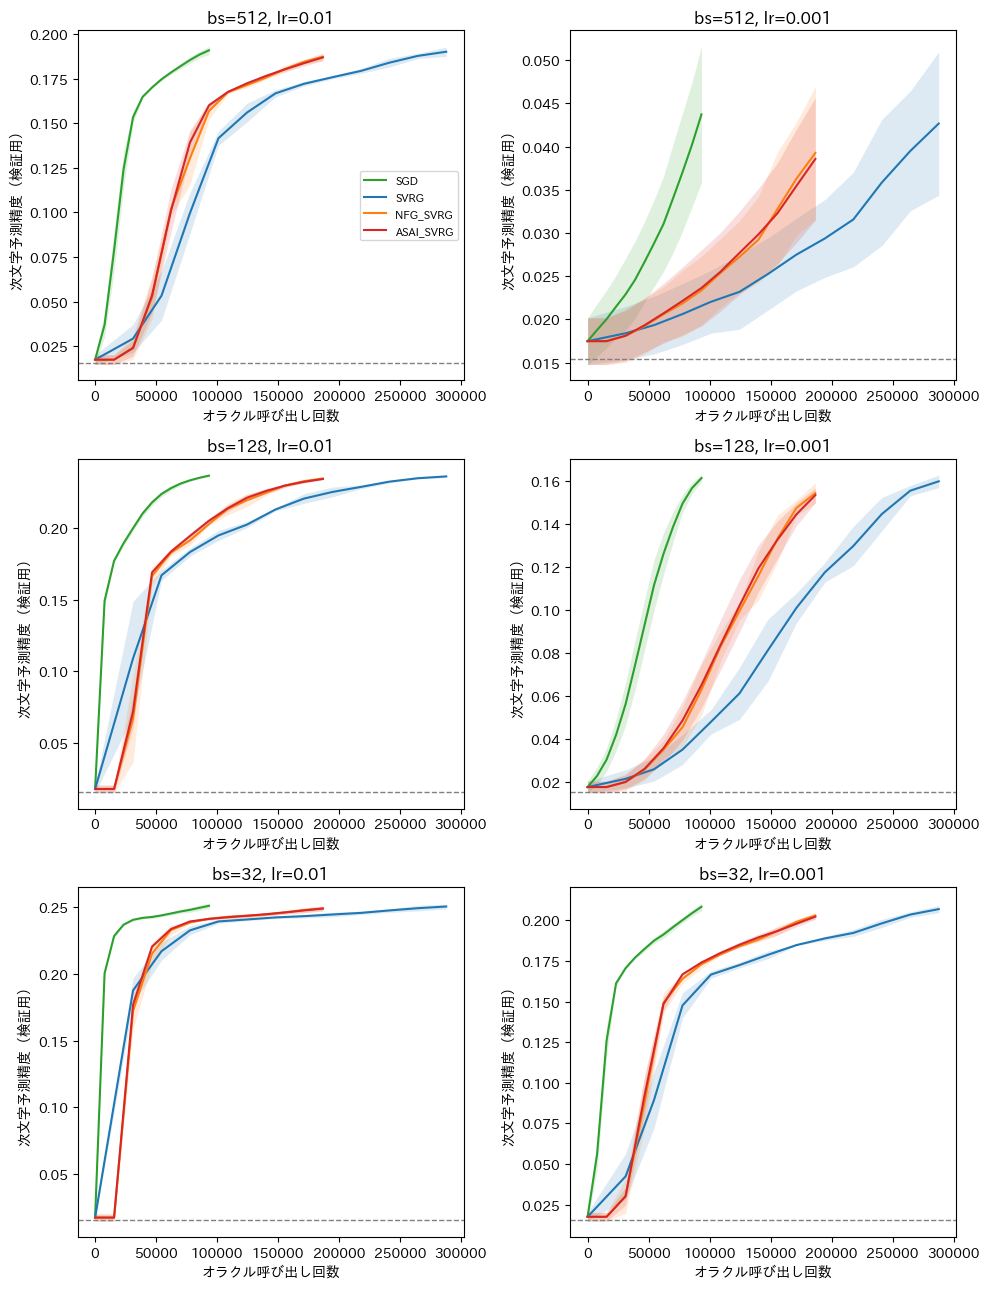

In [34]:
fig, axes = plt.subplots(len(EX003_BATCH_SIZES), len(EX003_LRS), figsize=(10, 13))
for i, bs in enumerate(EX003_BATCH_SIZES):
    for j, lr in enumerate(EX003_LRS):
        ax = axes[i][j]
        for method in EX003_METHODS:
            acc_mean, acc_std, n = ex003_load_all(method, bs, lr, "test_accuracy")
            oracle_mean, _, _ = ex003_load_all(method, bs, lr, "oracle_calls")
            if n == 0:
                continue
            ax.plot(oracle_mean, acc_mean, label=method, color=METHOD_COLORS.get(method), linewidth=1.5)
            ax.fill_between(oracle_mean, acc_mean - acc_std, acc_mean + acc_std,
                             color=METHOD_COLORS.get(method), alpha=0.15, linewidth=0)
        ax.axhline(EX003_CHANCE, color="gray", linestyle="--", linewidth=1)
        ax.set_title(f"bs={bs}, lr={lr}")
        ax.set_xlabel("オラクル呼び出し回数")
        ax.set_ylabel("次文字予測精度（検証用）")
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(EX003_FIGURE_DIR / "accuracy_grid_by_oracle_calls.png", dpi=130, bbox_inches="tight")
plt.show()


### フル勾配の近似誤差のグリッド（縦：バッチサイズ，横：学習率，横軸：エポック数）

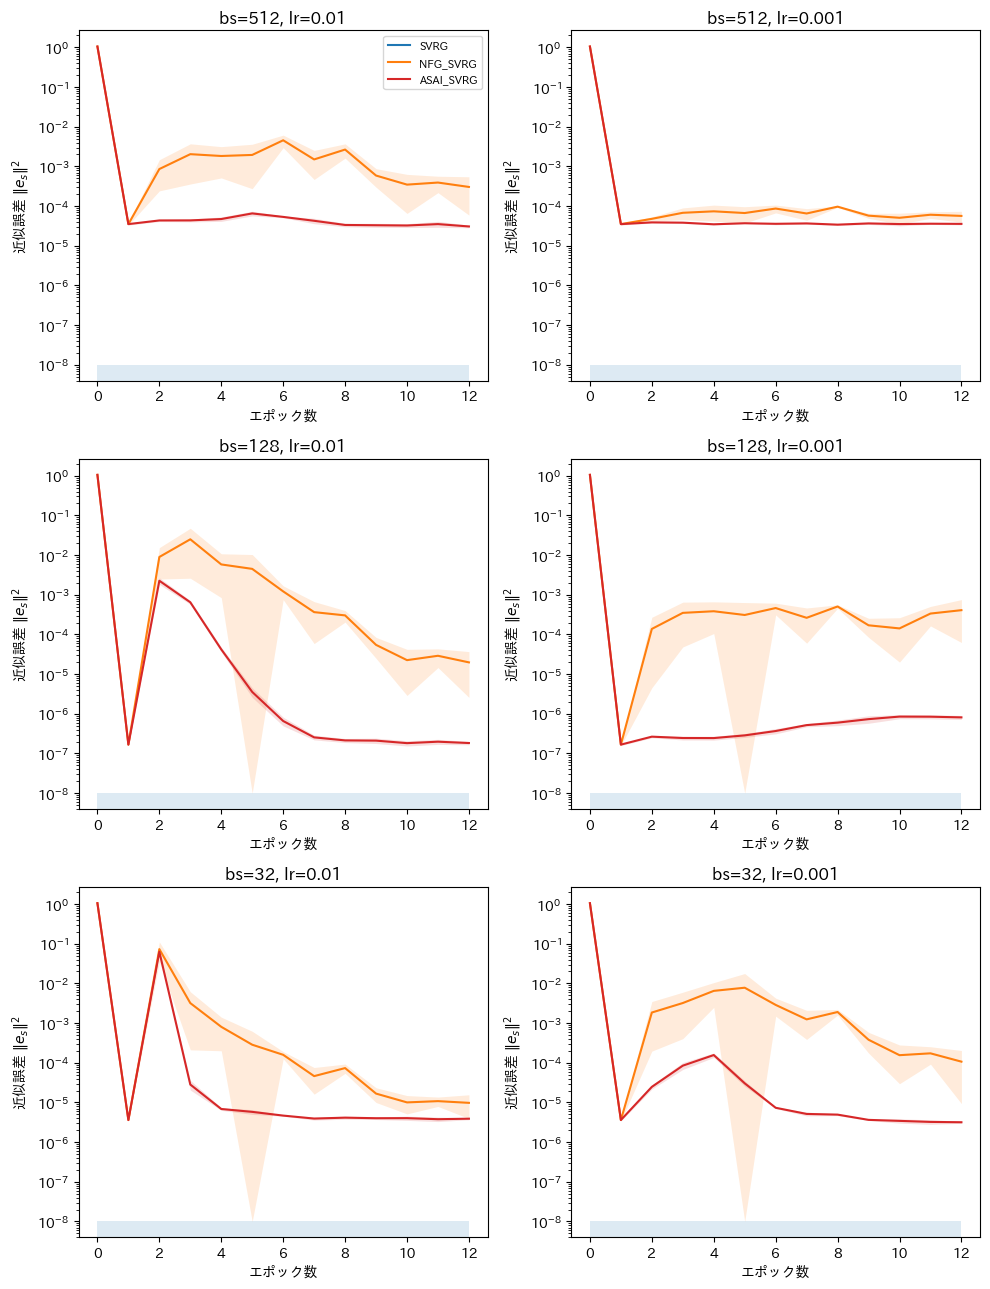

In [35]:
fig, axes = plt.subplots(len(EX003_BATCH_SIZES), len(EX003_LRS), figsize=(10, 13))
for i, bs in enumerate(EX003_BATCH_SIZES):
    for j, lr in enumerate(EX003_LRS):
        ax = axes[i][j]
        for method in ["SVRG", "NFG_SVRG", "ASAI_SVRG"]:
            mean, std, n = ex003_load_all(method, bs, lr, "approx_error")
            if n == 0:
                continue
            x = np.arange(len(mean))
            ax.plot(x, mean, label=method, color=METHOD_COLORS.get(method), linewidth=1.5)
            ax.fill_between(x, np.clip(mean - std, 1e-8, None), mean + std,
                             color=METHOD_COLORS.get(method), alpha=0.15, linewidth=0)
        ax.set_yscale("log")
        ax.set_title(f"bs={bs}, lr={lr}")
        ax.set_xlabel("エポック数")
        ax.set_ylabel(r"近似誤差 $\|e_s\|^2$")
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(EX003_FIGURE_DIR / "approx_error_grid.png", dpi=130, bbox_inches="tight")
plt.show()


### グリッド全体の要約表（最終精度，発散・チャンスレベル張り付きSeed数）

In [36]:
import importlib.util as _importlib_util
import sys as _sys
for _stale in ("model", "data", "train"):
    _sys.modules.pop(_stale, None)
_ex003_train_spec = _importlib_util.spec_from_file_location(
    "ex003_train_viz", "programs/ex003_tinyshakespeare_transformer/train.py"
)
_ex003_train_viz = _importlib_util.module_from_spec(_ex003_train_spec)
_ex003_train_spec.loader.exec_module(_ex003_train_viz)


def ex003_summarize_grid() -> str:
    """概要: 実験3 Stage Aの全条件について，最終精度，発散・チャンスレベル張り付きSeed数を
        まとめたMarkdown表を作成する．"""
    lines = [
        "| バッチサイズ | 学習率 | 手法 | 最終精度 | 発散(NaN)Seed数 | チャンス張付きSeed数 |",
        "| ---: | ---: | :--- | ---: | ---: | ---: |",
    ]
    for bs in EX003_BATCH_SIZES:
        for lr in EX003_LRS:
            for method in EX003_METHODS:
                entry = all_results.get((EX003_EXPERIMENT, method, ex003_hp_name(lr, bs)))
                if entry is None:
                    continue
                final_accs, n_nan, n_stuck = [], 0, 0
                for log in entry["seed_logs"]:
                    final_accs.append(log["test_accuracy"][-1])
                    if any(not np.isfinite(v) for v in log["train_loss"]):
                        n_nan += 1
                    if _ex003_train_viz.is_stuck_near_chance(log["test_accuracy"], EX003_VOCAB_SIZE):
                        n_stuck += 1
                n = len(entry["seed_logs"])
                lines.append(
                    f"| {bs} | {lr} | {method} | {np.mean(final_accs):.4f} | {n_nan}/{n} | {n_stuck}/{n} |"
                )
    return "\n".join(lines)


ex003_table = ex003_summarize_grid()
print(ex003_table)
with open(EX003_FIGURE_DIR / "grid_summary.md", "w") as f:
    f.write(ex003_table + "\n")


| バッチサイズ | 学習率 | 手法 | 最終精度 | 発散(NaN)Seed数 | チャンス張付きSeed数 |
| ---: | ---: | :--- | ---: | ---: | ---: |
| 512 | 0.01 | SGD | 0.1909 | 0/3 | 0/3 |
| 512 | 0.01 | SVRG | 0.1901 | 0/3 | 0/3 |
| 512 | 0.01 | NFG_SVRG | 0.1873 | 0/3 | 0/3 |
| 512 | 0.01 | ASAI_SVRG | 0.1869 | 0/3 | 0/3 |
| 512 | 0.001 | SGD | 0.0437 | 0/3 | 1/3 |
| 512 | 0.001 | SVRG | 0.0427 | 0/3 | 1/3 |
| 512 | 0.001 | NFG_SVRG | 0.0393 | 0/3 | 1/3 |
| 512 | 0.001 | ASAI_SVRG | 0.0386 | 0/3 | 1/3 |
| 128 | 0.01 | SGD | 0.2369 | 0/3 | 0/3 |
| 128 | 0.01 | SVRG | 0.2364 | 0/3 | 0/3 |
| 128 | 0.01 | NFG_SVRG | 0.2349 | 0/3 | 0/3 |
| 128 | 0.01 | ASAI_SVRG | 0.2346 | 0/3 | 0/3 |
| 128 | 0.001 | SGD | 0.1613 | 0/3 | 0/3 |
| 128 | 0.001 | SVRG | 0.1597 | 0/3 | 0/3 |
| 128 | 0.001 | NFG_SVRG | 0.1543 | 0/3 | 0/3 |
| 128 | 0.001 | ASAI_SVRG | 0.1533 | 0/3 | 0/3 |
| 32 | 0.01 | SGD | 0.2508 | 0/3 | 0/3 |
| 32 | 0.01 | SVRG | 0.2503 | 0/3 | 0/3 |
| 32 | 0.01 | NFG_SVRG | 0.2489 | 0/3 | 0/3 |
| 32 | 0.01 | ASAI_SVRG | 0.2488 | 0/3 |

## 実験3（Tiny Shakespeare・Transformer）Stage C（長期学習）専用の可視化

`.orders/order_029.md` に対応する．学習率0.01のみに固定し，全バッチサイズ一律48エポック（Stage Bの4倍）まで学習を延長した結果を可視化する．中心的な検証項目である，ASAI SVRGのSVRGに対する効率性優位性がオラクル呼び出し回数ベースの比較で学習の進行とともにどう推移するかを示すグラフを含む．


In [37]:
EX0031_EXPERIMENT = "ex0031_tinyshakespeare_transformer_longrun"
EX0031_METHODS = ["SGD", "SVRG", "NFG_SVRG", "ASAI_SVRG"]
EX0031_BATCH_SIZES = [512, 128, 32]
EX0031_LR = 0.01
EX0031_REG_LAMBDA = 0.0005
EX0031_EPOCHS = 48
EX0031_VOCAB_SIZE = 65
EX0031_N_TRAIN = 7781

EX0031_FIGURE_DIR = OUTPUTS_ROOT / EX0031_EXPERIMENT
EX0031_FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def ex0031_hp_name(bs: int) -> str:
    """概要: 実験3 Stage Cのハイパーパラメータ条件名（ディレクトリ名）を構築する．"""
    return f"lr{EX0031_LR}_bs{bs}_lambda{EX0031_REG_LAMBDA}_epochs{EX0031_EPOCHS}"


def ex0031_load_all(method: str, bs: int, key: str):
    """概要: 実験3 Stage Cの指定条件について，全Seedの指標を読み込み平均・標準偏差を計算する．"""
    entry = all_results.get((EX0031_EXPERIMENT, method, ex0031_hp_name(bs)))
    if entry is None:
        return np.array([]), np.array([]), 0
    values = np.array([log[key] for log in entry["seed_logs"]], dtype=np.float64)
    return np.nanmean(values, axis=0), np.nanstd(values, axis=0), values.shape[0]


### 次文字予測精度（縦軸）とエポック数（横軸，1〜48エポック）


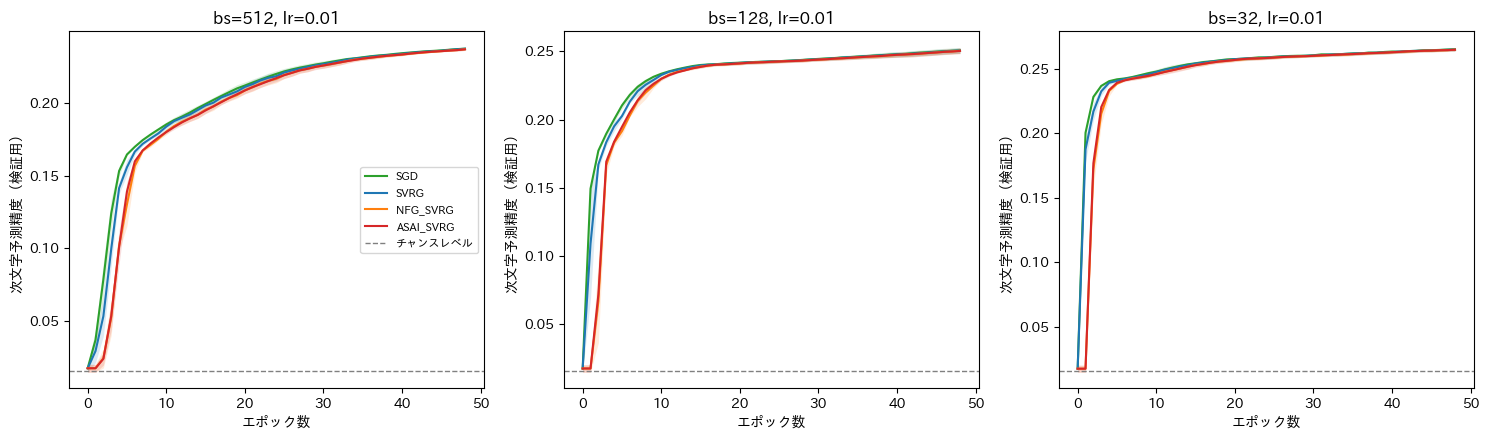

In [38]:
EX0031_CHANCE = 1 / EX0031_VOCAB_SIZE
fig, axes = plt.subplots(1, len(EX0031_BATCH_SIZES), figsize=(15, 4.5))
for j, bs in enumerate(EX0031_BATCH_SIZES):
    ax = axes[j]
    for method in EX0031_METHODS:
        mean, std, n = ex0031_load_all(method, bs, "test_accuracy")
        if n == 0:
            continue
        x = np.arange(len(mean))
        ax.plot(x, mean, label=method, color=METHOD_COLORS.get(method), linewidth=1.5)
        ax.fill_between(x, mean - std, mean + std, color=METHOD_COLORS.get(method), alpha=0.15, linewidth=0)
    ax.axhline(EX0031_CHANCE, color="gray", linestyle="--", linewidth=1, label="チャンスレベル")
    ax.set_title(f"bs={bs}, lr={EX0031_LR}")
    ax.set_xlabel("エポック数")
    ax.set_ylabel("次文字予測精度（検証用）")
    if j == 0:
        ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(EX0031_FIGURE_DIR / "accuracy_grid.png", dpi=130, bbox_inches="tight")
plt.show()


### オラクル呼び出し回数（横軸）を揃えた次文字予測精度の比較


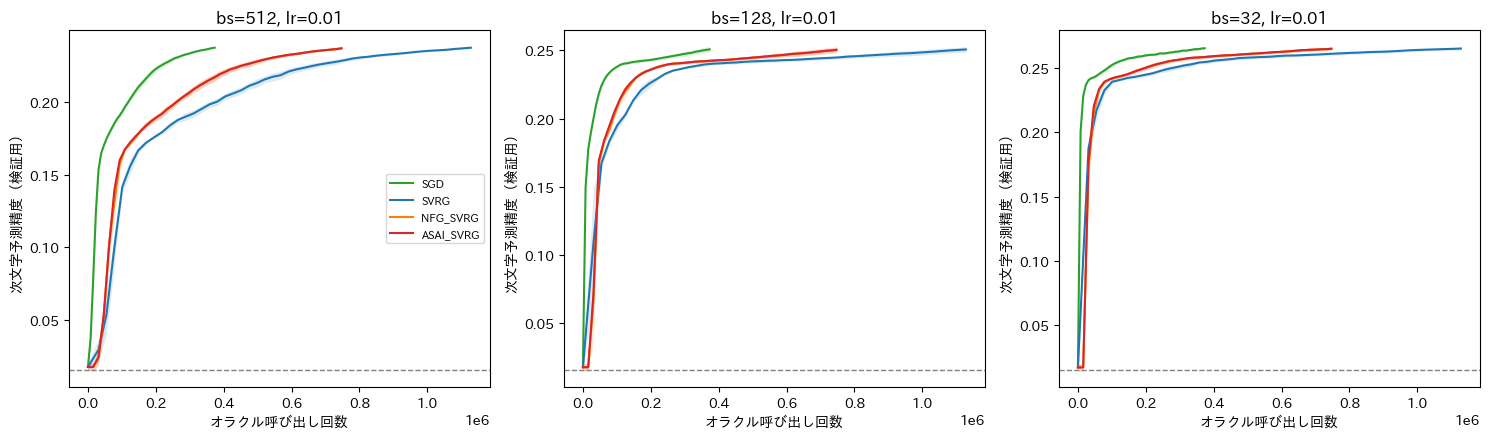

In [39]:
fig, axes = plt.subplots(1, len(EX0031_BATCH_SIZES), figsize=(15, 4.5))
for j, bs in enumerate(EX0031_BATCH_SIZES):
    ax = axes[j]
    for method in EX0031_METHODS:
        acc_mean, acc_std, n = ex0031_load_all(method, bs, "test_accuracy")
        oracle_mean, _, _ = ex0031_load_all(method, bs, "oracle_calls")
        if n == 0:
            continue
        ax.plot(oracle_mean, acc_mean, label=method, color=METHOD_COLORS.get(method), linewidth=1.5)
        ax.fill_between(oracle_mean, acc_mean - acc_std, acc_mean + acc_std,
                         color=METHOD_COLORS.get(method), alpha=0.15, linewidth=0)
    ax.axhline(EX0031_CHANCE, color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"bs={bs}, lr={EX0031_LR}")
    ax.set_xlabel("オラクル呼び出し回数")
    ax.set_ylabel("次文字予測精度（検証用）")
    if j == 0:
        ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(EX0031_FIGURE_DIR / "accuracy_grid_by_oracle_calls.png", dpi=130, bbox_inches="tight")
plt.show()


### フル勾配の近似誤差（縦軸，対数スケール）とエポック数（横軸）


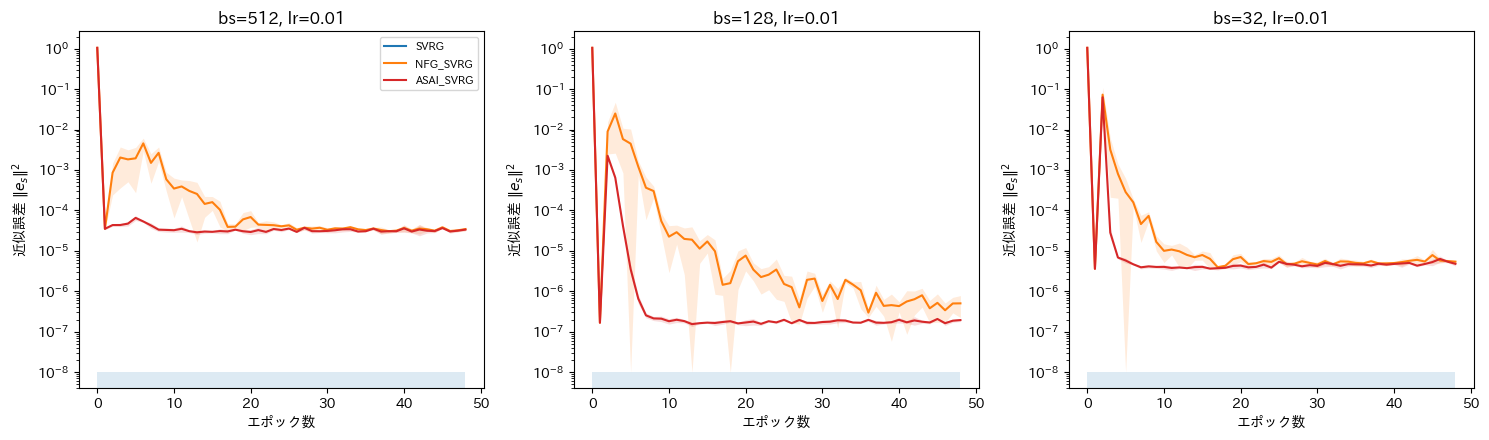

In [40]:
fig, axes = plt.subplots(1, len(EX0031_BATCH_SIZES), figsize=(15, 4.5))
for j, bs in enumerate(EX0031_BATCH_SIZES):
    ax = axes[j]
    for method in ["SVRG", "NFG_SVRG", "ASAI_SVRG"]:
        mean, std, n = ex0031_load_all(method, bs, "approx_error")
        if n == 0:
            continue
        x = np.arange(len(mean))
        ax.plot(x, mean, label=method, color=METHOD_COLORS.get(method), linewidth=1.5)
        ax.fill_between(x, np.clip(mean - std, 1e-8, None), mean + std,
                         color=METHOD_COLORS.get(method), alpha=0.15, linewidth=0)
    ax.set_yscale("log")
    ax.set_title(f"bs={bs}, lr={EX0031_LR}")
    ax.set_xlabel("エポック数")
    ax.set_ylabel(r"近似誤差 $\|e_s\|^2$")
    if j == 0:
        ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(EX0031_FIGURE_DIR / "approx_error_grid.png", dpi=130, bbox_inches="tight")
plt.show()


### ASAI SVRGのSVRGに対する効率性優位性の推移（本実験の中心的な図）

`.orders/order_029.md` 4節1項が求める，オラクル呼び出し回数を固定した点（`#grad/N`，$N=7781$）でのASAI SVRG精度／SVRG精度の比を，学習の進行（`#grad/N`の増加）に沿ってプロットする．`#grad/N=12`はStage B（12エポック）終了時点に相当し，垂直線で示す。比が1.0を上回るほどASAI SVRGが同一コストでSVRGより高精度であることを意味する．


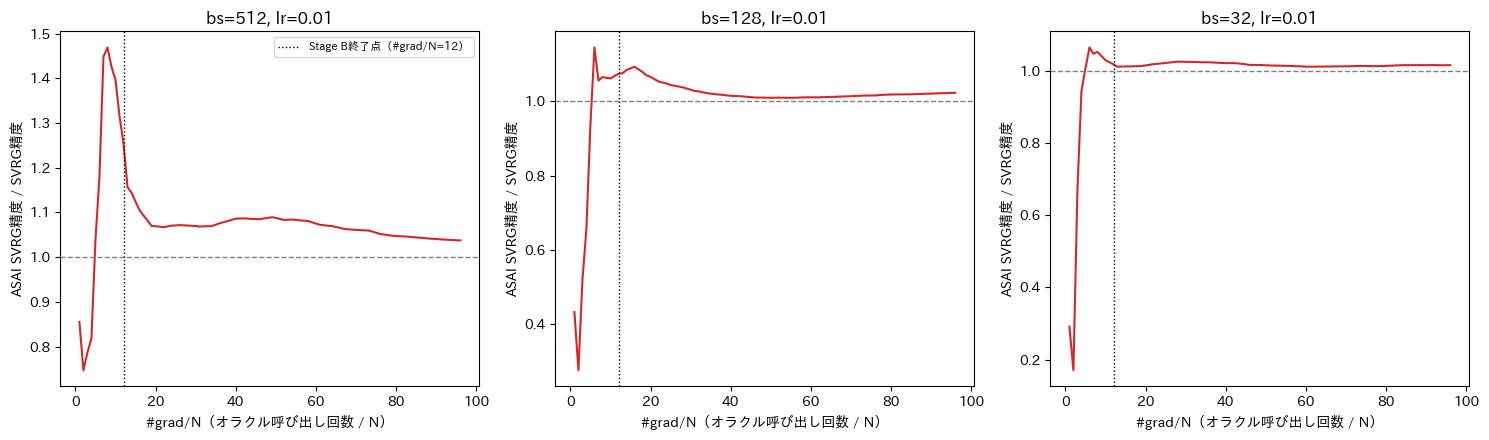

In [41]:
EX0031_GRADN_CHECKPOINTS = np.arange(1, 97)  # #grad/N = 1 〜 96（ASAI SVRGの全学習範囲）

fig, axes = plt.subplots(1, len(EX0031_BATCH_SIZES), figsize=(15, 4.5))
for j, bs in enumerate(EX0031_BATCH_SIZES):
    ax = axes[j]
    asai_entry = all_results.get((EX0031_EXPERIMENT, "ASAI_SVRG", ex0031_hp_name(bs)))
    svrg_entry = all_results.get((EX0031_EXPERIMENT, "SVRG", ex0031_hp_name(bs)))
    if asai_entry is None or svrg_entry is None:
        continue
    ratios = []
    for gN in EX0031_GRADN_CHECKPOINTS:
        target_oc = gN * EX0031_N_TRAIN
        asai_accs = [np.interp(target_oc, log["oracle_calls"], log["test_accuracy"]) for log in asai_entry["seed_logs"]]
        svrg_accs = [np.interp(target_oc, log["oracle_calls"], log["test_accuracy"]) for log in svrg_entry["seed_logs"]]
        asai_mean = np.mean(asai_accs)
        svrg_mean = np.mean(svrg_accs)
        ratios.append(asai_mean / svrg_mean if svrg_mean > 1e-9 else np.nan)
    ax.plot(EX0031_GRADN_CHECKPOINTS, ratios, color=METHOD_COLORS.get("ASAI_SVRG"), linewidth=1.5)
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
    ax.axvline(12, color="black", linestyle=":", linewidth=1, label="Stage B終了点（#grad/N=12）")
    ax.set_title(f"bs={bs}, lr={EX0031_LR}")
    ax.set_xlabel("#grad/N（オラクル呼び出し回数 / N）")
    ax.set_ylabel("ASAI SVRG精度 / SVRG精度")
    if j == 0:
        ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(EX0031_FIGURE_DIR / "asai_svrg_efficiency_ratio_trend.png", dpi=130, bbox_inches="tight")
plt.show()


### グリッド全体の要約表（最終精度，発散・チャンスレベル張り付きSeed数，プラトー判定，Stage B/C整合性）


In [42]:
import importlib.util as _importlib_util
import sys as _sys
for _stale in ("model", "data", "train"):
    _sys.modules.pop(_stale, None)
_ex0031_train_spec = _importlib_util.spec_from_file_location(
    "ex0031_train_viz", "programs/ex0031_tinyshakespeare_transformer_longrun/train.py"
)
_ex0031_train_viz = _importlib_util.module_from_spec(_ex0031_train_spec)
_ex0031_train_spec.loader.exec_module(_ex0031_train_viz)


def ex0031_summarize_grid() -> str:
    """概要: 実験3 Stage Cの全条件について，最終精度，発散・チャンスレベル張り付きSeed数，
        プラトー判定（末尾6エポックの最大相対変化），Stage B（12エポック）との整合性を
        まとめたMarkdown表を作成する．"""
    lines = [
        "| バッチサイズ | 手法 | 最終精度(Ep48) | 発散(NaN)Seed数 | チャンス張付きSeed数 | 精度プラトー(相対変化) | StageB/C Ep12差(最大絶対値) |",
        "| ---: | :--- | ---: | ---: | ---: | ---: | ---: |",
    ]
    ex003_entry_cache = {}
    for bs in EX0031_BATCH_SIZES:
        for method in EX0031_METHODS:
            entry = all_results.get((EX0031_EXPERIMENT, method, ex0031_hp_name(bs)))
            if entry is None:
                continue
            final_accs, n_nan, n_stuck, plateau_vals, ep12_diffs = [], 0, 0, [], []
            b_key = (EX003_EXPERIMENT, method, ex003_hp_name(EX0031_LR, bs))
            b_entry = ex003_entry_cache.setdefault(b_key, all_results.get(b_key))
            for si, log in enumerate(entry["seed_logs"]):
                final_accs.append(log["test_accuracy"][-1])
                if any(not np.isfinite(v) for v in log["train_loss"]):
                    n_nan += 1
                if _ex0031_train_viz.is_stuck_near_chance(log["test_accuracy"], EX0031_VOCAB_SIZE):
                    n_stuck += 1
                plateau_vals.append(
                    _ex0031_train_viz.compute_trailing_relative_change(log["test_accuracy"], 6)
                )
                if b_entry is not None and si < len(b_entry["seed_logs"]):
                    b_log = b_entry["seed_logs"][si]
                    ep12_diffs.append(abs(log["test_accuracy"][12] - b_log["test_accuracy"][12]))
            n = len(entry["seed_logs"])
            plateau_str = f"{np.mean(plateau_vals):.4f}"
            ep12_str = f"{max(ep12_diffs):.6f}" if ep12_diffs else "N/A"
            lines.append(
                f"| {bs} | {method} | {np.mean(final_accs):.4f} | {n_nan}/{n} | {n_stuck}/{n} |"
                f" {plateau_str} | {ep12_str} |"
            )
    return "\n".join(lines)


ex0031_table = ex0031_summarize_grid()
print(ex0031_table)
with open(EX0031_FIGURE_DIR / "grid_summary.md", "w") as f:
    f.write(ex0031_table + "\n")


| バッチサイズ | 手法 | 最終精度(Ep48) | 発散(NaN)Seed数 | チャンス張付きSeed数 | 精度プラトー(相対変化) | StageB/C Ep12差(最大絶対値) |
| ---: | :--- | ---: | ---: | ---: | ---: | ---: |
| 512 | SGD | 0.2376 | 0/3 | 0/3 | 0.0022 | 0.000000 |
| 512 | SVRG | 0.2376 | 0/3 | 0/3 | 0.0031 | 0.000000 |
| 512 | NFG_SVRG | 0.2373 | 0/3 | 0/3 | 0.0031 | 0.000000 |
| 512 | ASAI_SVRG | 0.2372 | 0/3 | 0/3 | 0.0024 | 0.000000 |
| 128 | SGD | 0.2507 | 0/3 | 0/3 | 0.0019 | 0.000000 |
| 128 | SVRG | 0.2507 | 0/3 | 0/3 | 0.0025 | 0.000000 |
| 128 | NFG_SVRG | 0.2505 | 0/3 | 0/3 | 0.0027 | 0.000000 |
| 128 | ASAI_SVRG | 0.2504 | 0/3 | 0/3 | 0.0022 | 0.000000 |
| 32 | SGD | 0.2651 | 0/3 | 0/3 | 0.0017 | 0.000000 |
| 32 | SVRG | 0.2649 | 0/3 | 0/3 | 0.0015 | 0.000000 |
| 32 | NFG_SVRG | 0.2648 | 0/3 | 0/3 | 0.0019 | 0.000000 |
| 32 | ASAI_SVRG | 0.2647 | 0/3 | 0/3 | 0.0014 | 0.000000 |


## 実験4（WikiText-2・単語レベル言語モデリング）Stage A（安定性探索）専用の可視化

`.orders/order_030.md`に対応する．NFG SVRG・ASAI SVRGの2手法のみ，バッチサイズ3種×学習率2種×3Seed=36条件（12エポック）．語彙サイズが約33,000と実験3（65）よりはるかに大きいため，チャンスレベル（$1/\text{vocab}$）はグラフ上でほぼ0に見える．


In [43]:
EX004_EXPERIMENT = "ex004_wikitext2_transformer"
EX004_METHODS = ["NFG_SVRG", "ASAI_SVRG"]  # Stage A（order_030）
EX004_BATCH_SIZES = [512, 128, 32]
EX004_LRS = [0.01, 0.001]
EX004_REG_LAMBDA = 0.0005
EX004_EPOCHS = 12
EX004_VOCAB_SIZE = 33277

EX004_FIGURE_DIR = OUTPUTS_ROOT / EX004_EXPERIMENT
EX004_FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def ex004_hp_name(lr: float, bs: int) -> str:
    """概要: 実験4 Stage Aのハイパーパラメータ条件名（ディレクトリ名）を構築する．"""
    return f"lr{lr}_bs{bs}_lambda{EX004_REG_LAMBDA}_epochs{EX004_EPOCHS}"


def ex004_load_all(method: str, bs: int, lr: float, key: str):
    """概要: 実験4の指定条件について，全Seedの指標を読み込み平均・標準偏差を計算する．"""
    entry = all_results.get((EX004_EXPERIMENT, method, ex004_hp_name(lr, bs)))
    if entry is None:
        return np.array([]), np.array([]), 0
    values = np.array([log[key] for log in entry["seed_logs"]], dtype=np.float64)
    return np.nanmean(values, axis=0), np.nanstd(values, axis=0), values.shape[0]


### 次単語予測精度のグリッド（縦：バッチサイズ，横：学習率，横軸：エポック数）


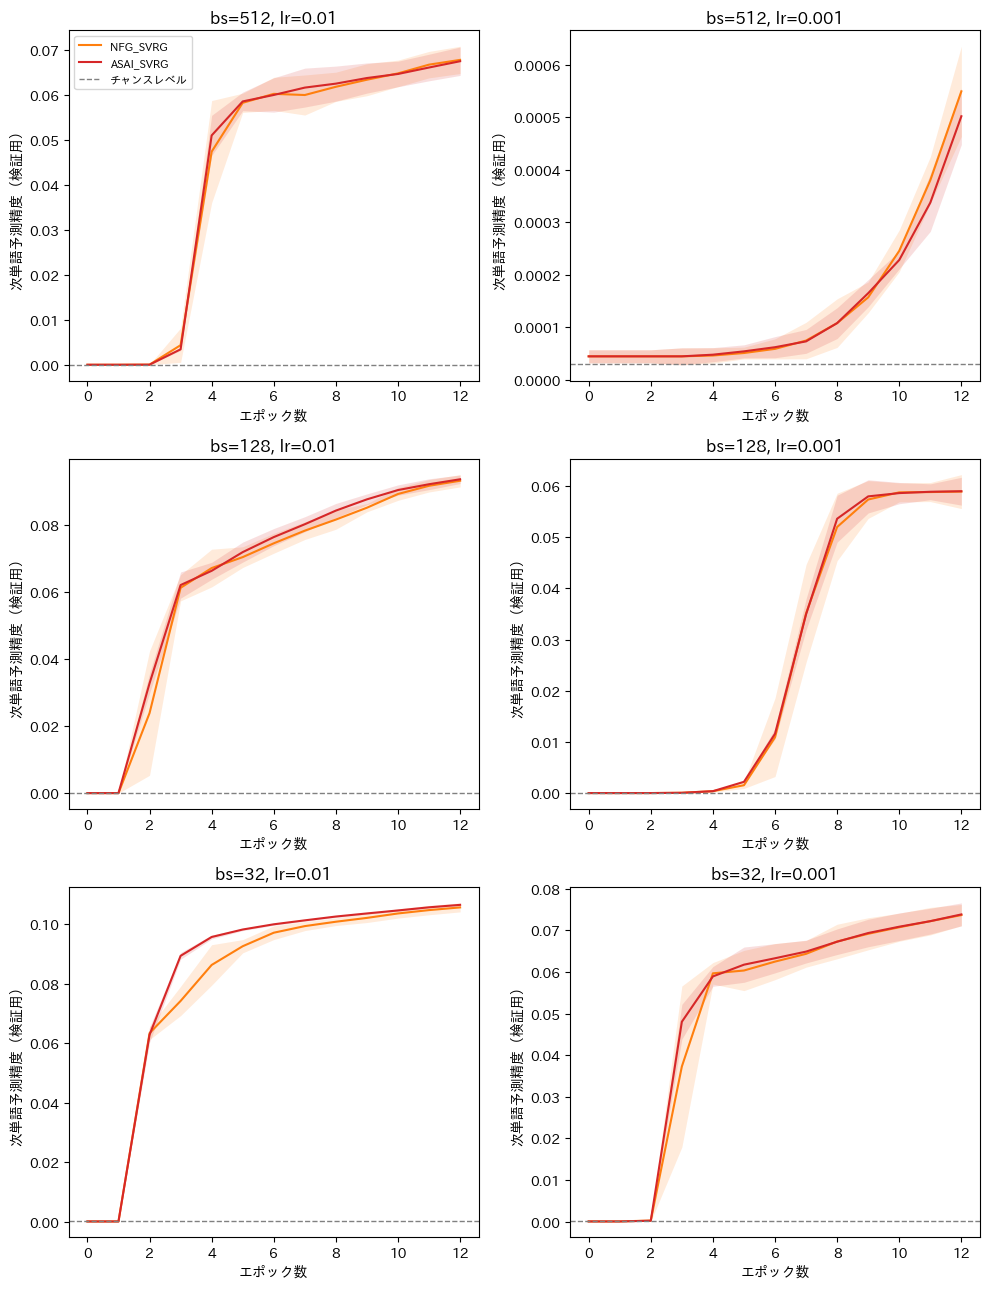

In [44]:
EX004_CHANCE = 1 / EX004_VOCAB_SIZE
fig, axes = plt.subplots(len(EX004_BATCH_SIZES), len(EX004_LRS), figsize=(10, 13))
for i, bs in enumerate(EX004_BATCH_SIZES):
    for j, lr in enumerate(EX004_LRS):
        ax = axes[i][j]
        for method in EX004_METHODS:
            mean, std, n = ex004_load_all(method, bs, lr, "test_accuracy")
            if n == 0:
                continue
            x = np.arange(len(mean))
            ax.plot(x, mean, label=method, color=METHOD_COLORS.get(method), linewidth=1.5)
            ax.fill_between(x, mean - std, mean + std, color=METHOD_COLORS.get(method), alpha=0.15, linewidth=0)
        ax.axhline(EX004_CHANCE, color="gray", linestyle="--", linewidth=1, label="チャンスレベル")
        ax.set_title(f"bs={bs}, lr={lr}")
        ax.set_xlabel("エポック数")
        ax.set_ylabel("次単語予測精度（検証用）")
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(EX004_FIGURE_DIR / "accuracy_grid.png", dpi=130, bbox_inches="tight")
plt.show()


### オラクル呼び出し回数を横軸とした次単語予測精度の比較（縦：バッチサイズ，横：学習率）


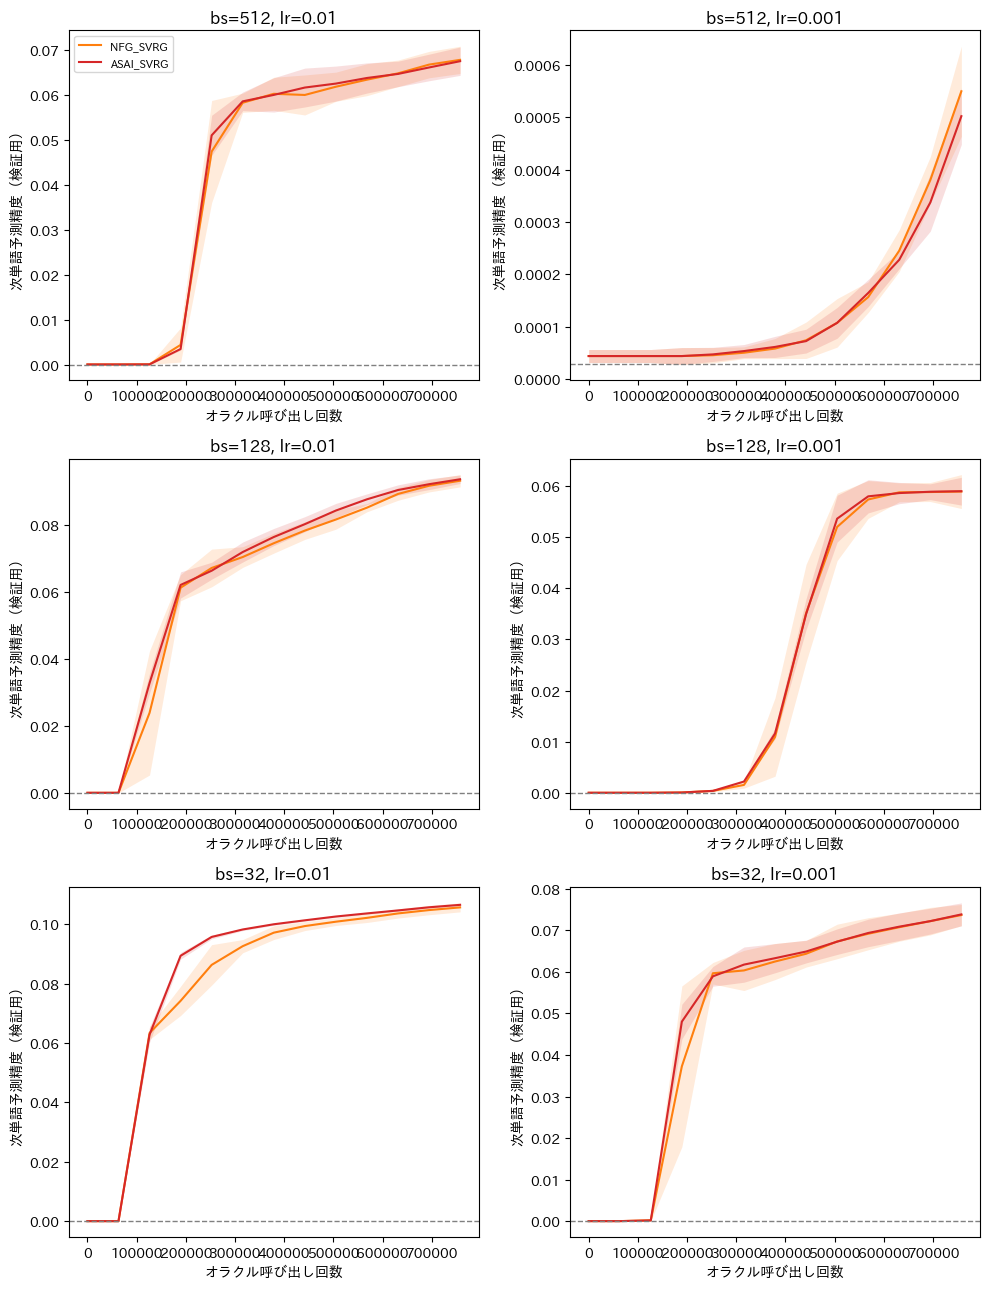

In [45]:
fig, axes = plt.subplots(len(EX004_BATCH_SIZES), len(EX004_LRS), figsize=(10, 13))
for i, bs in enumerate(EX004_BATCH_SIZES):
    for j, lr in enumerate(EX004_LRS):
        ax = axes[i][j]
        for method in EX004_METHODS:
            acc_mean, acc_std, n = ex004_load_all(method, bs, lr, "test_accuracy")
            oracle_mean, _, _ = ex004_load_all(method, bs, lr, "oracle_calls")
            if n == 0:
                continue
            ax.plot(oracle_mean, acc_mean, label=method, color=METHOD_COLORS.get(method), linewidth=1.5)
            ax.fill_between(oracle_mean, acc_mean - acc_std, acc_mean + acc_std,
                             color=METHOD_COLORS.get(method), alpha=0.15, linewidth=0)
        ax.axhline(EX004_CHANCE, color="gray", linestyle="--", linewidth=1)
        ax.set_title(f"bs={bs}, lr={lr}")
        ax.set_xlabel("オラクル呼び出し回数")
        ax.set_ylabel("次単語予測精度（検証用）")
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(EX004_FIGURE_DIR / "accuracy_grid_by_oracle_calls.png", dpi=130, bbox_inches="tight")
plt.show()


### フル勾配の近似誤差のグリッド（縦：バッチサイズ，横：学習率，横軸：エポック数，対数スケール）


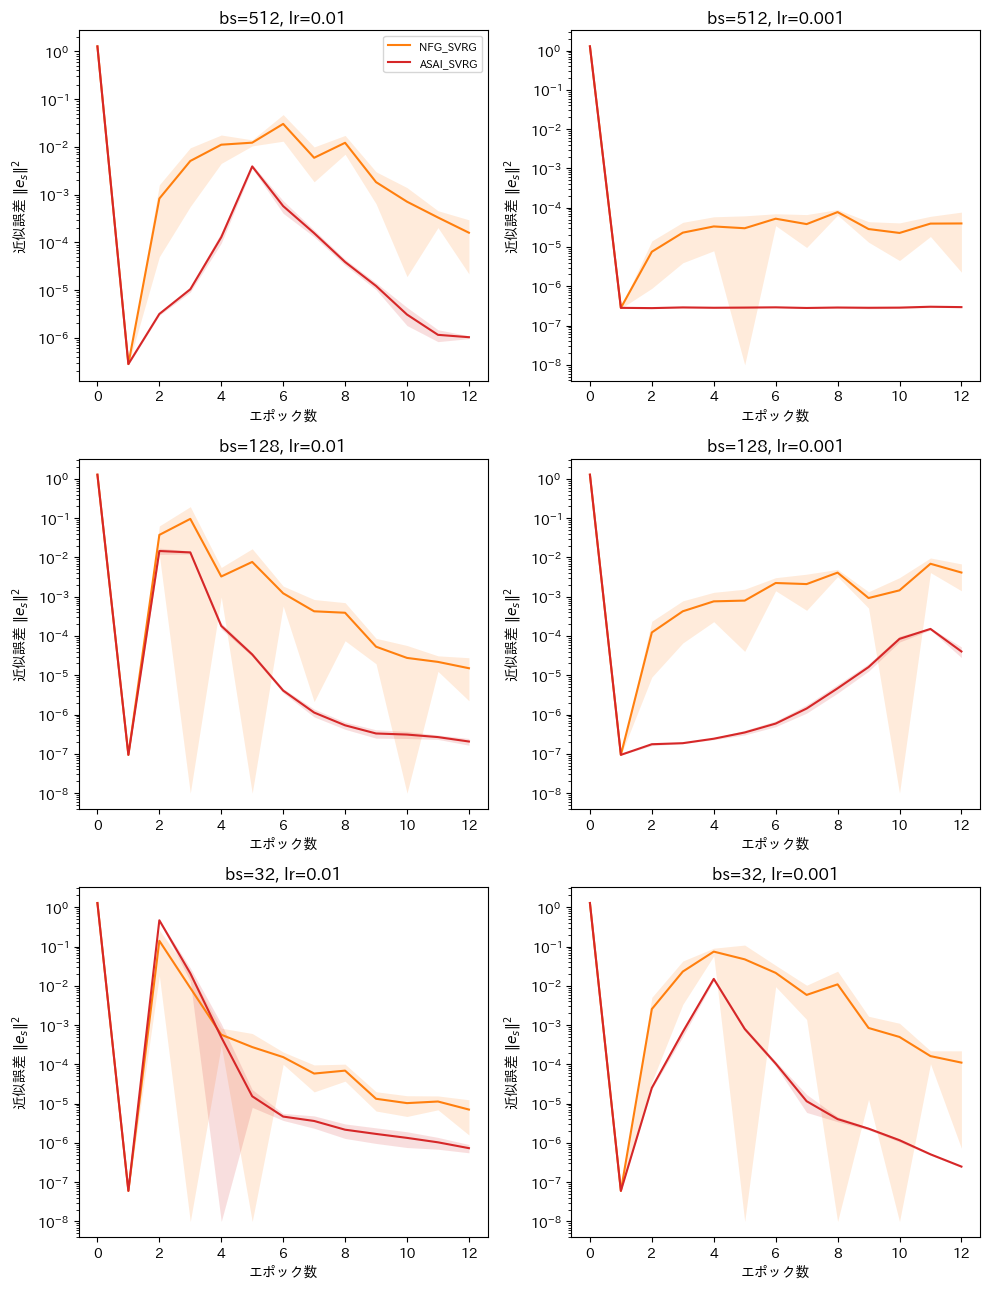

In [46]:
fig, axes = plt.subplots(len(EX004_BATCH_SIZES), len(EX004_LRS), figsize=(10, 13))
for i, bs in enumerate(EX004_BATCH_SIZES):
    for j, lr in enumerate(EX004_LRS):
        ax = axes[i][j]
        for method in EX004_METHODS:
            mean, std, n = ex004_load_all(method, bs, lr, "approx_error")
            if n == 0:
                continue
            x = np.arange(len(mean))
            ax.plot(x, mean, label=method, color=METHOD_COLORS.get(method), linewidth=1.5)
            ax.fill_between(x, np.clip(mean - std, 1e-8, None), mean + std,
                             color=METHOD_COLORS.get(method), alpha=0.15, linewidth=0)
        ax.set_yscale("log")
        ax.set_title(f"bs={bs}, lr={lr}")
        ax.set_xlabel("エポック数")
        ax.set_ylabel(r"近似誤差 $\|e_s\|^2$")
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(EX004_FIGURE_DIR / "approx_error_grid.png", dpi=130, bbox_inches="tight")
plt.show()


### グリッド全体の要約表（最終精度，発散・チャンスレベル張り付きSeed数）


In [47]:
import importlib.util as _importlib_util
import sys as _sys
for _stale in ("model", "data", "train"):
    _sys.modules.pop(_stale, None)
_ex004_train_spec = _importlib_util.spec_from_file_location(
    "ex004_train_viz", "programs/ex004_wikitext2_transformer/train.py"
)
_ex004_train_viz = _importlib_util.module_from_spec(_ex004_train_spec)
_ex004_train_spec.loader.exec_module(_ex004_train_viz)


def ex004_summarize_grid() -> str:
    """概要: 実験4 Stage Aの全条件について，最終精度，発散・チャンスレベル張り付きSeed数を
        まとめたMarkdown表を作成する．"""
    lines = [
        "| バッチサイズ | 学習率 | 手法 | 最終精度 | 発散(NaN)Seed数 | チャンス張付きSeed数 |",
        "| ---: | ---: | :--- | ---: | ---: | ---: |",
    ]
    for bs in EX004_BATCH_SIZES:
        for lr in EX004_LRS:
            for method in EX004_METHODS:
                entry = all_results.get((EX004_EXPERIMENT, method, ex004_hp_name(lr, bs)))
                if entry is None:
                    continue
                final_accs, n_nan, n_stuck = [], 0, 0
                for log in entry["seed_logs"]:
                    final_accs.append(log["test_accuracy"][-1])
                    if any(not np.isfinite(v) for v in log["train_loss"]):
                        n_nan += 1
                    if _ex004_train_viz.is_stuck_near_chance(log["test_accuracy"], EX004_VOCAB_SIZE):
                        n_stuck += 1
                n = len(entry["seed_logs"])
                lines.append(
                    f"| {bs} | {lr} | {method} | {np.mean(final_accs):.4f} | {n_nan}/{n} | {n_stuck}/{n} |"
                )
    return "\n".join(lines)


ex004_table = ex004_summarize_grid()
print(ex004_table)
with open(EX004_FIGURE_DIR / "grid_summary.md", "w") as f:
    f.write(ex004_table + "\n")


| バッチサイズ | 学習率 | 手法 | 最終精度 | 発散(NaN)Seed数 | チャンス張付きSeed数 |
| ---: | ---: | :--- | ---: | ---: | ---: |
| 512 | 0.01 | NFG_SVRG | 0.0678 | 0/3 | 0/3 |
| 512 | 0.01 | ASAI_SVRG | 0.0675 | 0/3 | 0/3 |
| 512 | 0.001 | NFG_SVRG | 0.0005 | 0/3 | 3/3 |
| 512 | 0.001 | ASAI_SVRG | 0.0005 | 0/3 | 3/3 |
| 128 | 0.01 | NFG_SVRG | 0.0933 | 0/3 | 0/3 |
| 128 | 0.01 | ASAI_SVRG | 0.0937 | 0/3 | 0/3 |
| 128 | 0.001 | NFG_SVRG | 0.0589 | 0/3 | 0/3 |
| 128 | 0.001 | ASAI_SVRG | 0.0589 | 0/3 | 0/3 |
| 32 | 0.01 | NFG_SVRG | 0.1056 | 0/3 | 0/3 |
| 32 | 0.01 | ASAI_SVRG | 0.1065 | 0/3 | 0/3 |
| 32 | 0.001 | NFG_SVRG | 0.0737 | 0/3 | 0/3 |
| 32 | 0.001 | ASAI_SVRG | 0.0738 | 0/3 | 0/3 |
